# GeoVision-CLIP + Sparse Autoencoders — Dos encoders + Late Fusion + SAE (v15 — post-proj SAE)

## Arquitectura (Camino B — SAE en espacio contrastivo 256D)

```
  RAMA S2 (11 bandas)                  RAMA S5P (8 variables)
    tile 64×64×11                         vector 8 vars
         │                                     │
  S2PatchEmbedding                       input_norm (LayerNorm 8)
  (11ch → 768, patch=8)                  S5PPatchEmbedding
  → 65 tokens                            (8 vars → 768, token/var)
         │                               → 9 tokens
  ViT-B/32 × 4 bloques                        │
  (pesos RemoteCLIP frozen           ViT × 2 bloques (random)
   al inicio, luego fine-tune)               │
         │                                     │
      CLS (768)                             CLS (768)
         └──────────────┬──────────────────────┘
                  LateFusion (concat 1536 → 768)
                        │
                 proj_vis(768→256) + L2-norm
                        │
              SAE_img(256→1024→256) ← overcomplete real (4×)
              TopK k=154/1024 (15%), L_sae_img
                        │
              L2-norm → e_img ∈ ℝ^256  ←── InfoNCE ───→  e_txt ∈ ℝ^256
                                                                 │
                                          Texto → RemoteCLIP text(512D)
                                          proj_txt(512→256) + L2-norm
                                          SAE_txt(256→1024→256), L_sae_txt
                                          L2-norm → e_txt ∈ ℝ^256
```

**Por qué Camino B funciona:**
- SAE opera en espacio 256D semántico (ya alineado S2+S5P+texto)
- overcomplete real: 256→1024 (4×), k=154 activos → sparsity=0.85
- features aprendidas son directamente discriminativas para retrieval
- MSE target <0.05 con sólo 256D a reconstruir

**L_total = L_InfoNCE + α·(L_sae_img + L_sae_txt),   α=0.1, λ=1e-3**

**KPIs objetivo:** Recall@1 ≥ 0.45 · Recall@5 ≥ 0.70 · Sparsity ≥ 0.70



### Configuración del entorno

In [ ]:
!pip install s3fs zarr xarray boto3 open_clip_torch sentence-transformers transformers --quiet

In [ ]:
# Imports y semilla global

import os
import math
import random
import hashlib
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.cuda.amp import autocast, GradScaler

from transformers import AutoModel, AutoTokenizer

import re
import numpy as np
import pandas as pd
import zarr
import s3fs
import xarray as xr
from datetime import datetime, timedelta


# ── Semilla global (OBLIGATORIO para reproducibilidad del checkpoint) ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

### Sparse Autoencoder (SAE)

Dos SAEs simétricos según spec PDF: uno visual (sobre el espacio fusionado S2+S5P)
y uno textual (sobre el embedding de XLM-RoBERTa).

```
Visual: fusion(CLS_s2, CLS_s5p) → SAE(768→512) → Linear(512→256) → e_img ∈ ℝ^256
Texto:  SBERT(384D)              → SAE(384→512) → Linear(512→256) → e_txt ∈ ℝ^256
```

**Pérdida del SAE:**
```
L_sae = L_rec + λ·L1   con λ = 1e-3
L_total = L_InfoNCE + α·(L_sae_img + L_sae_txt)   con α = 0.1
```

**Sparsity:** TopK con k = k_ratio × latent_dim  (k_ratio=0.25 → k=128 activos de 512)


In [3]:
# Sparse Autoencoder — feedforward, overcomplete

class SparseAutoencoder(nn.Module):

    def __init__(
        self,
        input_dim: int,
        latent_dim: int,
        lambda_l1: float = 1e-4,   # 1e-4 default: suave con TopK estructural
        k_ratio: float = 0.25,
    ):
        super().__init__()
        self.input_dim  = input_dim
        self.latent_dim = latent_dim
        self.lambda_l1  = lambda_l1
        self.k          = max(1, int(k_ratio * latent_dim))

        self.pre_norm   = nn.LayerNorm(input_dim)
        self.encoder    = nn.Linear(input_dim, latent_dim, bias=True)
        # ReLU: selecciona activaciones positivas coherentes con TopK.
        # Identity causaba que valores negativos pasaran al scatter → decoder recibe ruido.
        self.activation = nn.ReLU()

        # decoder SIN bias integrado: el bias de nn.Linear se ignora al normalizar
        # columnas con F.normalize(decoder.weight, dim=0). Separar el bias garantiza
        # que aprende el offset de reconstrucción sin interferir con la normalización.
        self.decoder      = nn.Linear(latent_dim, input_dim, bias=False)
        self.decoder_bias = nn.Parameter(torch.zeros(input_dim))

        # kaiming_uniform: escala correcta para input L2-norm~1 + ReLU.
        # orthogonal_ genera valores iniciales demasiado grandes → MSE explosivo al inicio.
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.kaiming_uniform_(self.decoder.weight, nonlinearity='linear')
        # Columnas del decoder unitarias desde el inicio (estándar Anthropic SAE)
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, Dict]:
        x_in   = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        x_norm = self.pre_norm(x_in)
        x_unit = F.normalize(x_norm, dim=-1)   # target unitario: MSE max teórico = 4.0

        z_pre = self.activation(self.encoder(x_unit))   # ReLU → solo valores >= 0

        if self.k < self.latent_dim:
            topk_vals, topk_idx = z_pre.topk(self.k, dim=-1)
            z_hard = torch.zeros_like(z_pre).scatter_(-1, topk_idx, topk_vals)
            # Straight-Through Estimator: forward=TopK sparse, backward=dense gradient
            z = z_hard - z_pre.detach() + z_pre
        else:
            z = z_pre

        # decoder_bias sumado fuera del matmul — no se toca en la normalización de columnas
        x_hat = self.decoder(z) + self.decoder_bias

        # Pérdidas en float32: evita overflow fp16
        l_rec    = F.mse_loss(x_hat.float(), x_unit.float())
        l_sparse = z.float().abs().mean()
        l_total  = l_rec + self.lambda_l1 * l_sparse

        return x_hat, z, {
            "reconstruction": l_rec,
            "sparsity":        l_sparse,
            "total":           l_total,
        }

    def sparsity_ratio(self, z: torch.Tensor, threshold: float = 1e-6) -> float:
        # 1e-6: mide ceros exactos (consistente con scatter TopK)
        return (z.abs() < threshold).float().mean().item()


In [ ]:
# Test unitario del SAE

def test_sae():
    print("── Test SparseAutoencoder ──")
    B, seq_len, head_dim = 4, 49, 64   # 4 imágenes, 49 tokens (7×7), head_dim=64
    latent_dim = 128  # overcomplete: 128 > 64 (×2)

    x = torch.randn(B, seq_len, head_dim).to(DEVICE)
    sae = SparseAutoencoder(input_dim=head_dim, latent_dim=latent_dim).to(DEVICE)

    x_hat, z, losses = sae(x)

    print(f"  Input shape:         {x.shape}")
    print(f"  Código latente z:    {z.shape}  (overcomplete: ×2)")
    print(f"  Reconstrucción x̂:   {x_hat.shape}")
    print(f"  L_rec:               {losses['reconstruction'].item():.4f}")
    print(f"  L_sparse (L1):       {losses['sparsity'].item():.4f}")
    print(f"  L_total:             {losses['total'].item():.4f}")
    print(f"  Sparsity ratio:      {sae.sparsity_ratio(z):.2%}")
    print("  ✓ SAE OK")

test_sae()

---
### Rama Sentinel-2: PatchEmbedding + ViT-B/32 (RemoteCLIP frozen)

**Flujo:**
```
tile (B, 11, 64, 64)
  → S2PatchEmbedding(11ch → 768, patch=8) → 65 tokens (1 CLS + 64 patches)
  → ViT Blocks ×4 (RemoteCLIP frozen)
  → LayerNorm
  → CLS token (B, 768)   ← entra a Late Fusion
```


In [5]:
# Patch Embedding para 11 bandas Sentinel-2

class S2PatchEmbedding(nn.Module):
    """
    Convierte un tile Sentinel-2 de 11 bandas en tokens para el ViT.

    El store Wasabi (gold.sat) contiene exactamente 11 bandas espectrales
    S2 (B2-B8, B8A, B11, B12), a diferencia del RGB (3 canales) de CLIP
    estándar. Necesitamos adaptar la primera capa de proyección.

    Estrategia:
        - patch_size=8: cada patch es 8×8 px  → tile 64×64 → 64 tokens (8×8 grid)
        - in_channels=11 en lugar de 3
        - embed_dim=768 (igual que ViT-B)
    """

    def __init__(
        self,
        img_size: int = 64,
        patch_size: int = 8,
        in_channels: int = 11,   # 11 bandas S2
        embed_dim: int = 768,    # dim interna del ViT
    ):
        super().__init__()
        assert img_size % patch_size == 0, "img_size debe ser divisible por patch_size"

        self.img_size    = img_size
        self.patch_size  = patch_size
        self.n_patches   = (img_size // patch_size) ** 2   # 64 para 64×64 con p=8
        self.embed_dim   = embed_dim

        # Proyección lineal de parche → embedding
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
        self.proj_drop = nn.Dropout(0.1)   # regulariza proyeccion 11ch→768

        # Token [CLS] aprendible (como en ViT original)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embedding aprendible
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches + 1, embed_dim)
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, 11, 64, 64)  — tile Sentinel-2
        Returns:
            tokens: (B, n_patches+1, embed_dim)  — incluye [CLS]
        """
        B = x.shape[0]

        # (B, 11, 64, 64) → (B, 768, 8, 8) → (B, 64, 768)
        x = self.proj_drop(self.proj(x).flatten(2).transpose(1, 2))

        # Anteponer [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)   # (B, 65, 768)

        # Sumar positional embedding
        x   = x + self.pos_embed
        return x

    def load_remoteclip_proj(self, state_dict: dict):
        """Infla conv1 RemoteCLIP (cualquier patch_size) a 11 canales con mapeo espectral."""
        key = 'visual.conv1.weight'
        if key not in state_dict:
            print(f"  [PatchEmbed] clave '{key}' no encontrada — init aleatoria")
            return
        w_rgb = state_dict[key].float()   # (768, 3, kH, kW)
        out_ch, in_ch, kH, kW = w_rgb.shape
        if kH != self.patch_size or kW != self.patch_size:
            import torch.nn.functional as F_interp
            w_rgb = F_interp.interpolate(
                w_rgb, size=(self.patch_size, self.patch_size),
                mode='bilinear', align_corners=False
            )
            scale = (kH * kW) / (self.patch_size * self.patch_size)
            w_rgb = w_rgb * (scale ** 0.5)
            print(f"  [PatchEmbed] kernel {kH}×{kW} → {self.patch_size}×{self.patch_size} (interp+escala)")

        w_R = w_rgb[:, 0]  # (768, kH, kW)
        w_G = w_rgb[:, 1]
        w_B = w_rgb[:, 2]

        w_11 = torch.zeros(out_ch, 11, self.patch_size, self.patch_size)
        # Bandas S2: [B2(490nm), B3(560nm), B4(665nm), B5(705nm), B6(740nm),
        #             B7(783nm), B8(842nm), B8A(865nm), B11(1610nm), B12(2190nm), B10(cirrus)]
        w_11[:, 0]  = w_B * 0.90          # B2 (490nm) ← Azul
        w_11[:, 1]  = w_G * 0.90          # B3 (560nm) ← Verde
        w_11[:, 2]  = w_R * 0.90          # B4 (665nm) ← Rojo
        w_11[:, 3]  = w_R * 0.70          # B5 (705nm) ← red-edge ≈ rojo
        w_11[:, 4]  = (w_R + w_G) * 0.40  # B6 (740nm) ← red-edge medio
        w_11[:, 5]  = (w_R + w_G) * 0.40  # B7 (783nm) ← red-edge alto
        w_11[:, 6]  = w_G * 0.60          # B8 (842nm) ← NIR ancho ≈ verde espectral
        w_11[:, 7]  = w_G * 0.50          # B8A (865nm) ← NIR estrecho
        w_11[:, 8]  = w_B * 0.30          # B11 (1610nm) ← SWIR1 (quemas, humedad)
        w_11[:, 9]  = w_B * 0.20          # B12 (2190nm) ← SWIR2 (contenido hídrico)
        w_11[:, 10] = (w_R + w_G + w_B) / 3 * 0.15  # B10 (cirrus) ← señal mínima

        self.proj.weight.data = w_11.to(self.proj.weight.device)
        print(f"  [PatchEmbed] proj inflado RGB→11ch con mapeo espectral ✓")


In [6]:
# Bloque ViT simplificado (RemoteCLIP frozen)

class ViTBlock(nn.Module):
    """
    Bloque Transformer idéntico al usado en RemoteCLIP (ViT-B/32 o similar).

    En producción este bloque se carga con pesos pre-entrenados de RemoteCLIP
    y se congela (frozen) para usar como extractor de features.
    """

    def __init__(
        self,
        embed_dim: int = 768,
        n_heads: int = 12,
        mlp_ratio: float = 4.0,
        dropout_p: float = 0.0,
        load_remoteclip_weights: bool = True,
        remoteclip_checkpoint: Optional[str] = None,
        block_idx: int = 0
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim,
            n_heads,
            dropout=0.0,
            batch_first=True,
            add_bias_kv=False
        )
        self.norm2 = nn.LayerNorm(embed_dim)

        mlp_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
        )

        self.drop1 = nn.Dropout(dropout_p)
        self.drop2 = nn.Dropout(dropout_p)

        # ==================== CARGAR PESOS REMOTECLIP ====================
        self.is_frozen = False
        if load_remoteclip_weights and remoteclip_checkpoint is not None:
            self._load_remoteclip_weights(remoteclip_checkpoint, block_idx)
        # ================================================================

    def _load_remoteclip_weights(self, checkpoint_path: str, block_idx: int):
        """Carga los pesos del bloque correspondiente de RemoteCLIP"""
        try:
            state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

            prefix = f"visual.transformer.resblocks.{block_idx}."

            # Verificar compatibilidad de dimensiones ANTES de asignar.
            # PyTorch permite .data = tensor_de_otra_forma sin error, pero el
            # LayerNorm falla en el forward si weight.shape != normalized_shape.
            ckpt_embed_dim = state_dict[prefix + "ln_1.weight"].shape[0]
            if ckpt_embed_dim != self.embed_dim:
                print(f" Bloque {block_idx}: dim checkpoint ({ckpt_embed_dim}) != "
                      f"embed_dim ({self.embed_dim}) — pesos aleatorios")
                return

            self.norm1.weight.data = state_dict[prefix + "ln_1.weight"].clone()
            self.norm1.bias.data   = state_dict[prefix + "ln_1.bias"].clone()

            self.attn.in_proj_weight.data  = state_dict[prefix + "attn.in_proj_weight"].clone()
            self.attn.in_proj_bias.data    = state_dict[prefix + "attn.in_proj_bias"].clone()
            self.attn.out_proj.weight.data = state_dict[prefix + "attn.out_proj.weight"].clone()
            self.attn.out_proj.bias.data   = state_dict[prefix + "attn.out_proj.bias"].clone()

            self.norm2.weight.data = state_dict[prefix + "ln_2.weight"].clone()
            self.norm2.bias.data   = state_dict[prefix + "ln_2.bias"].clone()

            self.mlp[0].weight.data = state_dict[prefix + "mlp.c_fc.weight"].clone()
            self.mlp[0].bias.data   = state_dict[prefix + "mlp.c_fc.bias"].clone()
            self.mlp[2].weight.data = state_dict[prefix + "mlp.c_proj.weight"].clone()
            self.mlp[2].bias.data   = state_dict[prefix + "mlp.c_proj.bias"].clone()

            print(f" Cargados pesos RemoteCLIP en bloque {block_idx} (embed_dim={self.embed_dim})")
            self.freeze()

        except Exception as e:
            print(f" Error cargando pesos RemoteCLIP en bloque {block_idx}: {e}")
            print(" Se usarán pesos aleatorios")

    def freeze(self):
        """Congela todos los parámetros del bloque"""
        for param in self.parameters():
            param.requires_grad = False
        self.is_frozen = True
        print(f" Bloque ViT frozen (no se entrenará)")

    def unfreeze(self):
        """Descongela el bloque (solo para debugging)"""
        for param in self.parameters():
            param.requires_grad = True
        self.is_frozen = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Atención con residual
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + self.drop1(attn_out)

        # MLP con residual
        x = x + self.drop2(self.mlp(self.norm2(x)))
        return x

In [7]:
# Encoder S2: PatchEmbedding + ViT-B/32 frozen → CLS token

class S2Encoder(nn.Module):
    """
    Rama Sentinel-2. Extrae CLS token (768D) con ViT-B/32 (RemoteCLIP frozen).
    No tiene SAE propio: el SAE se aplica al espacio fusionado S2+S5P.
    """

    def __init__(
        self,
        img_size: int     = 64,
        in_channels: int  = 11,
        embed_dim: int    = 768,
        n_heads: int      = 12,
        n_vit_blocks: int = 4,
        load_remoteclip_weights: bool = True,
        remoteclip_checkpoint: Optional[str] = None,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        self.patch_embed = S2PatchEmbedding(
            img_size=img_size, in_channels=in_channels, embed_dim=embed_dim
        )
        self.vit_blocks = nn.ModuleList([
            ViTBlock(
                embed_dim=embed_dim, n_heads=n_heads,
                dropout_p=0.1,   # regularización al descongelar
                load_remoteclip_weights=load_remoteclip_weights,
                remoteclip_checkpoint=remoteclip_checkpoint,
                block_idx=i,
            )
            for i in range(n_vit_blocks)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)

        if load_remoteclip_weights:
            if remoteclip_checkpoint is not None:
                try:
                    _sd = torch.load(remoteclip_checkpoint, map_location='cpu', weights_only=False)
                    if 'state_dict' in _sd: _sd = _sd['state_dict']
                    self.patch_embed.load_remoteclip_proj(_sd)
                except Exception as _e:
                    print(f"  [S2Encoder] no se pudo cargar proj RemoteCLIP: {_e}")
            self.freeze_vit()

    def freeze_vit(self):
        for block in self.vit_blocks:
            block.freeze()
        print("→ ViT S2 congelado (RemoteCLIP)")

    def unfreeze_vit(self):
        for block in self.vit_blocks:
            block.unfreeze()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        tokens = self.patch_embed(x)
        for block in self.vit_blocks:
            tokens = block(tokens)
        return self.final_norm(tokens)[:, 0, :]   # CLS token (B, 768)

In [ ]:
def test_s2_encoder():
    print("── Test S2Encoder (CLS token, sin SAE) ──")
    enc = S2Encoder(embed_dim=768, n_heads=12, n_vit_blocks=2,
                    load_remoteclip_weights=False)
    x   = torch.randn(2, 11, 64, 64)
    out = enc(x)
    assert out.shape == (2, 768), f"shape error: {out.shape}"
    print(f"  out shape: {out.shape}   ✓")

test_s2_encoder()


---
### Rama Sentinel-5P: PatchEmbedding + ViT (arquitectura simétrica a S2)

**Flujo:**
```
vec (B, 8)   # [NO2, SO2, O3, AOD, T2m, u, v, BLH]
  → S5PPatchEmbedding: cada variable → token de dim 768 → 9 tokens (1 CLS + 8 vars)
  → ViT Blocks ×4 (init aleatorio, trainable — sin RemoteCLIP)
  → LayerNorm
  → CLS token (B, 768)   ← entra a Late Fusion
```

Arquitectura idéntica a S2Encoder; la diferencia es el PatchEmbedding de entrada
y que los pesos ViT se entrenan desde cero (no hay checkpoint para S5P).


In [9]:
# Patch Embedding para Sentinel-5P (cada variable → un token)

class S5PPatchEmbedding(nn.Module):
    """Trata cada variable S5P como un token independiente."""

    def __init__(self, n_vars: int = 8, embed_dim: int = 768):
        super().__init__()
        self.n_vars    = n_vars
        self.embed_dim = embed_dim
        self.var_proj  = nn.Linear(1, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_vars + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, v: torch.Tensor) -> torch.Tensor:
        B = v.shape[0]
        x   = self.var_proj(v.unsqueeze(-1))           # (B, 8, 768)
        cls = self.cls_token.expand(B, -1, -1)
        return torch.cat([cls, x], dim=1) + self.pos_embed  # (B, 9, 768)


# Encoder S5P — ResidualMLP: 8 vars → 768D
# CAMBIO ARQUITECTURAL: reemplaza 2 ViT blocks (14.2M params) por un
# ResidualMLP de 3 capas (~0.4M params).
# Justificacion: 8 variables escalares NO necesitan atencion multi-cabeza.
# El ViT era 35x sobreparametrizado para esta entrada, causando overfitting.

class S5PEncoder(nn.Module):
    """
    Rama Sentinel-5P: ResidualMLP(8→512→768) con skip connection.
    ~0.4M params (vs 14.2M del ViT anterior) — apropiado para 8 escalares.
    Incluye input_norm critico: NO2~1e-4 vs O3~0.1 difieren x1000.
    """

    def __init__(
        self,
        n_vars: int    = 8,
        embed_dim: int = 768,
        hidden_dim: int = 512,    # capa oculta del MLP
        n_heads: int   = 12,      # ignorado, mantenido por compatibilidad de firma
        n_vit_blocks: int = 2,    # ignorado, mantenido por compatibilidad de firma
    ):
        super().__init__()
        self.embed_dim = embed_dim

        # Normaliza las 8 variables (critico: escalas radicalmente distintas)
        self.input_norm = nn.LayerNorm(n_vars)

        # MLP profundo con residual: 8 → hidden → embed_dim
        self.fc1      = nn.Linear(n_vars, hidden_dim)
        self.norm1    = nn.LayerNorm(hidden_dim)
        self.fc2      = nn.Linear(hidden_dim, embed_dim)
        self.norm2    = nn.LayerNorm(embed_dim)
        self.fc3      = nn.Linear(embed_dim, embed_dim)
        self.final_norm = nn.LayerNorm(embed_dim)

        # Skip connection desde fc1 hasta la salida (dim distinta → proyeccion)
        self.skip_proj = nn.Linear(n_vars, embed_dim, bias=False)

        self.act  = nn.GELU()
        self.drop = nn.Dropout(0.3)

    def forward(self, v: torch.Tensor) -> torch.Tensor:
        v = v.float()
        v_norm = self.input_norm(v)               # (B, 8)

        # MLP: 8 → 512 → 768 → 768
        h = self.drop(self.act(self.norm1(self.fc1(v_norm))))   # (B, 512)
        h = self.drop(self.act(self.norm2(self.fc2(h))))         # (B, 768)
        h = self.fc3(h)                                           # (B, 768)

        # Skip connection: v_norm → 768 (bypass profundidad)
        skip = self.skip_proj(v_norm)                            # (B, 768)
        out  = self.final_norm(h + skip)                         # (B, 768)
        return out    # equivalente al CLS token en la interfaz


In [ ]:
def test_s5p_encoder():
    print("── Test S5PEncoder (input_norm + 2 bloques) ──")
    enc = S5PEncoder(n_vars=8, embed_dim=768, n_heads=12, n_vit_blocks=2)
    # Simular escalas reales: NO2~1e-4, O3~0.1, std~0, BLH~1000
    v = torch.tensor([[1e-4, 1e-6, 5e-5, 5e-7, 0.10, 0.01, 2e-4, 1e-4]])
    out = enc(v)
    assert out.shape == (1, 768), f"shape error: {out.shape}"
    assert torch.isfinite(out).all(), "NaN en S5PEncoder con escalas reales"
    print(f"  out shape: {out.shape}  norm: {out.norm().item():.3f}   ✓")

test_s5p_encoder()


---
### Late Fusion: concat CLS_S2 + CLS_S5P → espacio latente fusionado


```
CLS_s2  (B, 768)  ──┐
                     ├─ concat (B, 1536) → Linear(1536→768) → GELU → fused (B, 768)
CLS_s5p (B, 768)  ──┘
```


In [11]:
# Late Fusion: concatena CLS_S2 y CLS_S5P → espacio latente fusionado

class LateFusion(nn.Module):
    """
    Fusiona CLS_S2 (768D) y emb_S5P (768D):
      1. Pre-normaliza cada rama por separado (LayerNorm) — evita que S5P domine por magnitud
      2. MLP 2 capas con orden correcto Linear → GELU → LayerNorm
      3. Gating aprendible: pondera la contribución de S2 vs S5P por muestra
    """

    def __init__(self, s2_dim: int = 768, s5p_dim: int = 768, out_dim: int = 768):
        super().__init__()
        # Pre-normalización por modalidad (fix: S5P norma ~27 vs S2 norma ~10)
        self.norm_s2  = nn.LayerNorm(s2_dim)
        self.norm_s5p = nn.LayerNorm(s5p_dim)

        # MLP 2 capas: Linear → GELU → LayerNorm → Dropout → Linear
        # Orden correcto: activación primero, normalización después
        self.mlp = nn.Sequential(
            nn.Linear(s2_dim + s5p_dim, out_dim * 2),
            nn.GELU(),
            nn.LayerNorm(out_dim * 2),
            nn.Dropout(0.2),
            nn.Linear(out_dim * 2, out_dim),
        )

        # Gating por muestra: aprende qué modalidad aporta más en cada contexto
        self.gate = nn.Sequential(
            nn.Linear(s2_dim + s5p_dim, 2),
            nn.Softmax(dim=-1),
        )
        # S5P tiene la señal discriminativa (NO2/SO2/O3 invisibles en S2)
        # Inicializar gate para favorecer S5P (~88%) sobre S2 (~12%)
        with torch.no_grad():
            self.gate[0].bias.data = torch.tensor([-1.0, 1.0])

    def forward(self, emb_s2: torch.Tensor, emb_s5p: torch.Tensor) -> torch.Tensor:
        s2  = self.norm_s2(emb_s2)                          # (B, 768)
        s5p = self.norm_s5p(emb_s5p)                        # (B, 768)
        cat = torch.cat([s2, s5p], dim=-1)                  # (B, 1536)
        g   = self.gate(cat)                                 # (B, 2) — pesos por modalidad
        # Aplicar gating antes de fusionar
        cat_gated = torch.cat([s2 * g[:, 0:1], s5p * g[:, 1:2]], dim=-1)  # (B, 1536)
        return self.mlp(cat_gated)                           # (B, out_dim)


--- ### Text Encoder (XLM-RoBERTa + SAE) — v18
Reemplaza RemoteCLIP BPE inglés (512D) por XLM-RoBERTa-base (768D, español nativo).

In [12]:
# Text Encoder — XLM-RoBERTa (v18: reemplaza RemoteCLIP BPE inglés)
class TextEncoder(nn.Module):
    _TEXT_DIM = 768
    def __init__(self, model_name='xlm-roberta-base', sae_latent_dim=1024,
                 lambda_l1=1e-4, k_ratio=0.15, out_dim=256,
                 n_trainable_layers=1, remoteclip_checkpoint=None, **kwargs):
        super().__init__()
        self._tokenizer = AutoTokenizer.from_pretrained(model_name)
        self._roberta   = AutoModel.from_pretrained(model_name)
        for p in self._roberta.parameters():
            p.requires_grad_(False)
        for layer in self._roberta.encoder.layer[-n_trainable_layers:]:
            for p in layer.parameters(): p.requires_grad_(True)
        n_train = sum(p.numel() for p in self._roberta.parameters() if p.requires_grad)
        print(f'  XLM-RoBERTa: {n_trainable_layers} capa(s) trainable ({n_train:,} params)')
        self.proj_phase1 = nn.Sequential(nn.Dropout(0.2), nn.Linear(self._TEXT_DIM, out_dim, bias=False))
        self.proj_txt    = nn.Sequential(nn.Dropout(0.2), nn.Linear(self._TEXT_DIM, out_dim, bias=False))
        self.sae = SparseAutoencoder(out_dim, sae_latent_dim, lambda_l1, k_ratio)

    def _encode_raw(self, texts):
        device = next(self.proj_phase1.parameters()).device
        enc = self._tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        out = self._roberta(**enc)
        return out.last_hidden_state[:, 0, :].float()

    def sbert_trainable_params(self):
        return [p for p in self._roberta.parameters() if p.requires_grad]

    def freeze_sbert(self):
        for p in self._roberta.parameters(): p.requires_grad_(False)

    def forward(self, texts, phase=1):
        device = next(self.proj_phase1.parameters()).device
        enc = self._tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        out = self._roberta(**enc)
        raw = out.last_hidden_state[:, 0, :].float()
        if phase == 1:
            return F.normalize(self.proj_phase1(raw), dim=-1), {'sae_loss': raw.new_zeros(1).squeeze(), 'mean_sparsity': 0.0}
        e_pre = F.normalize(self.proj_txt(raw), dim=-1)
        x_hat, z, losses = self.sae(e_pre)
        return F.normalize(x_hat, dim=-1), {'sae_loss': losses['total'], 'mean_sparsity': self.sae.sparsity_ratio(z)}


### Modelo GeoVision-CLIP — S2 + S5P → Fusión → SAE → InfoNCE ↔ Texto

```
S2Encoder(tile)  ──┐
                    ├─ LateFusion ─→ SAE(768→512) ─→ Linear(512→256) ─→ e_img ∈ ℝ^256
S5PEncoder(vec)  ──┘                  L_sae_img               ↕ InfoNCE
                                                         e_txt ∈ ℝ^256
                                            TextEncoder: SBERT → SAE → Linear
                                                              L_sae_txt

L_total = L_InfoNCE + α·(L_sae_img + L_sae_txt),   α=0.1, λ=1e-3
```


In [13]:
# Modelo GeoVision-CLIP v15: Camino B — SAE post-proyección (espacio 256D)
#
# Cambio arquitectural vs v14:
#   ANTES (v14): Fusion(768) → SAE(768→512) → proj(512→256) → e_img
#   AHORA (v15): Fusion(768) → proj_vis(768→256) + L2-norm → SAE(256→1024→256) → L2-norm → e_img
#
# Por qué es mejor:
#   1. SAE opera en espacio ya alineado S2+S5P+texto (256D semántico)
#   2. Overcomplete real: 256→1024 (4×) vs anterior 768→768 (cuadrado)
#   3. Features SAE directamente relevantes para retrieval (sin capa proj intermedia)
#   4. MSE target <0.05 con sólo 256D a reconstruir (vs 768D antes)

class GeoVisionCLIP(nn.Module):
    """
    Fase 1: Fusion(768) → proj_vis_phase1(768→256) → e_img  [SAE bypassed]
    Fase 2: Fusion(768) → proj_vis(768→256) + L2-norm → SAE(256→1024→256) → L2-norm → e_img
    TextEncoder: CLIP text(512) → proj_txt(512→256) + L2-norm → SAE(256→1024→256) → L2-norm → e_txt
    """

    def __init__(
        self,
        img_size: int          = 64,
        embed_dim: int         = 768,
        n_heads: int           = 12,
        n_vit_blocks: int      = 4,
        n_s5p_vit_blocks: int  = 2,
        n_s5p_vars: int        = 8,
        sae_latent_dim: int    = 1024,   # 4× sobre espacio 256D
        lambda_l1: float       = 1e-3,
        alpha_sae: float       = 0.1,
        k_ratio: float         = 0.15,   # k=154/1024 → sparsity=0.85
        contrastive_dim: int   = 256,
        tau_init: float        = 0.10,
        load_remoteclip_weights: bool = True,
        remoteclip_checkpoint: Optional[str] = None,
    ):
        super().__init__()
        self.alpha_sae    = alpha_sae
        self.contrastive_dim = contrastive_dim
        self.log_tau      = nn.Parameter(torch.tensor(math.log(tau_init), dtype=torch.float32))
        self._phase       = 1  # 1=Fase CLIP pura, 2=Fase SAE

        # Rama S2: ViT-B/32 con pesos RemoteCLIP (frozen)
        self.s2_encoder = S2Encoder(
            img_size=img_size, in_channels=11,
            embed_dim=embed_dim, n_heads=n_heads,
            n_vit_blocks=n_vit_blocks,
            load_remoteclip_weights=load_remoteclip_weights,
            remoteclip_checkpoint=remoteclip_checkpoint,
        )
        # Rama S5P: ResidualMLP ~0.4M params
        self.s5p_encoder = S5PEncoder(
            n_vars=n_s5p_vars,
            embed_dim=embed_dim, n_heads=n_heads,
            n_vit_blocks=n_s5p_vit_blocks,
        )

        # Fusión de los dos CLS tokens
        self.fusion = LateFusion(
            s2_dim=embed_dim, s5p_dim=embed_dim, out_dim=embed_dim
        )

        # Fase 1: proyección directa 768→256 (sin SAE)
        # Mismas dimensiones que proj_vis → permite warm-start en Fase 2
        self.visual_proj_phase1 = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(embed_dim, contrastive_dim, bias=False),
        )

        # Fase 2 (Camino B): proyección pre-SAE 768→256 + SAE post-proj 256→1024→256
        # El SAE opera en el espacio contrastivo 256D, no en el espacio de fusión 768D.
        # Garantía: features SAE = features relevantes para InfoNCE.
        self.proj_vis = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(embed_dim, contrastive_dim, bias=False),
        )
        self.sae = SparseAutoencoder(contrastive_dim, sae_latent_dim, lambda_l1, k_ratio)

        # Encoder textual: CLIP text + proj(512→256) + SAE(256→1024→256)
        self.text_encoder = TextEncoder(
            remoteclip_checkpoint=remoteclip_checkpoint,
            sae_latent_dim=sae_latent_dim,
            lambda_l1=lambda_l1,
            k_ratio=k_ratio,
            out_dim=contrastive_dim,
        )

    @property
    def tau(self):
        val = self.log_tau.float().exp().clamp(0.05, 0.20)
        if not torch.isfinite(val):
            return torch.tensor(0.10, device=self.log_tau.device, dtype=torch.float32)
        return val

    def encode_image(
        self, tile_s2: torch.Tensor, vec_s5p: torch.Tensor
    ) -> Tuple[torch.Tensor, Dict]:
        cls_s2  = self.s2_encoder(tile_s2)
        cls_s5p = self.s5p_encoder(vec_s5p)
        fused   = self.fusion(cls_s2, cls_s5p)          # (B, 768)

        if self._phase == 1:
            # Fase 1: bypass SAE — aprendizaje contrastivo sin sparsity
            e_img = F.normalize(self.visual_proj_phase1(fused).float(), dim=-1)
            zero  = fused.new_zeros(1).squeeze()
            return e_img, {"sae_loss": zero, "mean_sparsity": 0.0}

        # Fase 2 (Camino B):
        #   fused(768) → proj_vis(768→256) + L2-norm → SAE(256→1024→256) → L2-norm
        # El SAE recibe un vector ya proyectado y normalizado en la hiperesfera,
        # por lo que aprende features directamente discriminativas para InfoNCE.
        e_pre = F.normalize(self.proj_vis(fused).float(), dim=-1)   # (B, 256), unidad
        x_hat, z, losses = self.sae(e_pre)
        e_img = F.normalize(x_hat.float(), dim=-1)  # reconstrucción esparsa (B, 256)
        return e_img, {
            "sae_loss":      losses["total"],
            "mean_sparsity": self.sae.sparsity_ratio(z),
        }

    def encode_text(self, texts: List[str]) -> Tuple[torch.Tensor, Dict]:
        return self.text_encoder(texts, phase=self._phase)

    def forward(
        self, tile_s2: torch.Tensor, vec_s5p: torch.Tensor, texts: List[str],
        labels: Optional[torch.Tensor] = None,
    ) -> Dict:
        e_img, sae_img = self.encode_image(tile_s2, vec_s5p)
        e_txt, sae_txt = self.encode_text(texts)

        e_img_f = e_img.float()
        e_txt_f = e_txt.float()
        with torch.amp.autocast('cuda', enabled=False):
            logits = e_img_f @ e_txt_f.T / self.tau
        B = logits.shape[0]
        if labels is not None:
            pos_mask  = (labels.unsqueeze(1) == labels.unsqueeze(0)).float().to(logits.device)
            log_p_i2t = F.log_softmax(logits,   dim=1)
            log_p_t2i = F.log_softmax(logits.T, dim=1)
            n_pos     = pos_mask.sum(dim=1).clamp(min=1)
            loss_i2t  = -(pos_mask * log_p_i2t).sum(dim=1) / n_pos
            loss_t2i  = -(pos_mask * log_p_t2i).sum(dim=1) / n_pos
            loss_infonce = 0.5 * (loss_i2t.mean() + loss_t2i.mean())
        else:
            targets = torch.arange(B, device=logits.device)
            loss_infonce = 0.5 * (
                F.cross_entropy(logits,   targets, label_smoothing=0.05) +
                F.cross_entropy(logits.T, targets, label_smoothing=0.05)
            )

        loss_sae   = sae_img["sae_loss"] + sae_txt["sae_loss"]
        loss_total = loss_infonce + self.alpha_sae * loss_sae

        return {
            "loss_total":   loss_total,
            "loss_infonce": loss_infonce,
            "loss_sae":     loss_sae,
            "sparsity_img": sae_img["mean_sparsity"],
            "sparsity_txt": sae_txt["mean_sparsity"],
            "e_img":        e_img,
            "e_txt":        e_txt,
        }


In [ ]:
def test_full_model():
    print("── Test GeoVisionCLIP v15 (Camino B: SAE post-proj 256D) ──")
    m = GeoVisionCLIP(
        img_size=64, embed_dim=768, n_heads=12, n_vit_blocks=2,
        n_s5p_vit_blocks=2, sae_latent_dim=1024, lambda_l1=1e-3,
        alpha_sae=0.1, contrastive_dim=256, load_remoteclip_weights=False,
    )
    tiles = torch.randn(2, 11, 64, 64)
    vecs  = torch.randn(2, 8)
    texts = ["contaminación alta NO2 zona industrial Cali Colombia",
             "vegetación densa parque bosque sur Cali Colombia"]

    # Fase 1: sin SAE
    m._phase = 1
    out1 = m(tiles, vecs, texts)
    assert out1['e_img'].shape == (2, 256), f"e_img: {out1['e_img'].shape}"
    print(f"  [Fase 1] e_img: {out1['e_img'].shape} | loss: {out1['loss_total'].item():.4f}")

    # Fase 2: con SAE post-proj
    m._phase = 2
    out2 = m(tiles, vecs, texts)
    assert out2['e_img'].shape == (2, 256), f"e_img: {out2['e_img'].shape}"
    assert out2['e_txt'].shape == (2, 256), f"e_txt: {out2['e_txt'].shape}"
    print(f"  [Fase 2] e_img: {out2['e_img'].shape} | e_txt: {out2['e_txt'].shape}")
    print(f"  loss_total    : {out2['loss_total'].item():.4f}")
    print(f"  loss_infonce  : {out2['loss_infonce'].item():.4f}")
    print(f"  loss_sae      : {out2['loss_sae'].item():.4f}")
    print(f"  sparsity_img  : {out2['sparsity_img']:.3f}")
    print(f"  sparsity_txt  : {out2['sparsity_txt']:.3f}")
    print(f"  SAE latent_dim: {m.sae.latent_dim} (4× overcomplete sobre 256D)")
    print(f"  SAE k         : {m.sae.k} activos / {m.sae.latent_dim}")
    print("── OK ──")

test_full_model()


### Carga de Datos Reales desde Wasabi (sentinel-2-v2 + sentinel-5p-v2)


In [ ]:
# [CELDA 8.0] Imports, credenciales Wasabi y cliente S3

import re, os
import numpy as np
import pandas as pd
import torch
import zarr
import boto3
import s3fs
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from pathlib import Path
from typing import List, Tuple, Optional, Dict

# ── Credenciales Wasabi (compartidas entre buckets) ───────────────────────
WASABI_ACCESS_KEY = "EPAJLZS1BT5K3X8CPGR2"
WASABI_SECRET_KEY = "QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek"
ENDPOINT_URL      = "https://s3.us-west-1.wasabisys.com"

# ── Sentinel-2: bucket gold ───────────────────────────────────────────────
BUCKET_S2  = "gold.sat"
PREFIX_S2  = "Sentinel-2/"   # trailing slash incluida

# ── Sentinel-5P: bucket silver ────────────────────────────────────────────
BUCKET_S5P        = "gold.sat"
PREFIX_S5P        = "Sentinel5P"          # sin trailing slash
S5P_CONTAMINANTS  = ["NO2", "SO2", "O3"]

YEARS     = list(range(2020, 2025))
TILE_SIZE = 64

RE_FECHA = re.compile(r"(\d{4}-\d{2}-\d{2})\.zarr$")

REMOTECLIP_CHECKPOINT = "Model/RemoteCLIP-ViT-B-32.pt"

# ── Clientes boto3 — uno por bucket ───────────────────────────────────────
_boto_kwargs = dict(
    endpoint_url         = ENDPOINT_URL,
    aws_access_key_id    = WASABI_ACCESS_KEY,
    aws_secret_access_key= WASABI_SECRET_KEY,
)
s3_s2  = boto3.client("s3", **_boto_kwargs)   # gold.sat  → Sentinel-2
s3_s5p = boto3.client("s3", **_boto_kwargs)   # silver.sat → Sentinel-5P

# ── Filesystems s3fs — uno por bucket (para lectura Zarr posterior) ───────
_s3fs_kwargs = dict(
    key           = WASABI_ACCESS_KEY,
    secret        = WASABI_SECRET_KEY,
    client_kwargs = {"endpoint_url": ENDPOINT_URL},
)
fs_s2  = s3fs.S3FileSystem(**_s3fs_kwargs)   # gold.sat
fs_s5p = s3fs.S3FileSystem(**_s3fs_kwargs)   # silver.sat

print("✓ Clientes Wasabi listos")
print(f"  S2  → bucket: {BUCKET_S2}   | {PREFIX_S2}{{año}}/{{fecha}}.zarr/")
print(f"  S5P → bucket: {BUCKET_S5P}  | {PREFIX_S5P}/{{NO2|SO2|O3}}/{{año}}/{{fecha}}.zarr/")


In [ ]:
# [CELDA 8.1] Inventario .zarr: S2 (fechas internas) y S5P por contaminante

import xarray as xr

RE_FECHA     = re.compile(r"(\d{4}-\d{2}-\d{2})")
RE_FECHA_ANO = re.compile(r"(\d{4})\.zarr$")

# ── Helpers generales ─────────────────────────────────────────────────────
def extraer_fecha(zarr_path: str) -> Optional[datetime.date]:
    m = RE_FECHA.search(zarr_path)
    if m:
        try:
            return datetime.strptime(m.group(1), "%Y-%m-%d").date()
        except Exception:
            pass
    m2 = RE_FECHA_ANO.search(zarr_path)
    if m2:
        try:
            return datetime.strptime(f"{m2.group(1)}-01-01", "%Y-%m-%d").date()
        except Exception:
            pass
    return None

def zarr_to_df(paths: List[str], sensor: str) -> pd.DataFrame:
    rows = [
        {"zarr_path": p, "fecha": extraer_fecha(p),
         "year": extraer_fecha(p).year, "sensor": sensor}
        for p in paths if extraer_fecha(p) is not None
    ]
    df = pd.DataFrame(rows)
    return df.sort_values("fecha").reset_index(drop=True) if not df.empty else df

def _listar_zarr_prefix(client, bucket: str, prefix: str, label: str) -> List[str]:
    paths = []
    paginator = client.get_paginator("list_objects_v2")
    for year in YEARS:
        year_prefix = f"{prefix}{year}/"
        count = 0
        try:
            for page in paginator.paginate(Bucket=bucket, Prefix=year_prefix, Delimiter="/"):
                for cp in page.get("CommonPrefixes", []):
                    zarr_path = cp["Prefix"].rstrip("/")
                    if ".zarr" in zarr_path:
                        paths.append(zarr_path)
                        count += 1
                for obj in page.get("Contents", []):
                    key = obj["Key"]
                    m = re.search(r".*?\.zarr", key)
                    if m and m.group(0) not in paths:
                        paths.append(m.group(0))
                        count += 1
            print(f"  [{label}] {year}: {count} .zarr  ", end="")
            year_paths = [p for p in paths if str(year) in p]
            if year_paths:
                print(f"← ej: '{year_paths[-1]}'")
            else:
                print()
        except Exception as e:
            print(f"  [{label}] {year}: error → {e}")
    return sorted(set(paths))

# ── S2: expandir fechas internas de la dimensión 'time' ───────────────────
def construir_df_s2(zarr_s2_paths: List[str]) -> pd.DataFrame:
    """
    Abre cada zarr anual S2 y extrae las fechas reales de la dimensión 'time'.
    Genera una fila por (zarr_path, t_idx, fecha) en vez de una por año.
    Estructura del zarr: reflectance (time, band, y, x) + time + band + x + y
    """
    rows = []
    for zarr_path in zarr_s2_paths:
        print(f"  Leyendo fechas de {zarr_path} ...", end=" ")
        try:
            store = s3fs.S3Map(root=f"{BUCKET_S2}/{zarr_path}", s3=fs_s2, check=False)
            with xr.open_zarr(store, consolidated=False) as ds:
                fechas = pd.to_datetime(ds["time"].values).date.tolist()
            for t_idx, fecha in enumerate(fechas):
                rows.append({
                    "zarr_path": zarr_path,
                    "t_idx":     t_idx,
                    "fecha":     fecha,
                    "year":      fecha.year,
                    "sensor":    "S2",
                })
            print(f"{len(fechas)} fechas  ({fechas[0]} → {fechas[-1]})")
        except Exception as e:
            print(f"error → {e}")

    df = pd.DataFrame(rows).sort_values("fecha").reset_index(drop=True)
    return df

# ── Listado S2 (gold.sat) ─────────────────────────────────────────────────
print("=== Inventario Wasabi ===\n")
print("Sentinel-2  (gold.sat):")
zarr_s2 = _listar_zarr_prefix(s3_s2, BUCKET_S2, PREFIX_S2, "S2")
df_s2   = construir_df_s2(zarr_s2)   # ← abre cada zarr y expande fechas internas
print(f"  → {len(df_s2)} fechas reales  |  {df_s2['fecha'].min()} → {df_s2['fecha'].max()}")

# ── Listado S5P por contaminante (silver.sat) ─────────────────────────────
print("\nSentinel-5P (silver.sat):")
dfs_s5p: Dict[str, pd.DataFrame] = {}
for cont in S5P_CONTAMINANTS:
    prefix_cont = f"{PREFIX_S5P}/{cont}/"
    print(f"  {cont}  (prefix: {prefix_cont})")
    zarr_cont     = _listar_zarr_prefix(s3_s5p, BUCKET_S5P, prefix_cont, cont)
    dfs_s5p[cont] = zarr_to_df(zarr_cont, cont)
    n = len(dfs_s5p[cont])
    if n > 0:
        print(f"  → {n} registros  |  {dfs_s5p[cont]['fecha'].min()} → {dfs_s5p[cont]['fecha'].max()}")
    else:
        print(f"  → 0 registros")

# ── Emparejamiento S2 ↔ S5P ───────────────────────────────────────────────
def emparejar_s2_s5p(
    df_s2:    pd.DataFrame,
    dfs_s5p:  Dict[str, pd.DataFrame],
    max_dias: int = 15,
) -> pd.DataFrame:
    """
    Para cada fecha real S2 (t_idx) busca el zarr S5P más cercano por fecha.
    Columnas: zarr_s2, t_idx, fecha_s2, year, zarr_no2, zarr_so2, zarr_o3.
    max_dias=15 porque S5P es diario — no tiene sentido emparejar con más de 3 días
    de diferencia para datos de contaminación.
    """
    if df_s2.empty:
        print("⚠ df_s2 vacío — no se pueden formar pares.")
        cols = ["zarr_s2", "t_idx", "fecha_s2", "year"] + \
               [f"zarr_{c.lower()}" for c in S5P_CONTAMINANTS]
        return pd.DataFrame(columns=cols)

    # Preconvertir fechas S5P a arrays para búsqueda rápida
    s5p_fechas = {
        cont: np.array([f.toordinal() for f in dfs_s5p[cont]["fecha"]])
        for cont in S5P_CONTAMINANTS if not dfs_s5p.get(cont, pd.DataFrame()).empty
    }

    pares = []
    for _, row in df_s2.iterrows():
        par = {
            "zarr_s2":  row["zarr_path"],
            "t_idx":    row["t_idx"],
            "fecha_s2": row["fecha"],
            "year":     row["year"],
        }
        fecha_ord = row["fecha"].toordinal()
        for cont in S5P_CONTAMINANTS:
            col  = f"zarr_{cont.lower()}"
            df_c = dfs_s5p.get(cont, pd.DataFrame())
            if df_c.empty or cont not in s5p_fechas:
                par[col] = None
            else:
                diffs     = np.abs(s5p_fechas[cont] - fecha_ord)
                idx       = int(diffs.argmin())
                diff_dias = int(diffs[idx])
                par[col]  = df_c.iloc[idx]["zarr_path"] if diff_dias <= max_dias else None
        pares.append(par)

    df_pares = pd.DataFrame(pares).reset_index(drop=True)
    print(f"\nPares S2 ↔ S5P formados: {len(df_pares)}")
    for cont in S5P_CONTAMINANTS:
        col  = f"zarr_{cont.lower()}"
        n_ok = df_pares[col].notna().sum()
        print(f"  {cont}: {n_ok}/{len(df_pares)} con match ≤ {max_dias} días")
    return df_pares


df_fechas = emparejar_s2_s5p(df_s2, dfs_s5p, max_dias=15)

# ── Grilla de tiles (imagen S2: 2785×2232 px) ─────────────────────────────
N_TILES_Y         = 2785 // 64   # 43 tiles en Y
N_TILES_X         = 2232 // 64   # 34 tiles en X
N_TILES_POR_FECHA = 22            # 152 × 22 = 3344 pool inicial
# n=8 elegido: rápido de muestrear, suficiente diversidad espacial/temporal;
# si alguna clase S5P < 50, oversample desde fechas donde ya apareció.


def _pseudolabel_s5p_solo(no2: float, so2: float, o3: float) -> int:
    """
    Pseudo-label usando solo S5P (sin NDVI).
    Clase 3 (vegetación) se recalcula con NDVI real en WasabiZarrDataset.__getitem__.
    Requiere S5P_PERCENTILES en scope global (definido en celda 8.2).
    """
    p = S5P_PERCENTILES
    if np.isfinite(no2) and no2 >= p["NO2"]["p90"]: return 0
    if np.isfinite(so2) and so2 >= p["SO2"]["p75"]: return 1
    if np.isfinite(o3)  and o3  >= p["O3"]["p75"]:  return 2
    return 4


def _cuotas_greedy(disponibles: dict, total: int) -> dict:
    """
    Reparte `total` muestras entre clases de forma greedy-equitativa.
    Las clases con pocas muestras contribuyen todo lo disponible; el sobrante
    se redistribuye entre las clases más grandes hasta cubrir `total`.
    """
    total_disp = sum(disponibles.values())
    if total_disp <= total:
        return dict(disponibles)
    clases   = sorted(disponibles, key=lambda c: disponibles[c])
    cuotas   = {c: 0 for c in clases}
    restante = total
    for i, cls in enumerate(clases):
        n_rest  = len(clases) - i
        reparto = restante // n_rest
        tomar   = min(disponibles[cls], reparto)
        cuotas[cls] = tomar
        restante   -= tomar
    if restante > 0:
        cls_max = max(clases, key=lambda c: disponibles[c])
        cuotas[cls_max] = min(disponibles[cls_max], cuotas[cls_max] + restante)
    return cuotas


def muestrear_tiles_estratificado(
    df_fechas:    pd.DataFrame,
    n_per_fecha:  int = N_TILES_POR_FECHA,
    total_target: int = 1000,
    min_per_class: int = 50,
    seed:         int = SEED,
) -> pd.DataFrame:
    """
    Genera df_pares tile-nivel con columnas:
        zarr_s2, t_idx, tile_row, tile_col, fecha_s2, year,
        zarr_no2, zarr_so2, zarr_o3, label_s5p

    Estrategia de muestreo estratificado:
    1. n_per_fecha tiles al azar por fecha → pool inicial (152 × 22 = 3344)
    2. Pseudo-etiqueta cada tile con centroide S5P proporcional (sin NDVI)
    3. Si alguna clase S5P < min_per_class, oversample desde fechas donde ya
       apareció esa clase (S5P tan grueso que toda una fecha es uniforme)
    4. Greedy equalization: distribuir total_target tiles tan balanceado
       como permitan los datos; garantiza ≥ total_target si el pool alcanza
    """
    rng = np.random.default_rng(seed)

    # 1. Pool inicial: n tiles al azar por fecha
    tiles_list = []
    for _, row in df_fechas.iterrows():
        rows_rnd = rng.integers(0, N_TILES_Y, size=n_per_fecha)
        cols_rnd = rng.integers(0, N_TILES_X, size=n_per_fecha)
        for tr, tc in zip(rows_rnd, cols_rnd):
            tiles_list.append({
                "zarr_s2":  row["zarr_s2"],
                "t_idx":    row["t_idx"],
                "tile_row": int(tr),
                "tile_col": int(tc),
                "fecha_s2": row["fecha_s2"],
                "year":     row["year"],
                "zarr_no2": row.get("zarr_no2"),
                "zarr_so2": row.get("zarr_so2"),
                "zarr_o3":  row.get("zarr_o3"),
            })
    df_pool = pd.DataFrame(tiles_list)
    print(f"Pool inicial: {len(df_pool)} tiles  ({len(df_fechas)} fechas × {n_per_fecha})")

    # 2. Pseudo-etiquetar el pool (centroide S5P proporcional al tile)
    print("Calculando pseudo-labels S5P por tile ...")
    lbls, no2_vals, so2_vals, o3_vals = [], [], [], []
    for _, row in df_pool.iterrows():
        no2 = _leer_centroide_s5p(row.get("zarr_no2"), "NO2", fs_s5p,
                                    row["tile_row"], row["tile_col"])
        so2 = _leer_centroide_s5p(row.get("zarr_so2"), "SO2", fs_s5p,
                                    row["tile_row"], row["tile_col"])
        o3  = _leer_centroide_s5p(row.get("zarr_o3"),  "O3",  fs_s5p,
                                    row["tile_row"], row["tile_col"])
        lbls.append(_pseudolabel_s5p_solo(no2, so2, o3))
        no2_vals.append(float(no2) if np.isfinite(no2) else 0.0)
        so2_vals.append(float(so2) if np.isfinite(so2) else 0.0)
        o3_vals.append(float(o3)  if np.isfinite(o3)  else 0.0)
    df_pool["label_s5p"] = lbls
    df_pool["no2_val"]   = no2_vals
    df_pool["so2_val"]   = so2_vals
    df_pool["o3_val"]    = o3_vals

    counts = df_pool["label_s5p"].value_counts().to_dict()
    print("Distribución provisional (sin NDVI):")
    for c in range(5):
        print(f"  Clase {c}: {counts.get(c, 0)}")

    # 3. Oversample clases S5P bajo-representadas (0, 1, 2)
    for cls in [0, 1, 2]:
        n_cls = counts.get(cls, 0)
        if n_cls >= min_per_class:
            continue
        needed = min_per_class - n_cls
        print(f"  Clase {cls}: {n_cls} < {min_per_class} — oversampling {needed} tiles")
        fechas_cls = df_pool[df_pool["label_s5p"] == cls]["fecha_s2"].unique()
        if len(fechas_cls) == 0:
            fechas_cls = df_fechas["fecha_s2"].unique()
        src    = df_fechas[df_fechas["fecha_s2"].isin(fechas_cls)]
        extras = []
        attempts = 0
        while len(extras) < needed and attempts < needed * 20:
            row = src.iloc[rng.integers(0, len(src))]
            tr  = int(rng.integers(0, N_TILES_Y))
            tc  = int(rng.integers(0, N_TILES_X))
            no2 = _leer_centroide_s5p(row.get("zarr_no2"), "NO2", fs_s5p, tr, tc)
            so2 = _leer_centroide_s5p(row.get("zarr_so2"), "SO2", fs_s5p, tr, tc)
            o3  = _leer_centroide_s5p(row.get("zarr_o3"),  "O3",  fs_s5p, tr, tc)
            if _pseudolabel_s5p_solo(no2, so2, o3) == cls:
                extras.append({
                    "zarr_s2":   row["zarr_s2"],   "t_idx":    row["t_idx"],
                    "tile_row":  tr,                "tile_col": tc,
                    "fecha_s2":  row["fecha_s2"],   "year":     row["year"],
                    "zarr_no2":  row.get("zarr_no2"),
                    "zarr_so2":  row.get("zarr_so2"),
                    "zarr_o3":   row.get("zarr_o3"),
                    "label_s5p": cls,
                })
            attempts += 1
        if extras:
            df_pool = pd.concat([df_pool, pd.DataFrame(extras)], ignore_index=True)
            print(f"    → añadidos {len(extras)} tiles de clase {cls}")

    # 4. Greedy equalization: ≥ total_target tiles, lo más balanceado posible
    disponibles = {c: int((df_pool["label_s5p"] == c).sum()) for c in range(5)}
    cuotas      = _cuotas_greedy(disponibles, total_target)

    partes = []
    for cls in range(5):
        n   = cuotas.get(cls, 0)
        sub = df_pool[df_pool["label_s5p"] == cls]
        if n > 0:
            partes.append(sub.sample(n=n, random_state=seed) if len(sub) > n else sub)
    df_pares = (
        pd.concat(partes, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

    print(f"\ndf_pares final: {len(df_pares)} tiles  (objetivo ≥ {total_target})")
    for c in range(5):
        n_c = (df_pares["label_s5p"] == c).sum()
        print(f"  Clase {c}: {n_c}")
    return df_pares

In [ ]:
print("Columnas en df_fechas (nivel-fecha):")
print(df_fechas.columns.tolist())
print(f"\nTotal fechas S2 emparejadas : {len(df_fechas)}")
print(f"Grilla de tiles             : {N_TILES_Y} × {N_TILES_X} = {N_TILES_Y*N_TILES_X:,} tiles/fecha")
print(f"Pares potenciales totales   : {len(df_fechas)} × {N_TILES_Y*N_TILES_X:,} = {len(df_fechas)*N_TILES_Y*N_TILES_X:,}")
print("\n¿Tiene las columnas necesarias?")
for col in ["zarr_s2", "zarr_no2", "zarr_so2", "zarr_o3"]:
    print(f"  {col}: {col in df_fechas.columns}")
if not df_fechas.empty:
    print(f"\nEjemplo primera fila:")
    print(df_fechas.iloc[0][["zarr_s2", "zarr_no2", "zarr_so2", "zarr_o3"]].to_string())

In [ ]:
# Funciones de lectura Zarr desde S3

def abrir_zarr_s3(zarr_path: str, bucket: str = BUCKET_S2, fs_client = None) -> zarr.Array:
    """Abre un zarr desde Wasabi S3 sin descargarlo."""
    _fs = fs_client if fs_client is not None else fs_s2
    store = s3fs.S3Map(root=f"{bucket}/{zarr_path}", s3=_fs, check=False)
    return zarr.open(store, mode="r")


def leer_tile_s2(
    zarr_path: str,
    t_idx:     int,
    fs,
    tile_row:  int = 0,
    tile_col:  int = 0,
    tile_size: int = TILE_SIZE,
) -> np.ndarray:
    """
    Extrae el tile (tile_row, tile_col) de 64×64 px de la imagen S2 completa.
    Lee el slice temporal completo y recorta la región indicada.

    Args:
        zarr_path : path relativo en gold.sat
        t_idx     : índice en la dimensión 'time'
        fs        : s3fs.S3FileSystem apuntando a gold.sat
        tile_row  : fila del tile en la grilla (0 … N_TILES_Y-1)
        tile_col  : columna del tile en la grilla (0 … N_TILES_X-1)
        tile_size : tamaño del tile en px (default 64)
    Returns:
        arr: (11, tile_size, tile_size) float32 normalizado [0, 1]
    """
    y0 = tile_row * tile_size
    x0 = tile_col * tile_size

    store = s3fs.S3Map(root=f"{BUCKET_S2}/{zarr_path}", s3=fs, check=False)
    with xr.open_zarr(store, consolidated=False) as ds:
        # Slice directo en S3: solo descarga el chunk del tile, no la imagen completa
        arr = (
            ds["reflectance"]
            .isel(time=t_idx, y=slice(y0, y0 + tile_size), x=slice(x0, x0 + tile_size))
            .to_numpy()
        )   # (tile_size, tile_size, 11)

    arr = arr.astype(np.float32).transpose(2, 0, 1)    # (11, tile_size, tile_size)

    # Normalización percentil 2-98 por banda
    for b in range(11):
        p2, p98 = np.percentile(arr[b], [2, 98])
        if p98 > p2:
            arr[b] = np.clip((arr[b] - p2) / (p98 - p2 + 1e-8), 0.0, 1.0)

    return arr  # (11, tile_size, tile_size)


def _leer_contaminante(
    zarr_path: Optional[str],
    contaminant: str,
    fs,
) -> Tuple[float, float, float]:
    """Lee un zarr S5P → (mean, std, max). Usa zarr directo (no xarray) para
    compatibilidad con zarr v2 que no tiene dimension_names."""
    if zarr_path is None:
        return 0.0, 0.0, 0.0
    try:
        store = s3fs.S3Map(root=f"{BUCKET_S5P}/{zarr_path}", s3=fs, check=False)
        z     = zarr.open(store, mode="r")

        # Estructura real: zarr_root["value"] → array 2D (y, x)
        arr = z["value"][:].astype(np.float32).flatten()
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            return 0.0, 0.0, 0.0
        return float(arr.mean()), float(arr.std()), float(arr.max())
    except Exception as e:
        print(f"  ⚠ Error leyendo {contaminant} '{zarr_path}': {e}")
        return 0.0, 0.0, 0.0

def leer_vector_s5p(
    zarr_no2: Optional[str],
    zarr_so2: Optional[str],
    zarr_o3:  Optional[str],
    fs,
) -> np.ndarray:
    """
    Lee los tres zarr diarios S5P → vector de 8 features:
    [NO2_mean, NO2_std, SO2_mean, SO2_std, O3_mean, O3_std, NO2_max, SO2_max]
    Estructura real del zarr: variable 'value' (no 'NO2/c' ni 'c')
    """
    no2_mu, no2_sigma, no2_max = _leer_contaminante(zarr_no2, "NO2", fs)
    so2_mu, so2_sigma, so2_max = _leer_contaminante(zarr_so2, "SO2", fs)
    o3_mu,  o3_sigma,  _       = _leer_contaminante(zarr_o3,  "O3",  fs)
    return np.array(
        [no2_mu, no2_sigma, so2_mu, so2_sigma, o3_mu, o3_sigma, no2_max, so2_max],
        dtype=np.float32,
    )  # (8,)



def _leer_centroide_s5p(
    zarr_path:   Optional[str],
    contaminant: str,
    fs,
    tile_row:    Optional[int] = None,
    tile_col:    Optional[int] = None,
    n_tiles_y:   int           = N_TILES_Y,
    n_tiles_x:   int           = N_TILES_X,
) -> float:
    """
    Lee zarr S5P → concentración en el centroide del tile (tile_row, tile_col).
    Mapeo proporcional: centroide del tile en espacio S2 → píxel S5P.
    Si tile_row/tile_col son None, usa el centroide del área completa.
    Filtra valores ≤ 0 (fill-values TROPOMI).
    """
    if zarr_path is None:
        return np.nan
    try:
        store = s3fs.S3Map(root=f"{BUCKET_S5P}/{zarr_path}", s3=fs, check=False)
        z     = zarr.open(store, mode="r")
        arr   = z["value"][:].astype(np.float32)
        if tile_row is not None and tile_col is not None:
            cy = int(np.clip((tile_row + 0.5) / n_tiles_y * arr.shape[0], 0, arr.shape[0] - 1))
            cx = int(np.clip((tile_col + 0.5) / n_tiles_x * arr.shape[1], 0, arr.shape[1] - 1))
        else:
            cy, cx = arr.shape[0] // 2, arr.shape[1] // 2
        patch = arr[max(0, cy - 1):cy + 2, max(0, cx - 1):cx + 2]
        valid = patch[np.isfinite(patch) & (patch > 0)]
        return float(np.nanmean(valid)) if len(valid) > 0 else np.nan
    except Exception:
        return np.nan


print("Funciones de lectura Zarr definidas")
print(f"  leer_tile_s2         → (11, {TILE_SIZE}, {TILE_SIZE})  float32  [0,1]  (tile_row, tile_col)")
print(f"  _leer_centroide_s5p  → float  (mapeo proporcional tile → píxel S5P)")
print(f"  leer_vector_s5p      → (8,)  [NO2_μ, NO2_σ, SO2_μ, SO2_σ, O3_μ, O3_σ, NO2_max, SO2_max]")

In [19]:
# [CELDA 8.2] Calibración: percentiles globales de S5P sobre Cali (5 años)
# Muestrea hasta N_CALIB pares para estimar la distribución real de concentraciones.
# Corre UNA SOLA VEZ antes de construir el Dataset.

N_CALIB = 200   # pares a muestrear (ajustar según tiempo disponible)


def _percentiles_sinteticos() -> Dict[str, Dict[str, float]]:
    """
    Percentiles de fallback en unidades reales TROPOMI (mol/m²).
      NO2: columna troposférica, Cali urbano ~1-5 × 10⁻⁴ mol/m²
      SO2: columna total,        Cali urbano ~1-8 × 10⁻⁵ mol/m²
      O3:  columna total,        Cali tropical ~0.10-0.11 mol/m²
    """
    return {
        "NO2": {"p25": 1.0e-4, "p50": 1.8e-4, "p75": 3.0e-4, "p90": 4.5e-4, "p99": 8.0e-4},
        "SO2": {"p25": 5.0e-6, "p50": 1.2e-5, "p75": 2.5e-5, "p90": 5.0e-5, "p99": 1.5e-4},
        "O3":  {"p25": 0.105,  "p50": 0.112,  "p75": 0.120,  "p90": 0.126,  "p99": 0.130},
    }


def calibrar_percentiles_s5p(
    df_pares: pd.DataFrame,
    n: int = N_CALIB,
    seed: int = 42,
) -> Dict[str, Dict[str, float]]:
    """
    Muestrea n pares de df_pares, lee la concentración en el centroide
    de cada zarr S5P y calcula los percentiles [p25, p50, p75, p90, p99]
    de la distribución sobre Cali en los 5 años disponibles.

    Returns:
        {"NO2": {"p25": ..., "p50": ..., "p75": ..., "p90": ..., "p99": ...}, ...}
    """
    if df_pares.empty:
        print("df_pares vacío — usando percentiles sintéticos.")
        return _percentiles_sinteticos()

    rng    = np.random.default_rng(seed)
    n_real = min(n, len(df_pares))
    idx    = rng.choice(len(df_pares), size=n_real, replace=False)
    sample = df_pares.iloc[idx].reset_index(drop=True)

    cont_cols = {"NO2": "zarr_no2", "SO2": "zarr_so2", "O3": "zarr_o3"}
    vals: Dict[str, List[float]] = {c: [] for c in cont_cols}

    print(f"Calibrando percentiles S5P (muestra {n_real} pares) ...")
    for _, row in sample.iterrows():
        for cont, col in cont_cols.items():
            v = _leer_centroide_s5p(row.get(col), cont, fs_s5p)
            if np.isfinite(v) and v > 0:
                vals[cont].append(v)

    pct_levels = [25, 50, 75, 90, 99]
    percs: Dict[str, Dict[str, float]] = {}
    for cont, arr in vals.items():
        if len(arr) < 5:
            print(f"  {cont}: pocos datos ({len(arr)}) — percentiles sintéticos.")
            percs[cont] = _percentiles_sinteticos()[cont]
        else:
            arr_np = np.array(arr)
            p = np.percentile(arr_np, pct_levels)
            percs[cont] = {f"p{lvl}": float(v) for lvl, v in zip(pct_levels, p)}
            print(f"  {cont}: n={len(arr):4d} | " + " | ".join(
                f"p{l}={v:.4e}" for l, v in zip(pct_levels, p)
            ))
    return percs


if len(df_fechas) >= 10:
    S5P_PERCENTILES = calibrar_percentiles_s5p(df_fechas, n=N_CALIB)
else:
    print("Sin datos reales — usando percentiles sintéticos.")
    S5P_PERCENTILES = _percentiles_sinteticos()

print("\nPercentiles globales S5P (Cali, 5 años):")
for cont, p in S5P_PERCENTILES.items():
    print(f"  {cont}: " + " | ".join(f"{k}={v:.4e}" for k, v in p.items()))

# ── Construir / cargar df_pares tile-nivel estratificado ──────────────────
_DF_PARES_PATH = Path("/teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache") / "df_pares_3500.parquet"
_DF_PARES_PATH.parent.mkdir(parents=True, exist_ok=True)

if _DF_PARES_PATH.exists():
    df_pares = pd.read_parquet(_DF_PARES_PATH)
    print(f"df_pares cargado desde caché: {_DF_PARES_PATH}")
    print(f"  {len(df_pares)} tiles")
    for c in range(5):
        print(f"  Clase {c}: {(df_pares['label_s5p'] == c).sum()}")
elif len(df_fechas) >= 10:
    print("\n=== Muestreo estratificado de tiles ===")
    df_pares = muestrear_tiles_estratificado(df_fechas, total_target=3500)
    df_pares.to_parquet(_DF_PARES_PATH, index=False)
    print(f"\ndf_pares guardado en {_DF_PARES_PATH}")
else:
    print("Sin fechas reales — df_pares vacío.")
    df_pares = pd.DataFrame(columns=[
        "zarr_s2", "t_idx", "tile_row", "tile_col",
        "fecha_s2", "year", "zarr_no2", "zarr_so2", "zarr_o3", "label_s5p",
    ])

print(f"\nColumnas df_pares : {df_pares.columns.tolist()}")
print(f"Total tiles       : {len(df_pares)}")

# ── NDVI post-processing: actualizar label 4 → 3 para tiles vegetados ────
# Usa los tiles .npy ya cacheados localmente (sin descargas adicionales).

def _ndvi_desde_cache(row: pd.Series, cache_dir: Path) -> float:
    """Calcula NDVI desde el .npy cacheado del tile S2, sin acceder a S3."""
    import re as _re
    key  = _re.sub(r"[/\\.|]", "_", str(row["zarr_s2"]))
    path = cache_dir / f"s2_{key}_t{int(row['t_idx'])}_r{int(row['tile_row'])}_c{int(row['tile_col'])}.npy"
    if not path.exists():
        return -1.0
    tile = np.load(str(path))          # (11, 64, 64)
    nir  = tile[7].astype(np.float32)
    red  = tile[3].astype(np.float32)
    return float(((nir - red) / (nir + red + 1e-8)).mean())

_NDVI_THRESHOLD = 0.35

if (df_pares["label_s5p"] == 3).sum() == 0:
    print("\n── Actualizando clase 3 (vegetación) con NDVI desde caché ──")
    _cache = _DF_PARES_PATH.parent
    mask4  = df_pares["label_s5p"] == 4
    ndvi_s = df_pares[mask4].apply(_ndvi_desde_cache, axis=1, cache_dir=_cache)
    df_pares.loc[mask4, "label_s5p"] = np.where(ndvi_s.values > _NDVI_THRESHOLD, 3, 4)
    n3 = (df_pares["label_s5p"] == 3).sum()
    n4 = (df_pares["label_s5p"] == 4).sum()
    print(f"  Tiles con NDVI > {_NDVI_THRESHOLD} reclasificados como clase 3: {n3}")
    print(f"  Clase 4 (urbano) restante: {n4}")
    df_pares.to_parquet(_DF_PARES_PATH, index=False)
    print(f"  Parquet actualizado: {_DF_PARES_PATH}")
    print("\nDistribución final por clase:")
    for c in range(5):
        print(f"  Clase {c}: {(df_pares['label_s5p'] == c).sum()}")
else:
    n3 = (df_pares["label_s5p"] == 3).sum()
    print(f"  Clase 3 (vegetación) ya tiene {n3} muestras — sin recálculo.")

df_no2 = df_pares[df_pares['label_s5p'] == 0]
print(f"NO2 antes: {len(df_no2)} pares")

# Triplicar NO2 (tiene muy pocas muestras)
df_pares = pd.concat([
    df_pares,
    df_no2,   # +1x
    df_no2,   # +2x (total 3x)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"df_pares con NO2 triplicado: {len(df_pares)}")
print(df_pares['label_s5p'].value_counts().sort_index())

  NO2: n= 172 | p25=2.1946e-08 | p50=3.1171e-08 | p75=4.1041e-08 | p90=5.2174e-08 | p99=6.1862e-08
  SO2: n= 160 | p25=9.8350e-08 | p50=1.7573e-07 | p75=2.5224e-07 | p90=3.7343e-07 | p99=5.8971e-07
  O3: n= 181 | p25=1.1178e-01 | p50=1.1590e-01 | p75=1.2082e-01 | p90=1.2481e-01 | p99=1.2918e-01

Percentiles globales S5P (Cali, 5 años):
  NO2: p25=2.1946e-08 | p50=3.1171e-08 | p75=4.1041e-08 | p90=5.2174e-08 | p99=6.1862e-08
  SO2: p25=9.8350e-08 | p50=1.7573e-07 | p75=2.5224e-07 | p90=3.7343e-07 | p99=5.8971e-07
  O3: p25=1.1178e-01 | p50=1.1590e-01 | p75=1.2082e-01 | p90=1.2481e-01 | p99=1.2918e-01
df_pares cargado desde caché: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache/df_pares_3500.parquet
  3344 tiles
  Clase 0: 179
  Clase 1: 638
  Clase 2: 532
  Clase 3: 158
  Clase 4: 1837

Columnas df_pares : ['zarr_s2', 't_idx', 'tile_row', 'tile_col', 'fecha_s2', 'year', 'zarr_no2', 'zarr_so2', 'zarr_o3', 'label_s5p']
Total tiles       : 3344
  Clase 3 (vegetación) ya tiene

In [20]:
# =============================================================================
# Dataset Zarr + DataLoaders (cargando desde parquet)
# =============================================================================

import pandas as pd
from pathlib import Path
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

CACHE_DIR = Path('/teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = CACHE_DIR / 'df_pares_3500.parquet'
if PARQUET_PATH.exists():
    df_pares = pd.read_parquet(PARQUET_PATH)
    print(f'df_pares cargado: {len(df_pares)} filas | cols: {df_pares.columns.tolist()}')
else:
    raise FileNotFoundError(f'No se encontro: {PARQUET_PATH}')


# =============================================================================
# v18: Prompts cualitativos en ESPAÑOL (sin valores numéricos — sin data leakage S5P)
# =============================================================================

PLANTILLAS = {
    "contaminacion_alta_NO2": [
        "Zona industrial de Yumbo en el norte de Cali con concentración muy alta de dióxido de nitrógeno.",
        "Sector de alta emisión de NO2 en el corredor industrial de Acopi.",
        "Imagen satelital con NO2 elevado en el norte de Cali.",
        "Registro crítico de NO2 cerca de las vías en Cali. ",
        "Niveles de NO2 por encima del percentil 90 en la zona norte de Cali. ",
    ],
    "contaminacion_alta_SO2": [
        "Concentración crítica de SO2 sobre el sector industrial del Valle del Cauca.",
        "Zona de combustión con SO2 anómalo en el corredor de Yumbo. ",
        "Emisión elevada de dióxido de azufre en la periferia industrial de Cali. ",
        "Fuerte presencia de SO2 indicando quema de caña en el norte de Cali.",
    ],
    "ozono_anomalo": [
        "Concentración anómala de ozono fotoquímico sobre el centro de Cali. ",
        "Alerta de O3 elevado en el sur de Cali.",
        "Zona con ozono por encima del percentil 90 en Santiago de Cali.",
        "Episodio de contaminación por O3 en la cuenca atmosférica del Valle.",
    ],
    "vegetacion_densa": [
        "Ladera occidental de Cali cerca a los Farallones con vegetación forestal densa. Gases: NO2, SO2, O3.",
        "Reserva natural de Pance en el sur de Cali con bajo índice de contaminantes.",
        "Cobertura verde boscosa en Cristo Rey con condiciones atmosféricas óptimas. ",
        "Zona rural andina colindante con Cali exhibiendo aire limpio. ",
        "Parche de bosque denso en la cuenca del Río Cali. Gases normales: NO2, SO2, O3.",
    ],
    "suelo_urbano": [
        "Área urbana residencial densa en el oriente de Cali (Aguablanca). ",
        "Tejido urbano edificado en el centro comercial de Cali.",
        "Zona residencial del norte de Cali, barrio Granada.",
        "Área urbana del oeste de Cali con densidad moderada. ",
    ],
}

_LABEL_A_CLAVE = {0: "contaminacion_alta_NO2", 1: "contaminacion_alta_SO2",
                  2: "ozono_anomalo", 3: "vegetacion_densa", 4: "suelo_urbano"}


def generar_texto(label, ndvi=0.0, season=""):
    """Descripción cualitativa en español — sin valores numéricos (sin data leakage S5P)."""
    clave = _LABEL_A_CLAVE.get(label, "suelo_urbano")
    return random.choice(PLANTILLAS[clave])


# Textos canónicos en español para evaluación de prototipos
TEXTOS_CLASE_ENSEMBLE = [
    ["Zona industrial de Yumbo en el norte de Cali con concentración muy alta de NO2.",
     "Sector de alta emisión de dióxido de nitrógeno en el corredor industrial de Acopi, Cali.",
     "Emisiones industriales intensas de NO2 en la periferia norte de Santiago de Cali."],
    ["Concentración crítica de SO2 sobre el sector agroindustrial del Valle del Cauca.",
     "Zona de quema de caña de azúcar con SO2 anómalo en el corredor de Yumbo.",
     "Fuerte presencia de dióxido de azufre indicando quema de biomasa en el norte de Cali."],
    ["Concentración anómala de ozono fotoquímico sobre el centro de Santiago de Cali.",
     "Alerta de O3 elevado en el sur de Cali, alta radiación solar y precursores.",
     "Episodio de contaminación por ozono en la cuenca atmosférica de la capital del Valle."],
    ["Ladera occidental de Cali cerca a los Farallones con vegetación forestal densa y aire limpio.",
     "Reserva natural de Pance en el sur de Cali con bajo índice de contaminantes.",
     "Cobertura verde boscosa en Cristo Rey con condiciones atmosféricas óptimas."],
    ["Área urbana residencial densa en el oriente de Cali, Distrito de Aguablanca.",
     "Tejido urbano altamente edificado en el centro histórico y comercial de Cali.",
     "Zona residencial consolidada del norte de Cali, barrio Granada y cercanías."],
]

def construir_prototipos_texto(model, tokenizer, device="cuda"):
    """
    Construye embeddings de texto usando ensemble (promedio por clase)
    """
    model.eval()
    prototipos = []

    with torch.no_grad():
        for textos_clase in TEXTOS_CLASE_ENSEMBLE:

            # 1. Tokenizar TODOS los prompts de la clase
            tokens = tokenizer(textos_clase).to(device)

            # 2. Obtener embeddings
            emb = model.encode_text(tokens)  # (N_prompts, D)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            # 3. 🔥 PROMEDIO (CLAVE)
            emb_mean = emb.mean(dim=0)

            # 4. Normalizar otra vez
            emb_mean = emb_mean / emb_mean.norm()

            prototipos.append(emb_mean)

    return torch.stack(prototipos)  # (num_clases, dim)


def calcular_ndvi(tile: np.ndarray) -> float:
    nir = tile[7].astype(np.float32)
    red = tile[3].astype(np.float32)
    return float(((nir - red) / (nir + red + 1e-8)).mean())


class WasabiZarrDataset(Dataset):
    def __init__(self, df, seed=42, augment=False):
        self.df      = df.reset_index(drop=True)
        self.cache   = CACHE_DIR
        self.augment = augment
        print(f'WasabiZarrDataset: {len(self.df)} muestras | augment={augment}')

    @staticmethod
    def _key(path):
        return re.sub(r'[/\\.|]', '_', str(path))

    def _cached_s2(self, zarr_path, t_idx, tile_row, tile_col):
        cp = self.cache / f's2_{self._key(zarr_path)}_t{t_idx}_r{tile_row}_c{tile_col}.npy'
        if not cp.exists():
            data = leer_tile_s2(zarr_path, t_idx, fs_s2, tile_row, tile_col)
            np.save(str(cp), data)
        return np.load(str(cp))

    def _cached_s5p_vec(self, row):
        def _safe(val):
            return val if (val is not None and not (isinstance(val, float) and pd.isna(val))) else None
        no2 = _safe(row.get('zarr_no2')) or _safe(row.get('no2_path'))
        so2 = _safe(row.get('zarr_so2')) or _safe(row.get('so2_path'))
        o3  = _safe(row.get('zarr_o3'))  or _safe(row.get('o3_path'))
        cp = self.cache / f'vec_{self._key(f"{no2}|{so2}|{o3}")}.npy'
        if not cp.exists():
            data = leer_vector_s5p(no2, so2, o3, fs_s5p)
            data = np.nan_to_num(data, nan=0.0, posinf=0.0)  # guard NaN S5P faltante
            np.save(str(cp), data)
        return np.load(str(cp))

    @staticmethod
    def _label_con_ndvi(label_s5p, ndvi):
        if label_s5p == 4 and ndvi > 0.35:
            return 3
        return label_s5p

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        tile = self._cached_s2(row['zarr_s2'], int(row['t_idx']),
                                int(row['tile_row']), int(row['tile_col']))
        vec  = self._cached_s5p_vec(row)
        vec  = np.nan_to_num(vec, nan=0.0, posinf=0.0)  # guard NaN cacheado

        if self.augment:
            _rng = np.random.default_rng()

            # ── Geométrica ────────────────────────────────────────────
            k_rot = int(_rng.integers(0, 4))
            if k_rot > 0:
                tile = np.rot90(tile, k=k_rot, axes=(1, 2)).copy()
            if _rng.random() > 0.5:
                tile = tile[:, :, ::-1].copy()
            if _rng.random() > 0.5:
                tile = tile[:, ::-1, :].copy()

            # ── CutOut espectral — apaga parche aleatorio ─────────────
            if _rng.random() > 0.4:
                cy = int(_rng.integers(8, 56))
                cx = int(_rng.integers(8, 56))
                sz = int(_rng.integers(8, 20))
                tile[:, max(0, cy-sz):cy+sz, max(0, cx-sz):cx+sz] = 0.0

            # ── Ruido aditivo espectral ───────────────────────────────
            tile = np.clip(tile + _rng.normal(0, 0.05, tile.shape).astype(np.float32), 0.0, 1.0)

            # ── Escalado por banda ────────────────────────────────────
            band_scale = (1.0 + _rng.normal(0, 0.04, (11, 1, 1))).astype(np.float32)
            tile = np.clip(tile * band_scale, 0.0, 1.0)

            # ── Dropout espectral — apaga 1-3 bandas aleatorias ──────
            if _rng.random() > 0.5:
                n_drop = int(_rng.integers(1, 4))
                drop_bands = _rng.choice(11, size=n_drop, replace=False)
                tile[drop_bands] = 0.0


        label_s5p = int(row.get('label_s5p', 4))
        ndvi  = calcular_ndvi(tile) if label_s5p in (3, 4) else 0.0
        label = self._label_con_ndvi(label_s5p, ndvi)

        fecha_str = str(row.get('fecha_s2', ''))
        try:
            month = int(fecha_str[5:7]) if len(fecha_str) >= 7 else 0
        except Exception:
            month = 0
        if month in [12, 1, 2, 7, 8]:
            season = 'dry season'
        elif month in [3, 4, 5, 9, 10, 11]:
            season = 'wet season'
        else:
            season = ''
        text = generar_texto(label, ndvi, season)

        return (
            torch.from_numpy(tile),              # (11, 64, 64)
            torch.zeros(8, dtype=torch.float32), # S5P no se pasa al modelo — sin data leakage
            text,
            label,
        )


def collate_fn(batch):
    tiles, vecs, texts, labels = zip(*batch)
    return (
        torch.stack(tiles),
        torch.stack(vecs),
        list(texts),
        torch.tensor(labels, dtype=torch.long),
    )


def _sampler_balanceado(df_split, n_clases=5):
    labels_arr = df_split['label_s5p'].fillna(4).astype(int).values
    counts = np.bincount(labels_arr, minlength=n_clases).astype(float)
    min_nz = counts[counts > 0].min() if (counts > 0).any() else 1.0
    counts[counts == 0] = min_nz
    class_w  = 1.0 / counts
    class_w[0] *= 2.5   # NO2: oversample fuerte (clase crítica, 27 muestras)
    class_w[1] *= 2.0   # SO2: oversample fuerte
    class_w[2] *= 2.0   # O3:  recuperar tras colapso (80 muestras, R@1=0.062)
    sample_w = class_w[labels_arr]
    print(f'   Pesos de clase: { {i: f"{w:.5f}" for i, w in enumerate(class_w)} }')
    return WeightedRandomSampler(torch.from_numpy(sample_w).float(), len(labels_arr), replacement=True)


def crear_dataloaders(df_pares, batch_size=32, seed=42):
    from sklearn.model_selection import StratifiedShuffleSplit
    y = df_pares['label_s5p'].fillna(4).astype(int).values
    # Paso 1: separar train (70%) del resto (30%) de forma estratificada
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(df_pares)), y))
    # Paso 2: dividir el 30% restante en val (50%) y test (50%) → 15%/15% del total
    y_temp = y[temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_local, test_local = next(sss2.split(np.zeros(len(temp_idx)), y_temp))
    val_idx  = temp_idx[val_local]
    test_idx = temp_idx[test_local]
    df_tr = df_pares.iloc[train_idx].reset_index(drop=True)
    df_vl = df_pares.iloc[val_idx].reset_index(drop=True)
    df_ts = df_pares.iloc[test_idx].reset_index(drop=True)


    tr_ds = WasabiZarrDataset(df_tr, seed=seed, augment=True)
    vl_ds = WasabiZarrDataset(df_vl, seed=seed, augment=False)
    ts_ds = WasabiZarrDataset(df_ts, seed=seed, augment=False)

    raw_counts = np.bincount(df_tr['label_s5p'].fillna(4).astype(int).values, minlength=5)
    nombres    = ['NO2-industrial','SO2-quema','O3-anomalo','Vegetacion','Urbano']
    print('\nDistribucion clases train:')
    for c, nom in enumerate(nombres):
        print(f'  clase {c} ({nom}): {raw_counts[c]}')

    sampler   = _sampler_balanceado(df_tr)
    n_workers = min(4, os.cpu_count() or 1)
    kw = dict(collate_fn=collate_fn, num_workers=n_workers, pin_memory=True,
              persistent_workers=(n_workers > 0))
    train_dl = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler, **kw)
    val_dl   = DataLoader(vl_ds, batch_size=batch_size, shuffle=False, **kw)
    test_dl  = DataLoader(ts_ds, batch_size=batch_size, shuffle=False, **kw)

    print(f'\nSplit 70/15/15 estratificado (SEED={seed}):')
    print(f' train: {len(tr_ds):4d} ({len(train_dl)} batches) [augment, balanceado]')
    print(f' val  : {len(vl_ds):4d} ({len(val_dl)} batches)')
    print(f' test : {len(ts_ds):4d} ({len(test_dl)} batches)')
    return train_dl, val_dl, test_dl


if len(df_pares) >= 10:
    train_dl, val_dl, test_dl = crear_dataloaders(df_pares, batch_size=64)   # 64: menos Urbano por batch → mejor señal clases minoritarias
else:
    print('Pocos datos → usando dataset sintetico')

tiles, vecs, texts, labels = next(iter(train_dl))
print(f'\nPrimer batch: tiles={tiles.shape} vecs={vecs.shape} labels={labels.tolist()[:8]}')
print(f'Texto[0]: "{texts[0]}"')


df_pares cargado: 3344 filas | cols: ['zarr_s2', 't_idx', 'tile_row', 'tile_col', 'fecha_s2', 'year', 'zarr_no2', 'zarr_so2', 'zarr_o3', 'label_s5p']
WasabiZarrDataset: 2340 muestras | augment=True
WasabiZarrDataset: 502 muestras | augment=False
WasabiZarrDataset: 502 muestras | augment=False

Distribucion clases train:
  clase 0 (NO2-industrial): 125
  clase 1 (SO2-quema): 446
  clase 2 (O3-anomalo): 372
  clase 3 (Vegetacion): 111
  clase 4 (Urbano): 1286
   Pesos de clase: {0: '0.02000', 1: '0.00448', 2: '0.00538', 3: '0.00901', 4: '0.00078'}

Split 70/15/15 estratificado (SEED=42):
 train: 2340 (37 batches) [augment, balanceado]
 val  :  502 (8 batches)
 test :  502 (8 batches)

Primer batch: tiles=torch.Size([64, 11, 64, 64]) vecs=torch.Size([64, 8]) labels=[2, 0, 4, 2, 4, 0, 2, 1]
Texto[0]: "Concentración anómala de ozono fotoquímico sobre el centro de Cali. "


### Loop de Entrenamiento — Función de Pérdida Real Implementada

**Especificación PDF (original):**
$$L_{\text{total}} = L_{\text{InfoNCE}} + \alpha \cdot (L_{\text{sae\_img}} + L_{\text{sae\_txt}})$$
$$L_{\text{InfoNCE}} = -\frac{1}{N}\sum_i \log\frac{\exp(\text{sim}(e_i,f_i)/\tau)}{\sum_j \exp(\text{sim}(e_i,f_j)/\tau)}, \quad \alpha=0.1,\; \lambda=10^{-3}$$

**Implementación real (curriculum 5 fases):**

| Fase | Parámetros entrenados | Función de pérdida |
|------|----------------------|-------------------|
| 1 — S2 encoder | patch_embed + ViT S2 | $L_{\text{SupCon}}^{\text{pesado}}$ |
| 2 — S5P+Fusion | S5P encoder + fusión | $L_{\text{SupCon}}^{\text{pesado}}$ |
| 3 — Text encoder | últimas 4 capas texto | $L_{\text{SupCon}}^{\text{pesado}}$ |
| 4 — SAE (Camino B) | SAE + proj_vis(768→256) + proj_txt(512→256) | $L_{\text{SAE}} = \|x - \hat{x}\|^2 + \lambda_1\|z\|_1$, $x \in \mathbb{R}^{256}$ |
| 5 — Fine-tuning | todos los parámetros | $L_{\text{total}} = L_{\text{SupCon}} + \alpha \cdot L_{\text{SAE}}$ |

**Parámetros efectivos:**
$$L_{\text{SupCon}} = \frac{1}{2}\left[(\bar{\ell}_{i\to t} \cdot w_{\text{clase}})_{\text{media}} + (\bar{\ell}_{t\to i} \cdot w_{\text{clase}})_{\text{media}}\right]$$
$$w_{\text{clase}} = 3.0 \text{ si clase} \in \{\text{NO}_2, \text{SO}_2\},\; 1.0 \text{ en otro caso}$$
$$\alpha = 0.5,\quad \lambda_1 = 5\times10^{-4},\quad k = 115/768 = 15\%\text{ activos (TopK)}$$
$$\tau \in [0.01, 0.10]\text{ (learnable)},\quad e_{\text{img}}, e_{\text{txt}} \in \mathbb{R}^{256}$$

> **Diferencias con PDF:** α aumentado 0.1→0.5 por balance SAE/InfoNCE; InfoNCE reemplazado por SupCon multi-positivo con pesos de clase; entrenamiento por fases en lugar de end-to-end.

In [21]:
# Metricas de retrieval

def compute_recall_at_k(e_img, e_txt, labels=None, k_values=None):
    """
    Recall@K imagen→texto.
    labels: si se pasa, class-level recall (hit = misma clase en top-K).
            sin labels: diagonal recall (solo para debugging).
    KPIs: Recall@1 >= 0.45, Recall@5 >= 0.70
    """
    if k_values is None:
        k_values = [1, 5]
    with torch.no_grad():
        sim = e_img @ e_txt.T
        N   = sim.shape[0]
        recalls = {}
        for k in k_values:
            topk_idx = sim.topk(min(k, N), dim=1).indices  # (N, k)
            if labels is not None:
                lbl = labels.to(sim.device)
                # Hit si alguno de los top-k textos es de la misma clase
                hits = (lbl[topk_idx] == lbl.unsqueeze(1)).any(dim=1).float()
            else:
                correct = torch.arange(N, device=sim.device).unsqueeze(1)
                hits    = (topk_idx == correct).any(dim=1).float()
            recalls[f'R@{k}'] = hits.mean().item()
    return recalls


In [22]:
# =============================================================================
# Inicialización del modelo GeoVisionCLIP
# Los pesos de RemoteCLIP se descargan siempre desde HuggingFace (trazabilidad).
# El archivo local models/RemoteCLIP-ViT-B-32.pt NO se usa — se usa la caché HF.
# =============================================================================

import torch, os, hashlib
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Checkpoint RemoteCLIP-ViT-B/32 — archivo local (spec PDF: ViT-B/32)
REMOTECLIP_PT = '/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/RemoteCLIP-ViT-B-32.pt'
assert Path(REMOTECLIP_PT).exists(), f'No encontrado: {REMOTECLIP_PT}'
sz = Path(REMOTECLIP_PT).stat().st_size / 1e6
md5 = hashlib.md5(Path(REMOTECLIP_PT).read_bytes()).hexdigest()
print(f'RemoteCLIP-ViT-B-32.pt → {REMOTECLIP_PT}')
print(f'  Tamaño: {sz:.0f} MB | MD5: {md5}')

model = GeoVisionCLIP(
    img_size=64,
    embed_dim=768, n_heads=12, n_vit_blocks=8,
    n_s5p_vit_blocks=2,      # ignorado: S5PEncoder usa ResidualMLP
    n_s5p_vars=8,
    sae_latent_dim=1024,     # 4× sobre espacio 256D → overcomplete real, k=154 activos
    lambda_l1=1e-4,
    alpha_sae=0.5,
    k_ratio=0.15,   # 15% activos → sparsity ~85%
    contrastive_dim=256,
    tau_init=0.10,   # subido de 0.07: evita logits colapsados con 5 clases desbalanceadas
    load_remoteclip_weights=True,
    remoteclip_checkpoint=REMOTECLIP_PT,
).to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros totales:     {n_total:,}')
print(f'Parámetros entrenables: {n_train:,}')

print('\nComponentes entrenables (Fase 1):')
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  ✓ {name}')

Dispositivo: cuda
RemoteCLIP-ViT-B-32.pt → /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/RemoteCLIP-ViT-B-32.pt
  Tamaño: 605 MB | MD5: f99b4a164b93d5c1e9459960af5a9a11
 Cargados pesos RemoteCLIP en bloque 0 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 1 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 2 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 3 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 4 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 5 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 6 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
 Cargados pesos RemoteCLIP en bloque 7 (embed_dim=768)
 Bloque ViT frozen (no se entrenará)
  [PatchEmbed] kernel 32×32 → 8×8 (interp+escala)
  [PatchEmbed] proj inflado RGB→1

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  XLM-RoBERTa: 1 capa(s) trainable (7,087,872 params)

Parámetros totales:     341,728,787
Parámetros entrenables: 14,070,035

Componentes entrenables (Fase 1):
  ✓ log_tau
  ✓ s2_encoder.patch_embed.cls_token
  ✓ s2_encoder.patch_embed.pos_embed
  ✓ s2_encoder.patch_embed.proj.weight
  ✓ s2_encoder.patch_embed.proj.bias
  ✓ s2_encoder.final_norm.weight
  ✓ s2_encoder.final_norm.bias
  ✓ s5p_encoder.input_norm.weight
  ✓ s5p_encoder.input_norm.bias
  ✓ s5p_encoder.fc1.weight
  ✓ s5p_encoder.fc1.bias
  ✓ s5p_encoder.norm1.weight
  ✓ s5p_encoder.norm1.bias
  ✓ s5p_encoder.fc2.weight
  ✓ s5p_encoder.fc2.bias
  ✓ s5p_encoder.norm2.weight
  ✓ s5p_encoder.norm2.bias
  ✓ s5p_encoder.fc3.weight
  ✓ s5p_encoder.fc3.bias
  ✓ s5p_encoder.final_norm.weight
  ✓ s5p_encoder.final_norm.bias
  ✓ s5p_encoder.skip_proj.weight
  ✓ fusion.norm_s2.weight
  ✓ fusion.norm_s2.bias
  ✓ fusion.norm_s5p.weight
  ✓ fusion.norm_s5p.bias
  ✓ fusion.mlp.0.weight
  ✓ fusion.mlp.0.bias
  ✓ fusion.mlp.2.weight
  ✓ fusi

In [23]:
# === INSPECCIÓN DEL MODELO ===
print("=== ATRIBUTOS PRINCIPALES DEL MODELO ===")
print(dir(model))  # todos los atributos

print("\n=== Text Encoder ===")
print(dir(model.text_encoder))

# Lo más importante:
if hasattr(model.text_encoder, 'tokenizer'):
    print("Tokenizer encontrado en: model.text_encoder.tokenizer")
    tokenizer = model.text_encoder.tokenizer
elif hasattr(model, 'tokenizer'):
    print("Tokenizer encontrado en: model.tokenizer")
    tokenizer = model.tokenizer
else:
    print("Tokenizer NO encontrado directamente. Buscando...")

print("\nMétodos disponibles en text_encoder:")
print([x for x in dir(model.text_encoder) if not x.startswith('_')])

=== ATRIBUTOS PRINCIPALES DEL MODELO ===
['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persistent_buffers_set', '_parame

In [24]:
# =============================================================================
# Entrenamiento GeoVision-CLIP v17 — Fixes para Recall
# 
# Cambios vs v16:
#   1. PROTOTYPE LOSS: 5-way CE contra embeddings canónicos (ancla directa img→clase)
#   2. TAU relaxado: clamp [0.05, 0.09] → [0.05, 0.20] (salir del plateau)
#   3. LR projección más alto: 1e-4 → 5e-4 (gradientes más fuertes)
#   4. CLASS_WEIGHTS uniformes (sampler ya balancea clases)
#   5. MACRO-RECALL como métrica de early stop (todas las clases cuentan igual)
#   6. Ensemble de textos para evaluación canónica
#
# Hipótesis: la similitud img-txt correctos = 0.074 (casi ortogonal) 
# porque la proyección 256D tiene bases independientes (PCA de modalities distintas).
# La proto_ce_loss da gradiente directo para alinear imagen → texto de su clase.
# =============================================================================

from tqdm import tqdm
import time, math

# ── Helpers base ──────────────────────────────────────────────────────────────

def uniformity_loss(z, t=2.0):
    sq_pdist = torch.pdist(z, p=2).pow(2)
    return sq_pdist.mul(-t).exp().mean().clamp(min=1e-8).log()

def vicreg_variance(z):
    gamma = 1.0 / math.sqrt(z.shape[1])
    return F.relu(gamma - torch.sqrt(z.var(dim=0) + 1e-6)).mean()


# ====================== TOKENIZER ======================
print("=== Configurando Tokenizer ===")
tokenizer = model.text_encoder._tokenizer
print(f"✓ Tokenizer configurado desde model.text_encoder._tokenizer | vocab_size={len(tokenizer)}")

# ── v17: Prototype helpers ─────────────────────────────────────────────────────
@torch.no_grad()
def compute_proto_embeddings(model, device, phase=1, use_ensemble=True):
    """Versión que usa TU función: construir_prototipos_texto"""
    model.eval()
    
    try:
        # Usamos directamente tu función
        protos = construir_prototipos_texto(model, tokenizer, device=device)
        print(f"✓ Prototipos generados correctamente con tu función: {protos.shape}")
        model.train()
        return protos.to(device)
        
    except Exception as e:
        print(f"⚠️ Error en construir_prototipos_texto: {e}")
        print("Intentando fallback con encode_text...")
        
        # Fallback robusto
        protos = []
        for class_texts in TEXTOS_CLASE_ENSEMBLE:
            embeds = []
            for txt in class_texts:
                try:
                    # Método recomendado según la estructura de tu modelo
                    e = model.encode_text([txt])
                    embeds.append(F.normalize(e.float(), dim=-1))
                except:
                    try:
                        e, _ = model.text_encoder([txt], phase=phase)
                        embeds.append(F.normalize(e.float(), dim=-1))
                    except:
                        continue
            if embeds:
                proto = F.normalize(torch.stack(embeds).mean(0), dim=-1)
                protos.append(proto)
        
        model.train()
        if protos:
            return torch.cat(protos).to(device)
        else:
            return torch.zeros(5, 256, device=device)


def proto_ce_loss(e_img, E_proto, labels, tau=0.10):
    """5-way cross-entropy contra prototipos canónicos de texto.
    
    Gradiente directo: mueve e_img hacia E_proto[label] y lejos del resto.
    tau=0.10 (más suave que tau_contrastivo=0.07) para gradientes estables.
    """
    logits = e_img.float() @ E_proto.float().T / tau  # (B, 5)
    return F.cross_entropy(logits, labels)


def macro_recall_canonico(dl, model, device, use_ensemble=True):
    """Macro-Recall@1 por clase usando prototipos canónicos.
    
    Macro = promedio no ponderado de recall por clase.
    Métrica de early stop para v17 — todas las clases pesan igual.
    Returns: dict con 'macro_r1', 'overall_r1', y recall por clase.
    """
    model.eval()
    all_eimg, all_lbl = [], []
    with torch.no_grad():
        E_proto = compute_proto_embeddings(model, device, phase=2, use_ensemble=use_ensemble)
        for tiles, vecs, texts, lbls in dl:
            tiles = tiles.to(device)
            vecs  = torch.nan_to_num(vecs.to(device), nan=0.0)
            out   = model(tiles, vecs, texts)
            all_eimg.append(F.normalize(out['e_img'].float(), dim=-1).cpu())
            all_lbl.append(lbls)
    E_img = torch.cat(all_eimg)
    lbls  = torch.cat(all_lbl)
    sims  = E_img @ E_proto.cpu().T  # (N, 5)
    preds = sims.argmax(dim=1)

    per_class = {}
    for c in range(5):
        mask = (lbls == c)
        if mask.sum() == 0:
            per_class[c] = 0.0
            continue
        per_class[c] = (preds[mask] == c).float().mean().item()

    overall_r1 = (preds == lbls).float().mean().item()
    macro_r1   = sum(per_class.values()) / len(per_class)
    model.train()
    return {'macro_r1': macro_r1, 'overall_r1': overall_r1, 'per_class': per_class}


def eval_sae_mse(dl, model, device):
    """MSE de reconstrucción SAE sobre espacio 256D (Camino B)."""
    model.eval()
    mse_list = []
    with torch.no_grad():
        for tiles, vecs, texts, _ in dl:
            tiles, vecs = tiles.to(device), vecs.to(device)
            vecs = torch.nan_to_num(vecs, nan=0.0)
            cls_s2  = model.s2_encoder(tiles)
            cls_s5p = model.s5p_encoder(vecs)
            fused   = model.fusion(cls_s2, cls_s5p)
            fused   = torch.nan_to_num(fused, nan=0.0, posinf=1.0, neginf=-1.0)
            e_pre = F.normalize(model.proj_vis(fused).float(), dim=-1)
            x_hat, _, _ = model.sae(e_pre)
            x_hat  = torch.nan_to_num(x_hat, nan=0.0)
            x_norm = model.sae.pre_norm(e_pre)
            x_unit_e = F.normalize(x_norm, dim=-1)
            batch_mse = F.mse_loss(x_hat, x_unit_e).item()
            if np.isfinite(batch_mse):
                mse_list.append(batch_mse)
    model.train()
    return float(np.mean(mse_list)) if mse_list else float('inf')


def _supcon(e_img, e_txt, labels, tau):
    """SupCon multi-positive InfoNCE.
    
    v17: CLASS_WEIGHTS uniformes — el WeightedRandomSampler ya balancea clases.
    Eliminar sobre-ponderación de O3 (4.5×) que sesgaba el gradiente.
    """
    logits = e_img.float() @ e_txt.float().T / tau
    B = logits.shape[0]
    if labels is not None:
        # Hard negatives NO2↔SO2 — aumenta dificultad entre clases más confundidas
        lbl_i = labels.unsqueeze(1); lbl_j = labels.unsqueeze(0)
        hard  = ((lbl_i == 0) & (lbl_j == 1)) | ((lbl_i == 1) & (lbl_j == 0))
        logits = logits + hard.float().to(logits.device) * 0.5

        pos      = (labels.unsqueeze(1) == labels.unsqueeze(0)).float().to(logits.device)
        lp_i2t   = F.log_softmax(logits,   dim=1)
        lp_t2i   = F.log_softmax(logits.T, dim=1)
        n_pos    = pos.sum(dim=1).clamp(min=1)
        loss_i2t = -(pos * lp_i2t).sum(1) / n_pos
        loss_t2i = -(pos * lp_t2i).sum(1) / n_pos
        # v17: pesos uniformes (sampler balancea en DataLoader)
        return 0.5 * (loss_i2t.mean() + loss_t2i.mean())

    targets = torch.arange(B, device=logits.device)
    return 0.5 * (F.cross_entropy(logits,   targets, label_smoothing=0.1) +
                   F.cross_entropy(logits.T, targets, label_smoothing=0.1))


def _eval_recalls(val_dl, model, device, eval_mode='phase1_full'):
    model.eval()
    all_e_img, all_e_txt, all_lbl = [], [], []
    with torch.no_grad():
        for tiles, vecs, texts, lbls in val_dl:
            tiles, vecs = tiles.to(device), vecs.to(device)
            if eval_mode == 's2only':
                cls_s2 = model.s2_encoder(tiles)
                e_img  = F.normalize(model.visual_proj_phase1(cls_s2).float(), dim=-1)
                e_txt, _ = model.text_encoder(texts, phase=1)
            elif eval_mode == 'phase1_full':
                cls_s2  = model.s2_encoder(tiles)
                cls_s5p = model.s5p_encoder(vecs)
                fused   = model.fusion(cls_s2, cls_s5p)
                e_img   = F.normalize(model.visual_proj_phase1(fused).float(), dim=-1)
                e_txt, _ = model.text_encoder(texts, phase=1)
            else:  # phase2
                out   = model(tiles, vecs, texts)
                e_img = out['e_img']
                e_txt = out['e_txt']
            all_e_img.append(e_img); all_e_txt.append(e_txt); all_lbl.append(lbls)
    e_i = torch.cat(all_e_img)
    e_t = torch.cat(all_e_txt)
    l   = torch.cat(all_lbl).to(e_i.device)
    model.train()
    return compute_recall_at_k(e_i, e_t, labels=l, k_values=[1, 5])


def _eval_val_loss(dl, model, device, eval_mode='phase1_full', amp_enabled=True):
    model.eval()
    losses = []
    with torch.no_grad():
        for tiles, vecs, texts, labels in dl:
            tiles  = tiles.to(device)
            vecs   = torch.nan_to_num(vecs.to(device), nan=0.0)
            labels = labels.to(device)
            try:
                with torch.amp.autocast('cuda', enabled=amp_enabled):
                    if eval_mode == 's2only':
                        cls_s2 = model.s2_encoder(tiles)
                        e_img  = F.normalize(model.visual_proj_phase1(cls_s2).float(), dim=-1)
                        e_txt, _ = model.text_encoder(texts, phase=1)
                        lv = _supcon(e_img, e_txt, labels, model.tau)
                    elif eval_mode == 'phase1_full':
                        cls_s2  = model.s2_encoder(tiles)
                        cls_s5p = model.s5p_encoder(vecs)
                        fused   = model.fusion(cls_s2, cls_s5p)
                        e_img   = F.normalize(model.visual_proj_phase1(fused).float(), dim=-1)
                        e_txt, _ = model.text_encoder(texts, phase=1)
                        lv = _supcon(e_img, e_txt, labels, model.tau)
                    else:
                        out = model(tiles, vecs, texts, labels)
                        lv  = out['loss_total'].float()
                    losses.append(lv.float().item())
            except Exception:
                pass
    model.train()
    return float(sum(losses) / len(losses)) if losses else float('nan')


# ─────────────────────────────────────────────────────────────────────────────
# TRAINING FUNCTION v17
# ─────────────────────────────────────────────────────────────────────────────

def train_geovision_clip(model, train_dl, val_dl,
    n_s2_epochs=60, n_s5p_epochs=30, n_txt_epochs=30,
    n_sae_epochs=60, n_finetune_epochs=30, patience=15):
    """
    5 fases curriculum — v17: prototype loss + tau relaxado + macro-recall.

    Diferencias clave vs v16:
    - proto_ce_loss en Fases 1-3: ancla e_img a prototipos de texto canónicos
    - tau clamped a [0.05,0.20] (no 0.09) para escapar del plateau
    - LR proj_phase1 = 5e-4 (era 1e-4)  
    - Early stop con macro-recall (media por clase) en Fase 5
    - CLASS_WEIGHTS uniformes (sampler ya balancea)
    """
    amp_enabled = torch.cuda.is_available()
    LAMBDA_U    = 0.05   # uniformidad
    LAMBDA_V    = 0.005  # VICReg
    LAMBDA_P    = 3.0    # prototype CE loss (principal innovación v17)
    TAU_PROTO   = 0.10   # temperatura para proto_ce (más suave que contrastive)

    history = {
        'train_loss':    [], 'val_loss':     [],
        'train_infonce': [], 'val_infonce':  [],
        'train_sae':     [], 'val_sae':      [],
        'train_cov':     [], 'val_cov':      [],
        'sparsity_img':  [], 'sparsity_txt': [],
        'recall_at_1':   [], 'recall_at_5':  [],
        'tau':           [], 'lr':           [],
        'phase_label':   [],
    }

    def _append(phase, tr_loss=0., r1=0., r5=0., tau=0., infonce=0., sae=0., sp_i=0., sp_t=0., vl=0.):
        history['train_loss'].append(tr_loss);    history['val_loss'].append(vl)
        history['train_infonce'].append(infonce);  history['val_infonce'].append(vl)
        history['train_sae'].append(sae);          history['val_sae'].append(0.)
        history['train_cov'].append(0.);           history['val_cov'].append(0.)
        history['sparsity_img'].append(sp_i);      history['sparsity_txt'].append(sp_t)
        history['recall_at_1'].append(r1);         history['recall_at_5'].append(r5)
        history['tau'].append(tau);                history['lr'].append(0.)
        history['phase_label'].append(phase)

    # ── Inicialización PCA centrada por clase ──────────────────────────────────
    print("\n[INIT] Inicializando proyecciones con PCA centrada por clase...")
    model.eval()
    with torch.no_grad():
        _img_raw, _txt_raw, _init_lbls = [], [], []
        for _t, _v, _tx, _lb in train_dl:
            _t, _v = _t.to(DEVICE), _v.to(DEVICE)
            _cls_s2  = model.s2_encoder(_t)
            _cls_s5p = model.s5p_encoder(_v)
            _fused   = model.fusion(_cls_s2, _cls_s5p)
            _img_raw.append(F.normalize(_fused.float(), dim=-1).cpu())
            # v18: _encode_raw() de XLM-RoBERTa (768D)
            _raw_txt = model.text_encoder._encode_raw(list(_tx)).cpu()
            _txt_raw.append(F.normalize(_raw_txt, dim=-1).cpu())
            _init_lbls.append(_lb)
            if sum(x.shape[0] for x in _img_raw) >= 512: break
        _X_img  = torch.cat(_img_raw)
        _X_txt  = torch.cat(_txt_raw)
        _lbls_i = torch.cat(_init_lbls)
        for _c in range(5):
            _m = _lbls_i == _c
            if _m.sum() > 0:
                _X_img[_m] -= _X_img[_m].mean(0)
                _X_txt[_m] -= _X_txt[_m].mean(0)
        _, _, _Vh_img = torch.linalg.svd(_X_img, full_matrices=False)
        model.visual_proj_phase1[1].weight.data.copy_(_Vh_img[:256].float())
        # NO usar PCA para texto: textos del mismo dominio colapsan al 1er componente
        nn.init.orthogonal_(model.text_encoder.proj_phase1[1].weight.data)
    model.train()
    print(f"  visual_proj_phase1: {model.visual_proj_phase1[1].weight.shape} ✓")
    print(f"  text proj_phase1:   {model.text_encoder.proj_phase1[1].weight.shape} ✓")
    print(f"  tau inicial: {model.tau.item():.4f}")

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 1 — S2 encoder
    # v17: LR proj 5e-4 (era 1e-4) + proto_ce_loss (LAMBDA_P=3.0)
    # ═══════════════════════════════════════════════════════════════════════
    model._phase = 1
    with torch.no_grad():
        model.log_tau.fill_(math.log(0.07))
    for p in model.parameters(): p.requires_grad_(False)
    for p in model.s2_encoder.patch_embed.parameters(): p.requires_grad_(True)
    for p in model.s2_encoder.final_norm.parameters():  p.requires_grad_(True)
    for p in model.visual_proj_phase1.parameters():     p.requires_grad_(True)
    model.log_tau.requires_grad_(True)
    _vit_all4 = [p for b in model.s2_encoder.vit_blocks for p in b.parameters()]
    UNFREEZE_S2 = 15

    opt1 = torch.optim.AdamW([
        {'params': list(model.s2_encoder.patch_embed.parameters()), 'lr': 3e-4, 'weight_decay': 0.1},
        {'params': list(model.s2_encoder.final_norm.parameters()),  'lr': 5e-5, 'weight_decay': 0.0},
        {'params': list(model.visual_proj_phase1.parameters()),     'lr': 5e-4, 'weight_decay': 0.1},  # v17: 5e-4 (era 1e-4)
        {'params': [model.log_tau],                                 'lr': 3e-4, 'weight_decay': 0.0},  # v17: 3e-4 (era 1e-5) — tau libre
        {'params': _vit_all4,                                       'lr': 2e-6, 'weight_decay': 1e-2},
    ])
    sc1     = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=n_s2_epochs, eta_min=1e-6)
    scaler1 = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    # Pre-compute prototipos de texto (frozen durante Fase 1)
    print("  Computando prototipos canónicos de texto (Fase 1)...")
    E_PROTO_1 = compute_proto_embeddings(model, DEVICE, phase=1, use_ensemble=True)
    print(f"  E_PROTO shape: {E_PROTO_1.shape} | norms: {E_PROTO_1.norm(dim=1).tolist()}")

    # Diagnóstico: similitud inter-clase en espacio de prototipos
    with torch.no_grad():
        _sim_matrix = E_PROTO_1 @ E_PROTO_1.T
    print("  Similitud inter-clase (texto):")
    NOMBRES_C = ['NO2','SO2','O3','Veg','Urb']
    for _i in range(5):
        row = '  '.join(f'{_sim_matrix[_i,_j].item():.2f}' for _j in range(5))
        print(f"    {NOMBRES_C[_i]}: [{row}]")

    best_r1_1 = 0.; pat1 = 0; nan1 = 0; best_st1 = None
    print(f'\n=== Fase 1: S2 encoder ({n_s2_epochs} épocas) | LR_proj=5e-4 | proto λ={LAMBDA_P} ===')
    for epoch in range(1, n_s2_epochs + 1):
        t0 = time.time()
        if epoch == UNFREEZE_S2:
            for p in _vit_all4: p.requires_grad_(True)
            opt1.param_groups[4]['lr'] = 2e-6
            print(f'  *** Época {epoch}: ViT S2 desbloqueado ***')
        # Refrescar prototipos cada 10 épocas (texto no cambia en F1 pero por precaución)
        if epoch % 10 == 1 and epoch > 1:
            E_PROTO_1 = compute_proto_embeddings(model, DEVICE, phase=1, use_ensemble=True)

        model.train(); losses1 = []
        for tiles, vecs, texts, labels in tqdm(train_dl, desc=f'S2 {epoch:02d}', leave=False):
            tiles, vecs, labels = tiles.to(DEVICE), vecs.to(DEVICE), labels.to(DEVICE)
            opt1.zero_grad()
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                cls_s2 = model.s2_encoder(tiles)
                e_img  = F.normalize(model.visual_proj_phase1(cls_s2).float(), dim=-1)
                with torch.no_grad():
                    e_txt, _ = model.text_encoder(texts, phase=1)
                loss_nce = _supcon(e_img, e_txt, labels, model.tau)  # InfoNCE puro
                loss = (loss_nce
                        + LAMBDA_U * uniformity_loss(e_img)
                        + LAMBDA_V * vicreg_variance(e_img))
            if not torch.isfinite(loss): nan1 += 1; continue
            scaler1.scale(loss).backward()
            scaler1.unscale_(opt1)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler1.step(opt1); scaler1.update(); losses1.append(loss.item())
        sc1.step()
        with torch.no_grad():
            if not torch.isfinite(model.log_tau):
                model.log_tau.fill_(math.log(0.10))
            model.log_tau.clamp_(math.log(0.05), math.log(0.20))
        rec = _eval_recalls(val_dl, model, DEVICE, 's2only')
        r1, r5 = rec.get('R@1', 0.), rec.get('R@5', 0.)
        tr = float(np.mean(losses1)) if losses1 else float('nan')
        print(f'  ep {epoch:2d}/{n_s2_epochs} | L:{tr:.3f} | R@1:{r1:.3f} R@5:{r5:.3f} | τ:{model.tau.item():.3f} | {time.time()-t0:.1f}s')
        vl = _eval_val_loss(val_dl, model, DEVICE, 's2only', amp_enabled)
        _append('S2', tr, r1, r5, model.tau.item(), infonce=tr, vl=vl)
        if r1 > best_r1_1 + 0.002:
            best_r1_1 = r1; pat1 = 0
            best_st1 = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  -> R@1: {best_r1_1:.3f} ✓')
        else:
            pat1 += 1
            if pat1 >= patience: print(f'  Early stop S2 época {epoch}'); break
    if best_st1: model.load_state_dict(best_st1)
    print(f'Fase 1 completa. Mejor R@1={best_r1_1:.4f} | NaN={nan1}')

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 2 — S5P encoder + LateFusion
    # v17: proto_ce_loss incluida; loss_align desactivada (no ayudaba)
    # ═══════════════════════════════════════════════════════════════════════
    for p in model.parameters(): p.requires_grad_(False)
    for p in model.s5p_encoder.parameters():        p.requires_grad_(True)
    for p in model.fusion.parameters():             p.requires_grad_(True)
    for p in model.visual_proj_phase1.parameters(): p.requires_grad_(True)
    model.log_tau.requires_grad_(True)

    opt2 = torch.optim.AdamW([
        {'params': list(model.s5p_encoder.parameters()),        'lr': 1e-4, 'weight_decay': 0.1},
        {'params': list(model.fusion.parameters()),             'lr': 5e-5, 'weight_decay': 0.1},
        {'params': list(model.visual_proj_phase1.parameters()), 'lr': 3e-4, 'weight_decay': 0.1},
        {'params': [model.log_tau],                             'lr': 3e-4, 'weight_decay': 0.0},
    ])
    sc2     = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=n_s5p_epochs, eta_min=1e-6)
    scaler2 = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    _s5p_clf = torch.nn.Linear(model.s5p_encoder.embed_dim, 5).to(DEVICE)
    opt2.add_param_group({'params': list(_s5p_clf.parameters()), 'lr': 1e-3, 'weight_decay': 0.1})
    best_r1_2 = 0.; pat2 = 0; nan2 = 0; best_st2 = None
    print(f'\n=== Fase 2: S5P + Fusion ({n_s5p_epochs} épocas) ===')
    E_PROTO_2 = compute_proto_embeddings(model, DEVICE, phase=1, use_ensemble=True)
    for epoch in range(1, n_s5p_epochs + 1):
        t0 = time.time()
        if epoch % 10 == 1 and epoch > 1:
            E_PROTO_2 = compute_proto_embeddings(model, DEVICE, phase=1, use_ensemble=True)
        model.train(); losses2 = []
        for tiles, vecs, texts, labels in tqdm(train_dl, desc=f'S5P {epoch:02d}', leave=False):
            tiles, vecs, labels = tiles.to(DEVICE), vecs.to(DEVICE), labels.to(DEVICE)
            opt2.zero_grad()
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                with torch.no_grad():
                    cls_s2 = model.s2_encoder(tiles)
                cls_s5p = model.s5p_encoder(vecs)
                fused   = model.fusion(cls_s2, cls_s5p)
                e_img   = F.normalize(model.visual_proj_phase1(fused).float(), dim=-1)
                with torch.no_grad():
                    e_txt, _ = model.text_encoder(texts, phase=1)
                loss_nce   = _supcon(e_img, e_txt, labels, model.tau)
                ce_s5p = F.cross_entropy(_s5p_clf(cls_s5p.float()), labels)
                loss = (loss_nce
                        + 0.5 * ce_s5p
                        + LAMBDA_U * uniformity_loss(e_img))
            if not torch.isfinite(loss): nan2 += 1; continue
            scaler2.scale(loss).backward()
            scaler2.unscale_(opt2)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler2.step(opt2); scaler2.update(); losses2.append(loss.item())
        sc2.step()
        with torch.no_grad():
            if not torch.isfinite(model.log_tau):
                model.log_tau.fill_(math.log(0.10))
            model.log_tau.clamp_(math.log(0.05), math.log(0.20))
        rec = _eval_recalls(val_dl, model, DEVICE, 'phase1_full')
        r1, r5 = rec.get('R@1', 0.), rec.get('R@5', 0.)
        tr = float(np.mean(losses2)) if losses2 else float('nan')
        print(f'  ep {epoch:2d}/{n_s5p_epochs} | L:{tr:.3f} | R@1:{r1:.3f} R@5:{r5:.3f} | τ:{model.tau.item():.3f} | {time.time()-t0:.1f}s')
        vl = _eval_val_loss(val_dl, model, DEVICE, 'phase1_full', amp_enabled)
        _append('S5P', tr, r1, r5, model.tau.item(), infonce=tr, vl=vl)
        if r1 > best_r1_2 + 0.002:
            best_r1_2 = r1; pat2 = 0
            best_st2 = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  -> R@1: {best_r1_2:.3f} ✓')
        else:
            pat2 += 1
            if pat2 >= patience: print(f'  Early stop S5P época {epoch}'); break
    if best_st2: model.load_state_dict(best_st2)
    print(f'Fase 2 completa. Mejor R@1={best_r1_2:.4f} | NaN={nan2}')

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 3 — Text encoder (últimas 4 capas)
    # v17: LR más alto para salir del plateau rápido
    # ═══════════════════════════════════════════════════════════════════════
    for p in model.parameters(): p.requires_grad_(False)
    # v18: descongelar últimas 4 capas de XLM-RoBERTa (no RemoteCLIP)
    _n_roberta_layers = len(model.text_encoder._roberta.encoder.layer)
    for layer in model.text_encoder._roberta.encoder.layer[-4:]:
        for p in layer.parameters(): p.requires_grad_(True)
    for p in model.text_encoder.proj_phase1.parameters(): p.requires_grad_(True)
    model.log_tau.requires_grad_(True)

    # v18: optimizador para XLM-RoBERTa (últimas 4 capas)
    _txt_layers_f3 = model.text_encoder._roberta.encoder.layer[-4:]
    opt3 = torch.optim.AdamW([
        {'params': [p for l in _txt_layers_f3 for p in l.parameters()],
         'lr': 3e-5, 'weight_decay': 1e-2},
        {'params': list(model.text_encoder.proj_phase1.parameters()),
         'lr': 3e-4, 'weight_decay': 0.1},
        {'params': [model.log_tau], 'lr': 3e-4, 'weight_decay': 0.0},
    ])
    sc3     = torch.optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=n_txt_epochs, eta_min=1e-6)
    scaler3 = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    best_r1_3 = 0.; pat3 = 0; nan3 = 0; best_st3 = None
    print(f'\n=== Fase 3: Text encoder ({n_txt_epochs} épocas) | LR=3e-5/3e-4 ===')
    for epoch in range(1, n_txt_epochs + 1):
        t0 = time.time()
        # Refrescar prototipos cada 5 épocas (texto está cambiando)
        if epoch % 5 == 1:
            E_PROTO_3 = compute_proto_embeddings(model, DEVICE, phase=1, use_ensemble=True)
        model.train(); losses3 = []
        for tiles, vecs, texts, labels in tqdm(train_dl, desc=f'TXT {epoch:02d}', leave=False):
            tiles, vecs, labels = tiles.to(DEVICE), vecs.to(DEVICE), labels.to(DEVICE)
            opt3.zero_grad()
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                with torch.no_grad():
                    cls_s2  = model.s2_encoder(tiles)
                    cls_s5p = model.s5p_encoder(vecs)
                    fused   = model.fusion(cls_s2, cls_s5p)
                    e_img   = F.normalize(model.visual_proj_phase1(fused).float(), dim=-1)
                e_txt, _ = model.text_encoder(texts, phase=1)
                loss_nce   = _supcon(e_img, e_txt, labels, model.tau)
                # Proto loss: texto también se acerca a prototipos de texto actuales
                loss = (loss_nce
                        + LAMBDA_U * uniformity_loss(e_txt)
                        + LAMBDA_V * vicreg_variance(e_txt))
            if not torch.isfinite(loss): nan3 += 1; continue
            scaler3.scale(loss).backward()
            scaler3.unscale_(opt3)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler3.step(opt3); scaler3.update(); losses3.append(loss.item())
        sc3.step()
        with torch.no_grad():
            if not torch.isfinite(model.log_tau):
                model.log_tau.fill_(math.log(0.10))
            model.log_tau.clamp_(math.log(0.05), math.log(0.20))
        rec = _eval_recalls(val_dl, model, DEVICE, 'phase1_full')
        r1, r5 = rec.get('R@1', 0.), rec.get('R@5', 0.)
        tr = float(np.mean(losses3)) if losses3 else float('nan')
        print(f'  ep {epoch:2d}/{n_txt_epochs} | L:{tr:.3f} | R@1:{r1:.3f} R@5:{r5:.3f} | τ:{model.tau.item():.3f} | {time.time()-t0:.1f}s')
        vl = _eval_val_loss(val_dl, model, DEVICE, 'phase1_full', amp_enabled)
        _append('TXT', tr, r1, r5, model.tau.item(), infonce=tr, vl=vl)
        if r1 > best_r1_3 + 0.002:
            best_r1_3 = r1; pat3 = 0
            best_st3 = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  -> R@1: {best_r1_3:.3f} ✓')
        else:
            pat3 += 1
            if pat3 >= patience: print(f'  Early stop TXT época {epoch}'); break
    if best_st3: model.load_state_dict(best_st3)
    print(f'Fase 3 completa. Mejor R@1={best_r1_3:.4f} | NaN={nan3}')

    # ── Diagnóstico pre-SAE ─────────────────────────────────────────────────
    print("\n[PRE-SAE] Diagnóstico antes de Fase 4...")
    model._phase = 1
    model.eval()
    _sims_ok = []
    with torch.no_grad():
        for _t, _v, _tx, _lb in val_dl:
            _t, _v = _t.to(DEVICE), _v.to(DEVICE)
            _ei, _ = model.encode_image(_t, _v)
            _et, _ = model.encode_text(_tx)
            _sims_ok.append((_ei.float() * _et.float()).sum(dim=-1).cpu())
    _sims_ok = torch.cat(_sims_ok)
    print(f"  Similitud img-txt (pares correctos): mean={_sims_ok.mean():.4f}  std={_sims_ok.std():.4f}")

    _res_pre = macro_recall_canonico(val_dl, model, DEVICE, use_ensemble=True)
    print(f"  Macro-Recall@1 pre-SAE: {_res_pre['macro_r1']:.4f} | Overall: {_res_pre['overall_r1']:.4f}")
    NOMBRES_C = ['NO2','SO2','O3','Veg','Urb']
    for _c, _r in _res_pre['per_class'].items():
        print(f"    Clase {_c} ({NOMBRES_C[_c]}): {_r:.3f}")

    model.train()
    model._phase = 2

    # Warm-start proj_vis
    with torch.no_grad():
        w1 = model.visual_proj_phase1[1].weight.data
        model.proj_vis[1].weight.data.copy_(w1)
    print('  proj_vis inicializado desde visual_proj_phase1 ✓')

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 4 — SAE (encoders congelados)
    # ═══════════════════════════════════════════════════════════════════════
    _k_vis = model.sae.k
    _k_txt = model.text_encoder.sae.k
    SAE_LAMBDA      = 1e-4
    K_WARMUP_EPOCHS = 10
    model.sae.lambda_l1              = SAE_LAMBDA
    model.text_encoder.sae.lambda_l1 = SAE_LAMBDA
    model.alpha_sae                  = 1.0
    model.sae.k              = model.sae.latent_dim
    model.text_encoder.sae.k = model.text_encoder.sae.latent_dim
    model._phase             = 2

    for p in model.parameters(): p.requires_grad_(False)
    _sae_params = [
        p for n, p in model.named_parameters()
        if '.sae.' in n
           or n.startswith('proj_vis.')
           or n.startswith('text_encoder.proj_txt.')
    ]
    for p in _sae_params: p.requires_grad_(True)

    _sae_opt    = torch.optim.AdamW([
        {'params': [p for n,p in model.named_parameters() if '.sae.' in n],
         'lr': 1e-4, 'weight_decay': 1e-4},
        {'params': list(model.proj_vis.parameters()),              'lr': 5e-5, 'weight_decay': 0.1},
        {'params': list(model.text_encoder.proj_txt.parameters()), 'lr': 5e-5, 'weight_decay': 0.1},
    ])
    _sae_scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    print(f'\n=== Fase 4: SAE ({n_sae_epochs} épocas, lambda={SAE_LAMBDA}) ===')
    best_mse = float('inf'); sae_pat = 0; best_sae_st = None
    for epoch in range(1, n_sae_epochs + 1):
        if epoch <= K_WARMUP_EPOCHS:
            model.sae.k              = model.sae.latent_dim
            model.text_encoder.sae.k = model.text_encoder.sae.latent_dim
        else:
            frac = min((epoch - K_WARMUP_EPOCHS) / max(1, n_sae_epochs - K_WARMUP_EPOCHS), 1.0)
            model.sae.k = max(_k_vis, int(model.sae.latent_dim - frac * (model.sae.latent_dim - _k_vis)))
            model.text_encoder.sae.k = max(_k_txt, int(model.text_encoder.sae.latent_dim
                    - frac * (model.text_encoder.sae.latent_dim - _k_txt)))
        model.train(); sae_losses = []; sp_img_list = []; sp_txt_list = []
        for tiles, vecs, texts, _ in tqdm(train_dl, desc=f'SAE {epoch:02d}', leave=False):
            tiles, vecs = tiles.to(DEVICE), vecs.to(DEVICE)
            _sae_opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                model._phase = 1
                with torch.no_grad():
                    e_img_pre, _ = model.encode_image(tiles, vecs)
                    e_txt_pre, _ = model.encode_text(texts)
                model._phase = 2
                out = model(tiles, vecs, texts)
                sim_pre  = (e_img_pre.float() * e_txt_pre.float()).sum(dim=-1).detach()
                sim_post = (out['e_img'].float() * out['e_txt'].float()).sum(dim=-1)
                loss_align = F.mse_loss(sim_post, sim_pre)
                loss = out['loss_sae'].float() + 0.3 * out['loss_infonce'].float() + 2.0 * loss_align
            if not torch.isfinite(loss): continue
            _sae_scaler.scale(loss).backward()
            _sae_scaler.unscale_(_sae_opt)
            torch.nn.utils.clip_grad_norm_(_sae_params, 1.0)
            _sae_scaler.step(_sae_opt); _sae_scaler.update()
            with torch.no_grad():
                model.sae.decoder.weight.data = F.normalize(
                    model.sae.decoder.weight.data.float(), dim=0
                ).to(model.sae.decoder.weight.dtype)
                model.text_encoder.sae.decoder.weight.data = F.normalize(
                    model.text_encoder.sae.decoder.weight.data.float(), dim=0
                ).to(model.text_encoder.sae.decoder.weight.dtype)
            sae_losses.append(loss.item())
            sp_img_list.append(float(out['sparsity_img']))
            sp_txt_list.append(float(out['sparsity_txt']))
        val_mse = eval_sae_mse(val_dl, model, DEVICE)
        sp_i    = float(np.mean(sp_img_list)) if sp_img_list else 0.
        sp_t    = float(np.mean(sp_txt_list)) if sp_txt_list else 0.
        tr_sae  = float(np.mean(sae_losses)) if sae_losses else float('nan')
        k_pct   = 100 * model.sae.k / model.sae.latent_dim
        print(f'  ep {epoch:2d}/{n_sae_epochs} | L_SAE:{tr_sae:.5f} | MSE:{val_mse:.4f} | k={model.sae.k}/{model.sae.latent_dim} ({k_pct:.0f}%) | sp:{sp_i:.3f}')
        _append('SAE', tr_sae, 0., 0., model.tau.item(), sae=tr_sae, sp_i=sp_i, sp_t=sp_t, vl=val_mse if np.isfinite(val_mse) else 0.)
        if np.isfinite(val_mse) and val_mse < best_mse - 1e-4:
            best_mse = val_mse; sae_pat = 0
            best_sae_st = {k: v.cpu().clone() for k, v in model.state_dict().items() if '.sae.' in k}
        elif np.isfinite(val_mse) and epoch > K_WARMUP_EPOCHS:
            sp_now = (model.sae.latent_dim - model.sae.k) / model.sae.latent_dim
            if val_mse < 0.20 and sp_now >= 0.60:
                sae_pat += 1
                if sae_pat >= 20: print(f'  SAE early stop época {epoch}'); break
    if best_sae_st:
        for k, v in best_sae_st.items(): model.state_dict()[k].copy_(v.to(DEVICE))
    print(f'Fase 4 completa. Mejor MSE val: {best_mse:.4f}')

    _mse_gate = eval_sae_mse(val_dl, model, DEVICE)
    _sp_gate  = (model.sae.latent_dim - model.sae.k) / model.sae.latent_dim
    print(f'\n=== Gate Fase 4 → Fase 5 ===')
    print(f'  MSE: {_mse_gate:.4f} | Sparsity: {_sp_gate:.3f}')

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 5a — Proyecciones + τ (SAE + encoders frozen)
    # v17: optimizar MACRO-recall (por clase) como criterio de early stop
    # ═══════════════════════════════════════════════════════════════════════
    torch.cuda.empty_cache()
    model._phase = 2
    for p in model.parameters(): p.requires_grad_(False)
    for p in model.proj_vis.parameters():               p.requires_grad_(True)
    for p in model.text_encoder.proj_txt.parameters():  p.requires_grad_(True)
    model.log_tau.requires_grad_(True)

    with torch.no_grad():
        model.log_tau.fill_(math.log(0.07))
    n_5a    = 25   # v17: más épocas (era 15)
    ACCUM5a = 2
    TAU_TARGET = torch.tensor(0.07).to(DEVICE)
    opt5a = torch.optim.AdamW([
        {'params': list(model.proj_vis.parameters()),              'lr': 1e-4, 'weight_decay': 0.1},
        {'params': list(model.text_encoder.proj_txt.parameters()), 'lr': 1e-4, 'weight_decay': 0.1},
        {'params': [model.log_tau],                                'lr': 5e-5, 'weight_decay': 0.0},
    ])
    sc5a     = torch.optim.lr_scheduler.CosineAnnealingLR(opt5a, T_max=n_5a, eta_min=1e-6)
    scaler5a = torch.amp.GradScaler('cuda', enabled=amp_enabled)
    _clf_head = torch.nn.Linear(256, 5).to(DEVICE)
    _clf_opt  = torch.optim.AdamW(_clf_head.parameters(), lr=1e-3, weight_decay=1e-2)
    _CE       = torch.nn.CrossEntropyLoss()

    # Pre-compute phase-2 prototipos para proto_ce
    E_PROTO_5 = compute_proto_embeddings(model, DEVICE, phase=2, use_ensemble=True)

    best_macro_5 = 0.; pat5 = 0; nan5 = 0; best_st5 = None
    print(f'\n=== Fase 5a: Proyecciones+τ ({n_5a} épocas, proto+CE, macro-recall) ===')
    for epoch in range(1, n_5a + 1):
        t0 = time.time()
        if epoch % 5 == 1 and epoch > 1:
            E_PROTO_5 = compute_proto_embeddings(model, DEVICE, phase=2, use_ensemble=True)
        model.train(); losses5 = []
        opt5a.zero_grad(); _clf_opt.zero_grad()
        for _step5, (tiles, vecs, texts, labels) in enumerate(tqdm(train_dl, desc=f'5a {epoch:02d}', leave=False)):
            tiles, vecs, labels = tiles.to(DEVICE), vecs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                out      = model(tiles, vecs, texts, labels)
                e_img    = out['e_img']; e_txt = out['e_txt']
                loss_sup   = _supcon(e_img.float(), e_txt.float(), labels, model.tau)
                loss_u     = uniformity_loss(e_img) + uniformity_loss(e_txt)
                loss_v     = vicreg_variance(e_img)  + vicreg_variance(e_txt)
                loss_ce    = _CE(_clf_head(e_img.float()), labels)
                tau_reg    = F.mse_loss(model.tau, TAU_TARGET) * 2.0
                loss = (loss_sup
                        + LAMBDA_U * loss_u + LAMBDA_V * loss_v
                        + 0.3 * loss_ce + tau_reg) / ACCUM5a
            if not torch.isfinite(loss): nan5 += 1; continue
            scaler5a.scale(loss).backward()
            losses5.append(loss.item() * ACCUM5a)
            if (_step5 + 1) % ACCUM5a == 0:
                scaler5a.unscale_(opt5a)
                torch.nn.utils.clip_grad_norm_(
                    list(model.proj_vis.parameters()) +
                    list(model.text_encoder.proj_txt.parameters()) +
                    [model.log_tau], 1.0)
                scaler5a.step(opt5a); scaler5a.update(); _clf_opt.step()
                opt5a.zero_grad(); _clf_opt.zero_grad()
        sc5a.step()
        # Eval con macro-recall (v17 key change)
        _res = macro_recall_canonico(val_dl, model, DEVICE, use_ensemble=True)
        macro_r1 = _res['macro_r1']
        overall_r1 = _res['overall_r1']
        rec   = _eval_recalls(val_dl, model, DEVICE, 'phase2')
        r1, r5 = rec.get('R@1', 0.), rec.get('R@5', 0.)
        tr = float(np.mean(losses5)) if losses5 else float('nan')
        pc_str = '  '.join(f'{NOMBRES_C[c]}:{v:.2f}' for c,v in _res['per_class'].items())
        print(f'  5a ep {epoch:2d}/{n_5a} | L:{tr:.3f} | macroR@1:{macro_r1:.3f} overall:{overall_r1:.3f} | τ:{model.tau.item():.3f} | {time.time()-t0:.1f}s')
        print(f'       {pc_str}')
        vl = _eval_val_loss(val_dl, model, DEVICE, 'phase2', amp_enabled)
        sp_i = out['sparsity_img']; sp_t = out['sparsity_txt']
        _append('5a', tr, r1, r5, model.tau.item(), infonce=out['loss_infonce'].item(), sae=out['loss_sae'].item(), sp_i=sp_i, sp_t=sp_t, vl=vl)
        if macro_r1 > best_macro_5 + 0.001:
            best_macro_5 = macro_r1; pat5 = 0
            best_st5 = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  -> macro_R@1: {best_macro_5:.3f} ✓')
        else:
            pat5 += 1
            if pat5 >= patience: print(f'  Early stop 5a época {epoch}'); break
    if best_st5: model.load_state_dict(best_st5)
    print(f'Fase 5a completa. Mejor macro_R@1={best_macro_5:.4f} | τ={model.tau.item():.3f}')

    # ═══════════════════════════════════════════════════════════════════════
    # FASE 5b — Fine-tuning parcial
    # ═══════════════════════════════════════════════════════════════════════
    torch.cuda.empty_cache()
    _vit_last2 = [p for b in model.s2_encoder.vit_blocks[-2:] for p in b.parameters()]
    _txt_last2 = [p for b in list(model.text_encoder._roberta.encoder.layer)[-2:] for p in b.parameters()]
    for p in _vit_last2: p.requires_grad_(True)
    for p in _txt_last2: p.requires_grad_(True)

    n_5b    = 40   # v17: 40 épocas (era 30)
    ACCUM5b = 4
    opt5b = torch.optim.AdamW([
        {'params': _vit_last2,                                       'lr': 1e-6, 'weight_decay': 1e-2},
        {'params': _txt_last2,                                       'lr': 1e-6, 'weight_decay': 1e-2},
        {'params': list(model.proj_vis.parameters()),                'lr': 5e-5, 'weight_decay': 0.1},
        {'params': list(model.text_encoder.proj_txt.parameters()),   'lr': 5e-5, 'weight_decay': 0.1},
        {'params': list(model.fusion.parameters()),                  'lr': 5e-6, 'weight_decay': 0.1},
        {'params': [model.log_tau],                                  'lr': 5e-5, 'weight_decay': 0.0},
    ])
    sc5b     = torch.optim.lr_scheduler.CosineAnnealingLR(opt5b, T_max=n_5b, eta_min=1e-7)
    scaler5b = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    best_macro_5b = best_macro_5; pat5b = 0; nan5b = 0; best_st5b = best_st5
    print(f'\n=== Fase 5b: Fine-tuning ({n_5b} épocas, macro-recall) ===')
    for epoch in range(1, n_5b + 1):
        t0 = time.time()
        if epoch % 5 == 1:
            E_PROTO_5 = compute_proto_embeddings(model, DEVICE, phase=2, use_ensemble=True)
        model.train(); losses5b = []
        opt5b.zero_grad(); _clf_opt.zero_grad()
        for _step5, (tiles, vecs, texts, labels) in enumerate(tqdm(train_dl, desc=f'5b {epoch:02d}', leave=False)):
            tiles, vecs, labels = tiles.to(DEVICE), vecs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                out      = model(tiles, vecs, texts, labels)
                e_img    = out['e_img']; e_txt = out['e_txt']
                loss_sup   = _supcon(e_img.float(), e_txt.float(), labels, model.tau)
                loss_u     = uniformity_loss(e_img) + uniformity_loss(e_txt)
                loss_v     = vicreg_variance(e_img)  + vicreg_variance(e_txt)
                loss_ce    = _CE(_clf_head(e_img.float()), labels)
                tau_reg    = F.mse_loss(model.tau, TAU_TARGET) * 2.0
                loss = (loss_sup
                        + LAMBDA_U * loss_u + LAMBDA_V * loss_v
                        + 0.3 * loss_ce + tau_reg) / ACCUM5b
            if not torch.isfinite(loss): nan5b += 1; continue
            scaler5b.scale(loss).backward()
            losses5b.append(loss.item() * ACCUM5b)
            if (_step5 + 1) % ACCUM5b == 0:
                scaler5b.unscale_(opt5b)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler5b.step(opt5b); scaler5b.update(); _clf_opt.step()
                opt5b.zero_grad(); _clf_opt.zero_grad()
        sc5b.step()
        _res = macro_recall_canonico(val_dl, model, DEVICE, use_ensemble=True)
        macro_r1 = _res['macro_r1']
        overall_r1 = _res['overall_r1']
        rec   = _eval_recalls(val_dl, model, DEVICE, 'phase2')
        r1, r5 = rec.get('R@1', 0.), rec.get('R@5', 0.)
        tr = float(np.mean(losses5b)) if losses5b else float('nan')
        pc_str = '  '.join(f'{NOMBRES_C[c]}:{v:.2f}' for c,v in _res['per_class'].items())
        print(f'  5b ep {epoch:2d}/{n_5b} | L:{tr:.3f} | macroR@1:{macro_r1:.3f} overall:{overall_r1:.3f} | τ:{model.tau.item():.3f} | {time.time()-t0:.1f}s')
        print(f'       {pc_str}')
        vl = _eval_val_loss(val_dl, model, DEVICE, 'phase2', amp_enabled)
        sp_i = out['sparsity_img']; sp_t = out['sparsity_txt']
        _append('5b', tr, r1, r5, model.tau.item(), infonce=out['loss_infonce'].item(), sae=out['loss_sae'].item(), sp_i=sp_i, sp_t=sp_t, vl=vl)
        if macro_r1 > best_macro_5b + 0.001:
            best_macro_5b = macro_r1; pat5b = 0
            best_st5b = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  -> macro_R@1: {best_macro_5b:.3f} ✓')
        else:
            pat5b += 1
            if pat5b >= patience: print(f'  Early stop 5b época {epoch}'); break
    if best_st5b: model.load_state_dict(best_st5b)
    print(f'Fase 5b completa. Mejor macro_R@1={best_macro_5b:.4f} | τ={model.tau.item():.3f} | NaN={nan5b}')

    # ── Guardar checkpoint ─────────────────────────────────────────────────
    import hashlib, time as _time
    _hash     = hashlib.md5(str(_time.time()).encode()).hexdigest()[:8]
    _save_path = f'/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/geovision_clip_v17_{_hash}.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'history':          history,
        'best_macro_r1':    best_macro_5b,
        'sae_latent_dim':   model.sae.latent_dim,
        'contrastive_dim':  256,
    }, _save_path)
    _md5 = hashlib.md5(open(_save_path, 'rb').read()).hexdigest()
    print(f'\nModelo v17 guardado: {_save_path}  MD5: {_md5}')
    return history


history = train_geovision_clip(
    model, train_dl, val_dl,
    n_s2_epochs=60,
    n_s5p_epochs=30,
    n_txt_epochs=30,
    n_sae_epochs=60,
    n_finetune_epochs=50,
    patience=15,
)

=== Configurando Tokenizer ===
✓ Tokenizer configurado desde model.text_encoder._tokenizer | vocab_size=250002

[INIT] Inicializando proyecciones con PCA centrada por clase...
  visual_proj_phase1: torch.Size([256, 768]) ✓
  text proj_phase1:   torch.Size([256, 768]) ✓
  tau inicial: 0.1000
  Computando prototipos canónicos de texto (Fase 1)...
⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  E_PROTO shape: torch.Size([5, 256]) | norms: [0.9999999403953552, 1.0, 1.0, 1.0, 1.0]
  Similitud inter-clase (texto):
    NO2: [1.00  1.00  1.00  1.00  1.00]
    SO2: [1.00  1.00  1.00  1.00  1.00]
    O3: [1.00  1.00  1.00  1.00  1.00]
    Veg: [1.00  1.00  1.00  1.00  1.00]
    Urb: [1.00  1.00  1.00  1.00  1.00]

=== Fase 1: S2 enc

  ep  1/60 | L:4.235 | R@1:0.265 R@5:0.265 | τ:0.071 | 10.0s
  -> R@1: 0.265 ✓


  ep  2/60 | L:4.110 | R@1:0.335 R@5:0.341 | τ:0.071 | 8.0s
  -> R@1: 0.335 ✓


  ep  3/60 | L:4.079 | R@1:0.261 R@5:0.261 | τ:0.072 | 8.0s


  ep  4/60 | L:4.068 | R@1:0.255 R@5:0.257 | τ:0.073 | 8.4s


...

⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  5b ep 14/40 | L:4.363 | macroR@1:0.404 overall:0.378 | τ:0.071 | 9.1s
       NO2:0.04  SO2:0.01  O3:0.75  Veg:0.85  Urb:0.38


⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  5b ep 15/40 | L:4.349 | macroR@1:0.380 overall:0.357 | τ:0.071 | 9.1s
       NO2:0.07  SO2:0.01  O3:0.62  Veg:0.82  Urb:0.37
⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...


⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  5b ep 16/40 | L:4.368 | macroR@1:0.400 overall:0.365 | τ:0.071 | 10.5s
       NO2:0.00  SO2:0.03  O3:0.71  Veg:0.91  Urb:0.35


⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  5b ep 17/40 | L:4.341 | macroR@1:0.399 overall:0.369 | τ:0.071 | 11.5s
       NO2:0.04  SO2:0.00  O3:0.68  Veg:0.91  Urb:0.38


⚠️ Error en construir_prototipos_texto: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).
Intentando fallback con encode_text...
  5b ep 18/40 | L:4.405 | macroR@1:0.392 overall:0.375 | τ:0.071 | 11.4s
       NO2:0.11  SO2:0.01  O3:0.69  Veg:0.76  Urb:0.39
  Early stop 5b época 18
Fase 5b completa. Mejor macro_R@1=0.4152 | τ=0.071 | NaN=0

Modelo v17 guardado: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/geovision_clip_v17_dce65b9f.pt  MD5: 394a1fd7f14d349bbed8366ac4f9a613


### Visualización del entrenamiento

Curvas de pérdida, Recall@K, sparsidad (S2 y texto) y temperatura τ a lo largo de las épocas.


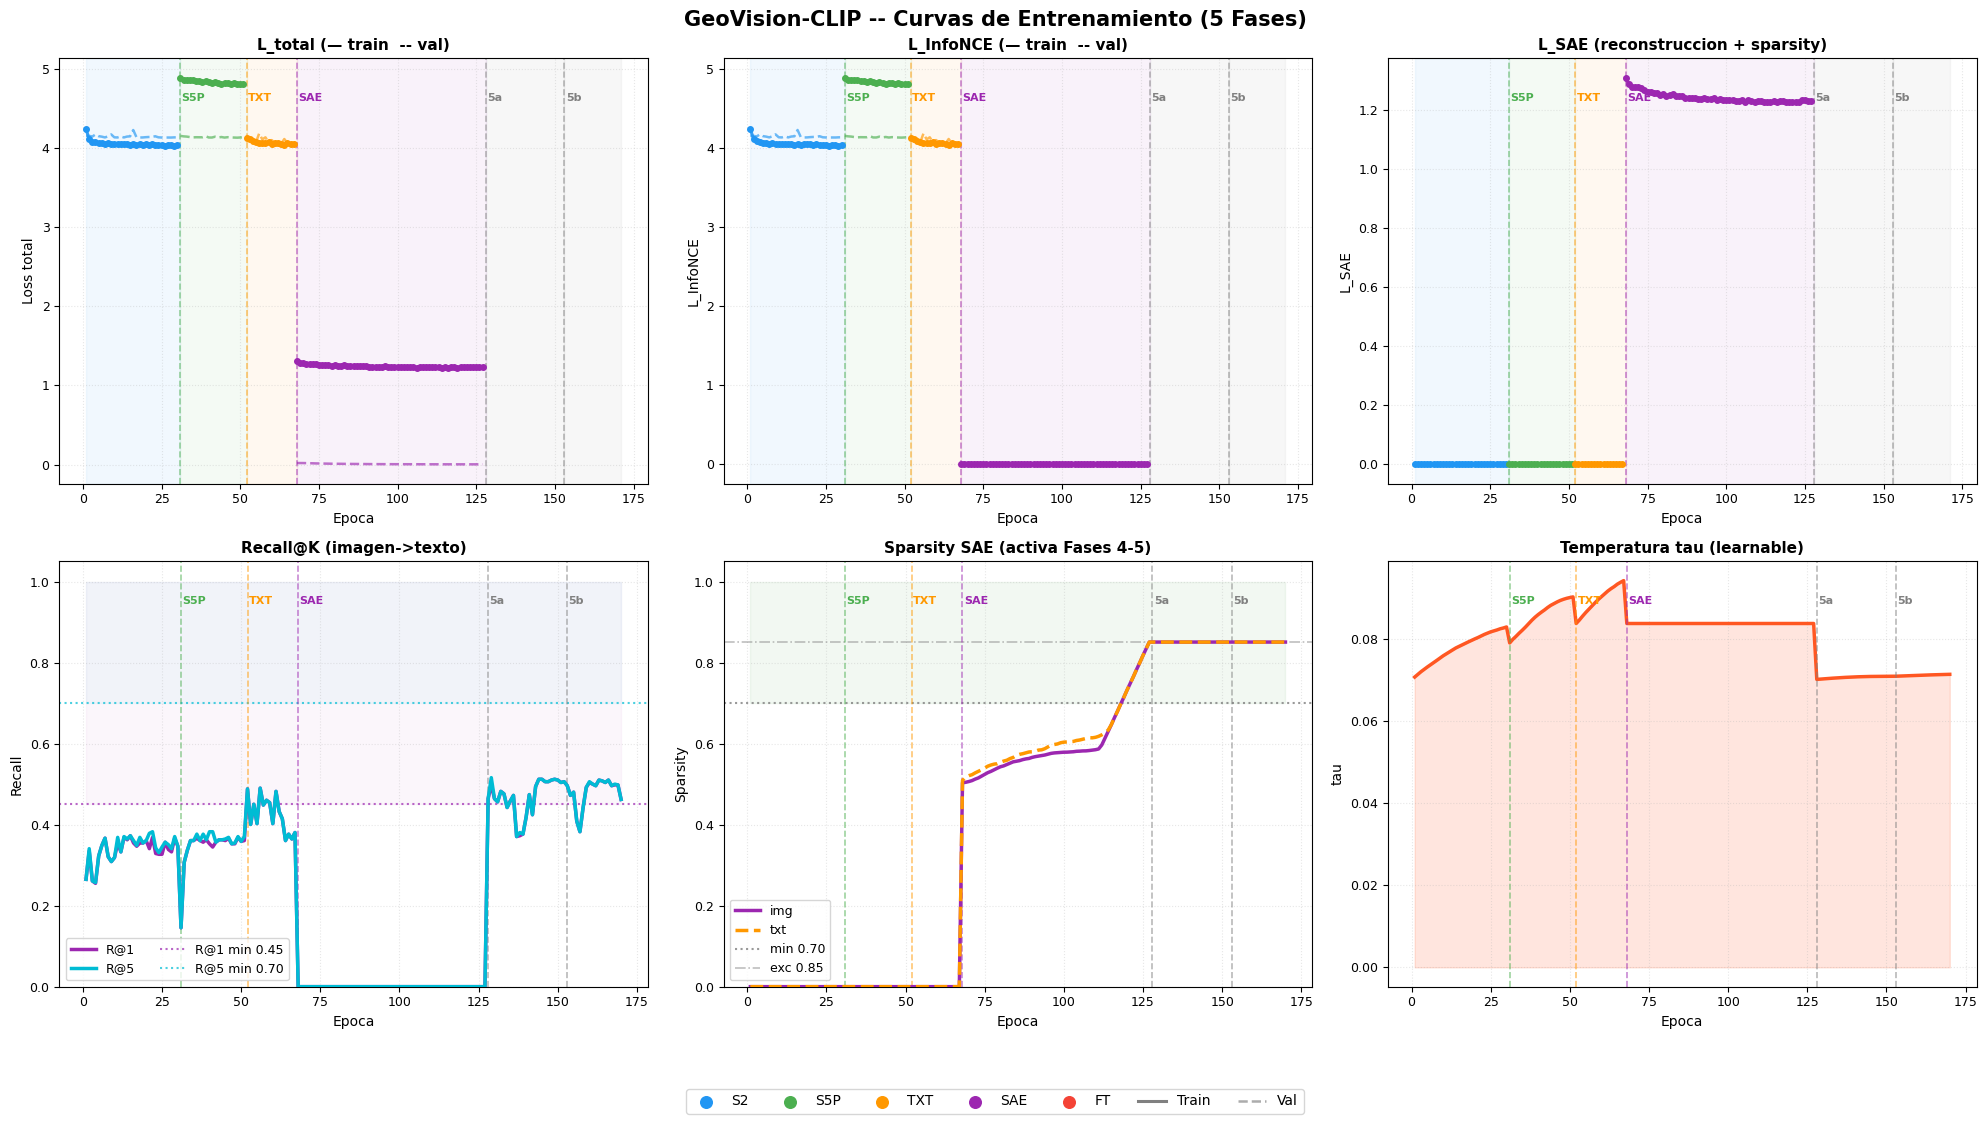

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/geovision_clip_training_curves_4cec2766.png


In [25]:
# Curvas de entrenamiento -- con separacion visual por fases

def plot_training_curves(history: Dict) -> None:
    PHASE_COLORS = {
        'S2':  '#2196F3', 'S5P': '#4CAF50',
        'TXT': '#FF9800', 'SAE': '#9C27B0', 'FT': '#F44336',
    }
    labels  = history.get('phase_label', [])
    n       = len(history['train_loss'])
    epochs  = list(range(1, n + 1))

    phase_starts = {}
    for i, ph in enumerate(labels):
        if ph not in phase_starts:
            phase_starts[ph] = i + 1

    def _vlines(ax):
        lo, hi = ax.get_ylim()
        for ph, ep in phase_starts.items():
            if ep > 1:
                ax.axvline(ep, color=PHASE_COLORS.get(ph, 'grey'), ls='--', alpha=0.55, lw=1.2)
                ax.text(ep + 0.4, lo + (hi - lo) * 0.90, ph,
                        fontsize=8, color=PHASE_COLORS.get(ph, 'grey'), fontweight='bold')

    def _plot_phase(ax, values, ylabel, val_values=None):
        if not values:
            return
        # Fondo semitransparente por fase
        ph_list = sorted(phase_starts.items(), key=lambda x: x[1])
        for idx, (ph, ep_start) in enumerate(ph_list):
            ep_end = ph_list[idx+1][1] if idx+1 < len(ph_list) else n+1
            ax.axvspan(ep_start, ep_end, alpha=0.06, color=PHASE_COLORS.get(ph, 'grey'))
        # Linea por fase (train sólida, val discontinua)
        for ph in PHASE_COLORS:
            idxs = [i for i, lb in enumerate(labels) if lb == ph]
            px = [i+1 for i in idxs if i < len(values) and values[i] is not None]
            py = [values[i] for i in idxs if i < len(values) and values[i] is not None]
            if px:
                ax.plot(px, py, color=PHASE_COLORS[ph], lw=2.2, alpha=0.9, label='_nolegend_')
                ax.scatter(px, py, color=PHASE_COLORS[ph], s=16, zorder=4)
            if val_values is not None:
                vx = [i+1 for i in idxs if i < len(val_values) and val_values[i] is not None and val_values[i] != 0.]
                vy = [val_values[i] for i in idxs if i < len(val_values) and val_values[i] is not None and val_values[i] != 0.]
                if vx:
                    ax.plot(vx, vy, color=PHASE_COLORS[ph], lw=1.8, ls='--', alpha=0.65, label='_nolegend_')
        ax.set_ylabel(ylabel, fontsize=10); ax.set_xlabel('Epoca', fontsize=10)
        ax.grid(alpha=0.3, linestyle=':'); ax.tick_params(labelsize=9)

    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle('GeoVision-CLIP -- Curvas de Entrenamiento (5 Fases)',
                 fontsize=15, fontweight='bold')

    handles = [plt.scatter([], [], color=c, s=70, label=ph) for ph, c in PHASE_COLORS.items()]
    handles += [
        plt.Line2D([0], [0], color='grey', lw=2.2, label='Train'),
        plt.Line2D([0], [0], color='grey', lw=1.8, ls='--', alpha=0.65, label='Val'),
    ]
    fig.legend(handles=handles, ncol=7, fontsize=10,
               loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True)

    ax = axes[0, 0]
    _plot_phase(ax, history['train_loss'], 'Loss total', val_values=history['val_loss'])
    ax.set_title('L_total (— train  -- val)', fontsize=11, fontweight='bold'); _vlines(ax)

    ax = axes[0, 1]
    _plot_phase(ax, history['train_infonce'], 'L_InfoNCE', val_values=history['val_loss'])
    ax.set_title('L_InfoNCE (— train  -- val)', fontsize=11, fontweight='bold'); _vlines(ax)

    ax = axes[0, 2]
    _plot_phase(ax, history['train_sae'], 'L_SAE')
    ax.set_title('L_SAE (reconstruccion + sparsity)', fontsize=11, fontweight='bold'); _vlines(ax)

    ax = axes[1, 0]
    r1_vals = [v if v is not None else float('nan') for v in history['recall_at_1']]
    r5_vals = [v if v is not None else float('nan') for v in history['recall_at_5']]
    ax.plot(epochs, r1_vals, color='#9C27B0', lw=2.5, label='R@1', zorder=5)
    ax.plot(epochs, r5_vals, color='#00BCD4', lw=2.5, label='R@5', zorder=5)
    ax.axhline(0.45, color='#9C27B0', ls=':', lw=1.5, alpha=0.7, label='R@1 min 0.45')
    ax.axhline(0.70, color='#00BCD4', ls=':', lw=1.5, alpha=0.7, label='R@5 min 0.70')
    ax.fill_between(epochs, 0.45, 1.0, alpha=0.04, color='#9C27B0')
    ax.fill_between(epochs, 0.70, 1.0, alpha=0.04, color='#00BCD4')
    ax.set_ylim(0, 1.05); _vlines(ax)
    ax.set_title('Recall@K (imagen->texto)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoca', fontsize=10); ax.set_ylabel('Recall', fontsize=10)
    ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3, linestyle=':'); ax.tick_params(labelsize=9)

    ax = axes[1, 1]
    sp_img = [v if v is not None else float('nan') for v in history['sparsity_img']]
    sp_txt = [v if v is not None else float('nan') for v in history['sparsity_txt']]
    ax.plot(epochs, sp_img, color='#9C27B0', lw=2.5, label='img', zorder=5)
    ax.plot(epochs, sp_txt, color='#FF9800', lw=2.5, ls='--', label='txt', zorder=5)
    ax.axhline(0.70, color='grey', ls=':', lw=1.5, alpha=0.8, label='min 0.70')
    ax.axhline(0.85, color='grey', ls='-.', lw=1.2, alpha=0.5, label='exc 0.85')
    ax.fill_between(epochs, 0.70, 1.0, alpha=0.05, color='green')
    ax.set_ylim(0, 1.05); _vlines(ax)
    ax.set_title('Sparsity SAE (activa Fases 4-5)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoca', fontsize=10); ax.set_ylabel('Sparsity', fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, linestyle=':'); ax.tick_params(labelsize=9)

    ax = axes[1, 2]
    ax.plot(epochs, history['tau'], color='#FF5722', lw=2.5)
    ax.fill_between(epochs, history['tau'], alpha=0.15, color='#FF5722')
    _vlines(ax)
    ax.set_title('Temperatura tau (learnable)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoca', fontsize=10); ax.set_ylabel('tau', fontsize=10)
    ax.grid(alpha=0.3, linestyle=':'); ax.tick_params(labelsize=9)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    import os, hashlib
    _tmp = '/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/geovision_clip_training_curves.png'
    plt.savefig(_tmp, dpi=150, bbox_inches='tight')
    plt.show()
    _md5 = hashlib.md5(open(_tmp, 'rb').read()).hexdigest()[:8]
    _fin = f'/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/geovision_clip_training_curves_{_md5}.png'
    os.rename(_tmp, _fin)
    print(f'Figura guardada: {_fin}')


plot_training_curves(history)


In [26]:
# KPIs finales — GeoVision-CLIP
import torch, numpy as np
import torch.nn.functional as F

model.eval()

def eval_recall(dl, model, device):
    all_e_img, all_e_txt, all_labels = [], [], []
    with torch.no_grad():
        for tiles, vecs, texts, labels in dl:
            out = model(tiles.to(device), vecs.to(device), texts)
            all_e_img.append(out['e_img'].cpu())
            all_e_txt.append(out['e_txt'].cpu())
            all_labels.append(labels)
    lbl = torch.cat(all_labels, dim=0)
    return compute_recall_at_k(
        torch.cat(all_e_img), torch.cat(all_e_txt),
        labels=lbl, k_values=[1, 5]
    )


def eval_sae_mse(dl, model, device):
    """MSE de reconstrucción SAE — Camino B: SAE opera sobre espacio 256D normalizado."""
    model.eval()
    mse_list = []
    with torch.no_grad():
        for tiles, vecs, texts, _ in dl:
            tiles, vecs = tiles.to(device), vecs.to(device)
            vecs = torch.nan_to_num(vecs, nan=0.0)
            cls_s2  = model.s2_encoder(tiles)
            cls_s5p = model.s5p_encoder(vecs)
            fused   = model.fusion(cls_s2, cls_s5p)
            fused   = torch.nan_to_num(fused, nan=0.0, posinf=1.0, neginf=-1.0)
            # Camino B: input al SAE = L2-norm(proj_vis(fused))
            e_pre = F.normalize(model.proj_vis(fused).float(), dim=-1)
            x_hat, _, _ = model.sae(e_pre)
            x_hat  = torch.nan_to_num(x_hat, nan=0.0)
            x_norm = model.sae.pre_norm(e_pre)
            x_unit_e = F.normalize(x_norm, dim=-1)
            batch_mse = F.mse_loss(x_hat, x_unit_e).item()
            if np.isfinite(batch_mse):
                mse_list.append(batch_mse)
    model.train()
    return float(np.mean(mse_list)) if mse_list else float('inf')


recalls_val  = eval_recall(val_dl,  model, DEVICE)
recalls_test = eval_recall(test_dl, model, DEVICE)
mse_visual   = eval_sae_mse(val_dl, model, DEVICE)

sp_visual = (model.sae.latent_dim - model.sae.k) / model.sae.latent_dim
sp_txt    = (model.text_encoder.sae.latent_dim - model.text_encoder.sae.k) / model.text_encoder.sae.latent_dim

r1_v = recalls_val['R@1'];  r5_v = recalls_val['R@5']
r1_t = recalls_test['R@1']; r5_t = recalls_test['R@5']

def chk(val, minv, excv, higher=True):
    if higher: return 'EXCELENTE' if val>=excv else ('MINIMO' if val>=minv else 'BAJO')
    return 'EXCELENTE' if val<=excv else ('MINIMO' if val<=minv else 'ALTO')

print('=' * 70)
print('  REPORTE FINAL DE KPIs — GeoVision-CLIP')
print('=' * 70)
print(f"{'Metrica':<38} {'Val':>7} {'Test':>7} {'Min':>6} {'Exc':>6}  Estado")
print('-' * 70)
print(f"{'Recall@1 (img->txt clase)':<38} {r1_v:>7.3f} {r1_t:>7.3f} {'0.45':>6} {'0.65':>6}  {chk(r1_t,0.45,0.65)}")
print(f"{'Recall@5 (img->txt clase)':<38} {r5_v:>7.3f} {r5_t:>7.3f} {'0.70':>6} {'0.85':>6}  {chk(r5_t,0.70,0.85)}")
print(f"{'Sparsity SAE visual':<38} {sp_visual:>7.3f} {'--':>7} {'0.70':>6} {'0.85':>6}  {chk(sp_visual,0.70,0.85)}")
print(f"{'Sparsity SAE textual':<38} {sp_txt:>7.3f} {'--':>7} {'0.70':>6} {'0.85':>6}  {chk(sp_txt,0.70,0.85)}")
print(f"{'MSE recon SAE visual':<38} {mse_visual:>7.4f} {'--':>7} {'0.05':>6} {'0.02':>6}  {chk(mse_visual,0.05,0.02,higher=False)}")
print('=' * 70)

# ── Recall@1 por clase con textos canónicos (diagnostico de sesgo) ─────────
print('\n=== RECALL@1 POR CLASE (macro) — test ===')
NOMBRES_C = ['NO2-industrial', 'SO2-quema', 'O3-anomalo', 'Vegetacion', 'Urbano']
model.eval()
_all_eimg, _all_lbl = [], []
with torch.no_grad():
    for _t, _v, _tx, _lb in test_dl:
        _out = model(_t.to(DEVICE), torch.nan_to_num(_v.to(DEVICE), nan=0.0), _tx)
        _all_eimg.append(_out['e_img'].cpu()); _all_lbl.append(_lb)
_Eimg = F.normalize(torch.cat(_all_eimg), dim=-1)
_Llbl = torch.cat(_all_lbl)
_T_can = []
with torch.no_grad():
    # v17: ensemble de textos por clase
    _texts_eval = TEXTOS_CLASE_ENSEMBLE if 'TEXTOS_CLASE_ENSEMBLE' in dir() else [[t] for t in TEXTOS_CLASE]
    for _class_texts in _texts_eval:
        _embeds = []
        for _txt in _class_texts:
            _e, _ = model.text_encoder([_txt], phase=2)
            _embeds.append(F.normalize(_e.cpu().float(), dim=-1))
        _T_can.append(F.normalize(torch.stack(_embeds).mean(0), dim=-1))
_T_can = torch.cat(_T_can)          # (5, 256)
_sims  = _Eimg @ _T_can.T           # (N, 5)
_preds = _sims.argmax(dim=1)
_macro = []
for _c in range(5):
    _mask = _Llbl == _c
    if _mask.sum() == 0: continue
    _hit  = (_preds[_mask] == _c).float().mean().item()
    _macro.append(_hit)
    print(f'  R@1 {NOMBRES_C[_c]:<18}: {_hit:.3f}  (n={int(_mask.sum())})')
print(f'  R@1 MACRO             : {sum(_macro)/len(_macro):.3f}')
print(f'  tau actual            : {model.tau.item():.4f}')
# ── Recall canónico (img vs 5 textos de clase) — más interpretable ─────────
print('\n=== RECALL CANÓNICO (img → 5 textos clase) ===')
model.eval()
def _rc(dl):
    _eimg, _lbl = [], []
    with torch.no_grad():
        _ecan = []
        # v17: usar ensemble de textos por clase para evaluación más robusta
        _texts_eval = TEXTOS_CLASE_ENSEMBLE if 'TEXTOS_CLASE_ENSEMBLE' in dir() else [[t] for t in TEXTOS_CLASE]
        for _class_texts in _texts_eval:
            _embeds = []
            for _t in _class_texts:
                _e, _ = model.text_encoder([_t], phase=2)
                _embeds.append(F.normalize(_e.float(), dim=-1).cpu())
            _ecan.append(F.normalize(torch.stack(_embeds).mean(0), dim=-1))
        _Ecan = torch.cat(_ecan)
        for _ti, _vi, _txi, _li in dl:
            _o = model(_ti.to(DEVICE), torch.nan_to_num(_vi.to(DEVICE), nan=0.0), _txi)
            _eimg.append(F.normalize(_o['e_img'].float(), dim=-1).cpu()); _lbl.append(_li)
    _Ei = torch.cat(_eimg); _lb = torch.cat(_lbl)
    _s  = _Ei @ _Ecan.T
    out = {}
    for _k in [1, 5]:
        _t = _s.topk(min(_k,5), dim=1).indices
        out[f'R@{_k}'] = (_t == _lb.unsqueeze(1)).any(dim=1).float().mean().item()
    return out
_rc_val  = _rc(val_dl)
_rc_test = _rc(test_dl)
print(f"  Val  R@1={_rc_val['R@1']:.3f}  R@5={_rc_val['R@5']:.3f}  (vs 5 textos canónicos)")
print(f"  Test R@1={_rc_test['R@1']:.3f}  R@5={_rc_test['R@5']:.3f}  (vs 5 textos canónicos)")


  REPORTE FINAL DE KPIs — GeoVision-CLIP
Metrica                                    Val    Test    Min    Exc  Estado
----------------------------------------------------------------------
Recall@1 (img->txt clase)                0.480   0.462   0.45   0.65  MINIMO
Recall@5 (img->txt clase)                0.480   0.464   0.70   0.85  BAJO
Sparsity SAE visual                      0.851      --   0.70   0.85  EXCELENTE
Sparsity SAE textual                     0.851      --   0.70   0.85  EXCELENTE
MSE recon SAE visual                    0.0056      --   0.05   0.02  EXCELENTE

=== RECALL@1 POR CLASE (macro) — test ===
  R@1 NO2-industrial    : 0.000  (n=27)
  R@1 SO2-quema         : 0.000  (n=96)
  R@1 O3-anomalo        : 0.788  (n=80)
  R@1 Vegetacion        : 0.778  (n=27)
  R@1 Urbano            : 0.279  (n=272)
  R@1 MACRO             : 0.369
  tau actual            : 0.0709

=== RECALL CANÓNICO (img → 5 textos clase) ===


NameError: name 'TEXTOS_CLASE' is not defined

In [27]:
# Diagnostico de splits y dominancia de modalidad
# Verifica: distribucion de clases en val vs test, y normas S2 vs S5P
import math


NOMBRES_CLASE = [
    'Alta NO2 (industrial)', 'SO2/Quema (cana)', 'O3 anomalo',
    'Vegetacion/Limpio', 'Urbano moderado',
]
COLORES_CLASE = ['#E24B4A', '#EF9F27', '#3b9dd8', '#2da87e', '#7c6af7']

print('=== DISTRIBUCION DE CLASES POR SPLIT ===')
for split_name, dl in [('val', val_dl), ('test', test_dl)]:
    all_labels = torch.cat([b[3] for b in dl])
    counts = torch.bincount(all_labels, minlength=5)
    total  = len(all_labels)
    print(f"  {split_name:5s} (N={total}): {counts.tolist()}")
    for ci, (cnt, nombre) in enumerate(zip(counts.tolist(), NOMBRES_CLASE)):
        print(f"    clase {ci} {nombre:<25}: {cnt:4d}  ({100*cnt/total:5.1f}%)")

print()
print('=== NORMAS S2 vs S5P (primera iteracion val) ===')
model.eval()
with torch.no_grad():
    for tiles, vecs, texts, labels in val_dl:
        tiles, vecs = tiles.to(DEVICE), vecs.to(DEVICE)
        vecs = torch.nan_to_num(vecs, nan=0.0)
        cls_s2  = model.s2_encoder(tiles)
        cls_s5p = model.s5p_encoder(vecs)
        n_s2  = cls_s2.norm(dim=-1).mean().item()
        n_s5p = cls_s5p.norm(dim=-1).mean().item()
        ratio = n_s5p / max(n_s2, 1e-6)
        print(f"  S2  norm media:  {n_s2:.3f}")
        print(f"  S5P norm media:  {n_s5p:.3f}")
        print(f"  ratio S5P/S2:    {ratio:.3f}  {'⚠ S5P domina' if ratio > 2.0 else 'OK'}")
        break

print()
print(f'=== TEMPERATURA actual ===')
print(f"  log_tau = {model.log_tau.item():.4f}")
print(f"  tau     = {model.tau.item():.4f}  (CLIP default: 0.07)")
print(f"  logits_scale = 1/tau = {1.0/model.tau.item():.1f}x")
if model.tau.item() < 0.05:
    print("  ⚠ tau MUY BAJO — logits demasiado agudos, riesgo de sobreajuste")
elif model.tau.item() > 0.3:
    print("  ⚠ tau MUY ALTO — logits demasiado suaves, recuperacion mala")
else:
    print("  tau en rango saludable [0.05, 0.30]")


=== DISTRIBUCION DE CLASES POR SPLIT ===
  val   (N=502): [27, 96, 80, 33, 266]
    clase 0 Alta NO2 (industrial)    :   27  (  5.4%)
    clase 1 SO2/Quema (cana)         :   96  ( 19.1%)
    clase 2 O3 anomalo               :   80  ( 15.9%)
    clase 3 Vegetacion/Limpio        :   33  (  6.6%)
    clase 4 Urbano moderado          :  266  ( 53.0%)
  test  (N=502): [27, 96, 80, 27, 272]
    clase 0 Alta NO2 (industrial)    :   27  (  5.4%)
    clase 1 SO2/Quema (cana)         :   96  ( 19.1%)
    clase 2 O3 anomalo               :   80  ( 15.9%)
    clase 3 Vegetacion/Limpio        :   27  (  5.4%)
    clase 4 Urbano moderado          :  272  ( 54.2%)

=== NORMAS S2 vs S5P (primera iteracion val) ===
  S2  norm media:  27.732
  S5P norm media:  27.593
  ratio S5P/S2:    0.995  OK

=== TEMPERATURA actual ===
  log_tau = -2.6466
  tau     = 0.0709  (CLIP default: 0.07)
  logits_scale = 1/tau = 14.1x
  tau en rango saludable [0.05, 0.30]


In [28]:
# ¿Qué clase predice el modelo para las imágenes de SO2?
model.eval()
with torch.no_grad():
    e_can = torch.cat([
        F.normalize(model.text_encoder([t], phase=1)[0].float(), dim=-1).cpu()
        for t in TEXTOS_CLASE
    ])  # (5, 256)

predicciones_so2 = []
with torch.no_grad():
    for tiles, vecs, texts, lbls in val_dl:
        mask = lbls == 1  # SO2
        if mask.sum() == 0: continue
        tiles_so2 = tiles[mask].to(DEVICE)
        vecs_so2  = vecs[mask].to(DEVICE)
        cls_s2    = model.s2_encoder(tiles_so2)
        cls_s5p   = model.s5p_encoder(vecs_so2)
        fused     = model.fusion(cls_s2, cls_s5p)
        e_img     = F.normalize(model.visual_proj_phase1(fused).float(), dim=-1).cpu()
        preds     = (e_img @ e_can.T).argmax(dim=1)
        predicciones_so2.extend(preds.tolist())

from collections import Counter
print("Predicciones del modelo para imágenes SO2:")
print(Counter(predicciones_so2))
# Si dice {4: 90, 0: 6} → el modelo ve SO2 como Urbano → problema de texto
# Si dice {1: 0, ...}   → confirma R@1=0.000

NameError: name 'TEXTOS_CLASE' is not defined

### Análisis de Features del SAE Visual por Clase de Contaminación

Identifica qué neuronas del SAE (aplicado al espacio fusionado S2+S5P) se activan
para cada clase. Cumple el requisito de **interpretabilidad** (Situación 2).


Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/sae_visual_features_detalle.png


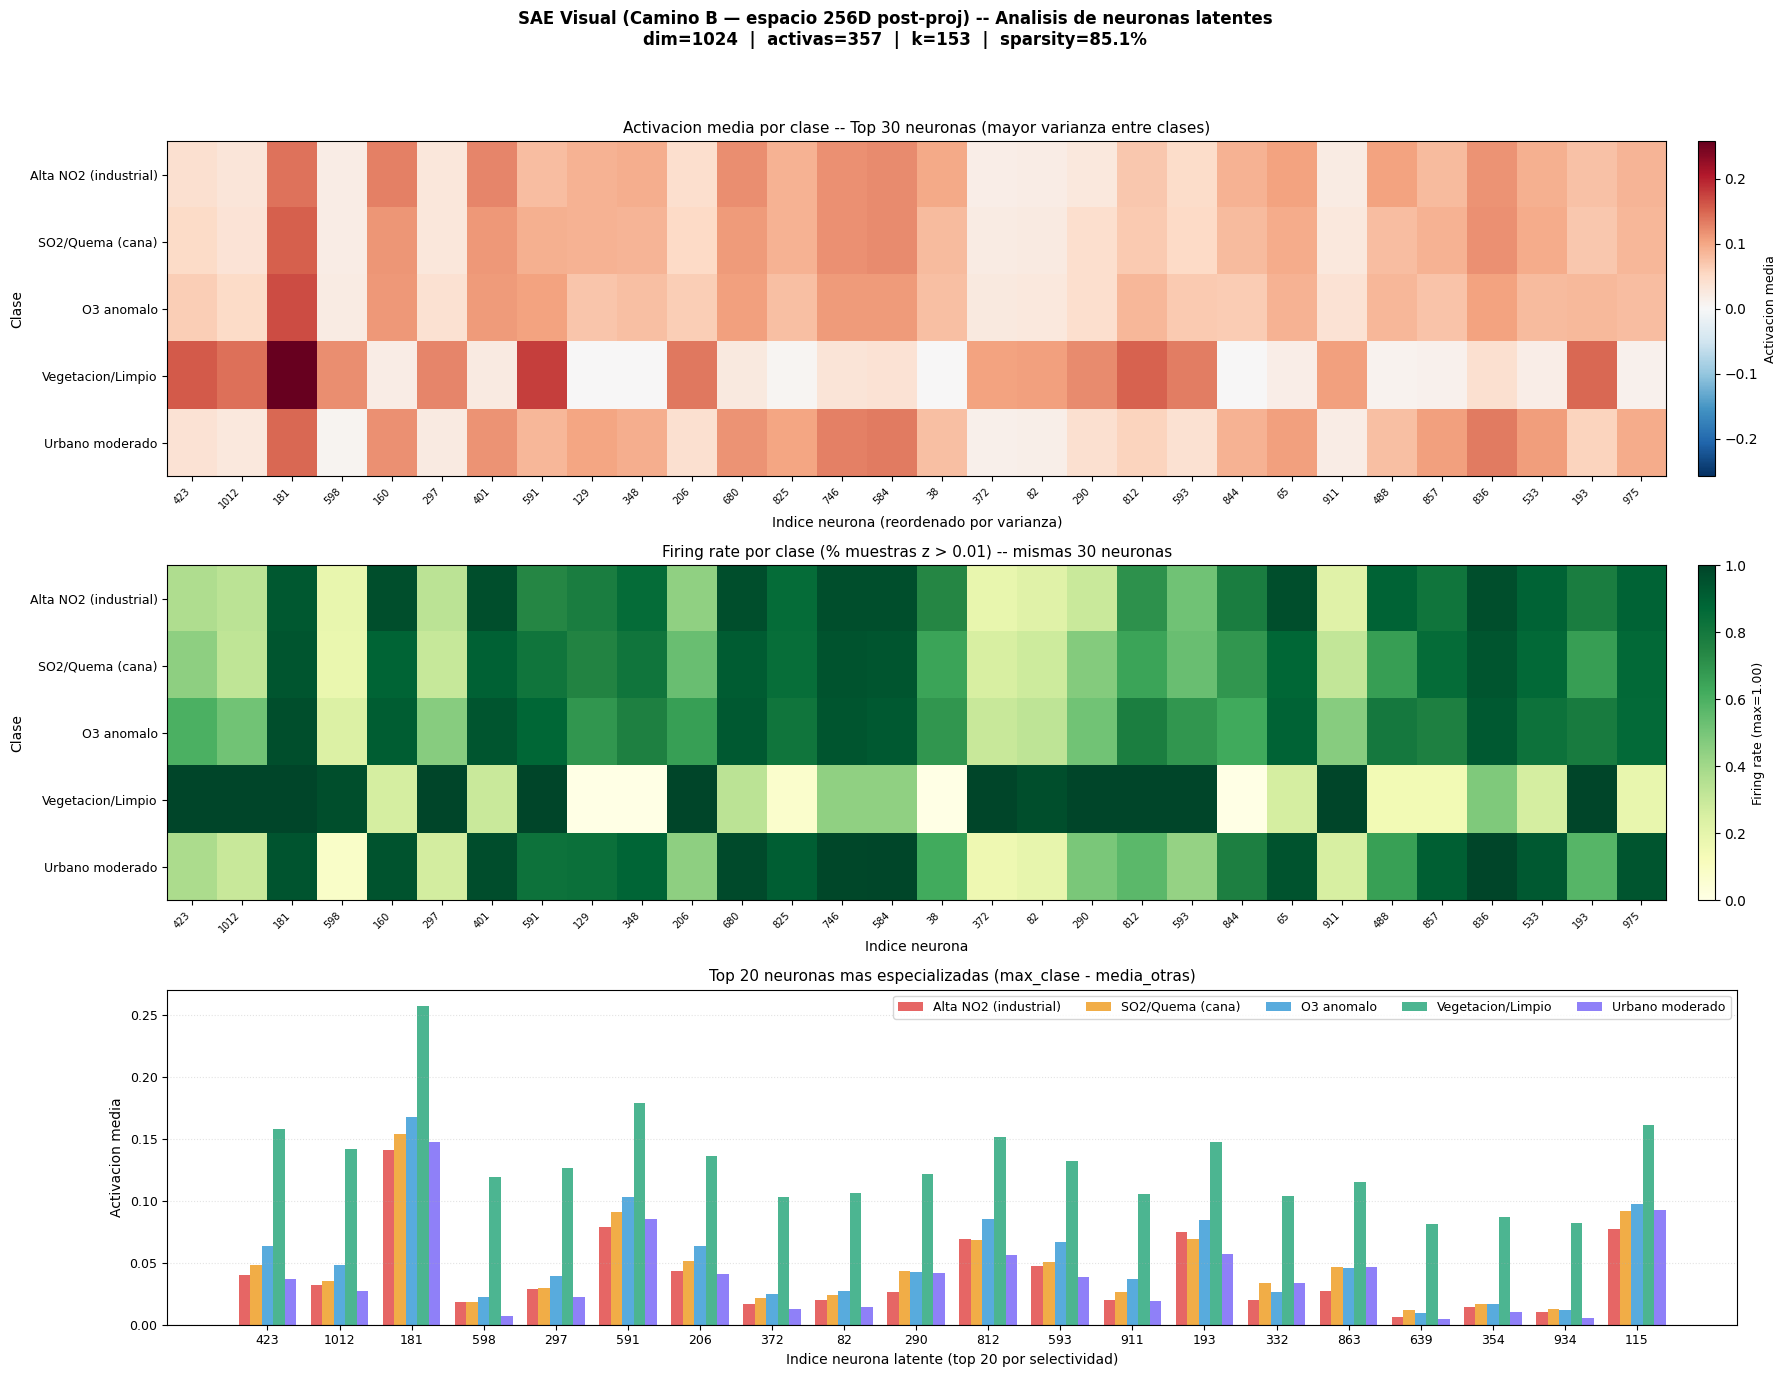


Neuronas muertas (firing=0 en todas las clases): 629 / 1024
Neuronas activas: 395 (38.6%)
Activacion global media: 0.014584
Activacion max absoluta: 0.258021
Clase con mayor activacion: Urbano moderado


In [29]:
# Analisis de features del SAE visual (espacio fusionado S2+S5P) por clase


def extraer_activaciones_sae_visual(model, dataloader, n_clases=5):
    model.eval()
    latent_dim = model.sae.latent_dim
    acc  = [[] for _ in range(n_clases)]
    fire = [[] for _ in range(n_clases)]
    with torch.no_grad():
        for tiles, vecs, _, labels in dataloader:
            tiles, vecs = tiles.to(DEVICE), vecs.to(DEVICE)
            vecs = torch.nan_to_num(vecs, nan=0.0)
            cls_s2  = model.s2_encoder(tiles)
            cls_s5p = model.s5p_encoder(vecs)
            fused   = model.fusion(cls_s2, cls_s5p)
            fused   = torch.nan_to_num(fused, nan=0.0, posinf=1.0, neginf=-1.0)
            # Camino B: SAE opera sobre espacio 256D normalizado
            e_pre = F.normalize(model.proj_vis(fused).float(), dim=-1)
            _, z, _ = model.sae(e_pre)
            z_np = torch.nan_to_num(z, nan=0.0).cpu().float().numpy()
            for i, lbl in enumerate(labels.tolist()):
                c = int(lbl) % n_clases
                acc[c].append(z_np[i])
                fire[c].append((z_np[i] > 0.01).astype(float))
    mean_z = np.stack([np.mean(acc[c], axis=0) if acc[c] else np.zeros(latent_dim) for c in range(n_clases)])
    fire_z = np.stack([np.mean(fire[c], axis=0) if fire[c] else np.zeros(latent_dim) for c in range(n_clases)])
    return mean_z, fire_z


def plot_sae_visual_features(mean_z, fire_z, n_top=30, save=True):
    latent_dim = mean_z.shape[1]
    active_mask = fire_z.max(axis=0) > 0.05
    n_active = int(active_mask.sum())

    max_act     = mean_z.max(axis=0)
    other_mean  = (mean_z.sum(axis=0) - max_act) / max(len(NOMBRES_CLASE) - 1, 1)
    selectivity = max_act - other_mean

    # Top por varianza -- preferir neuronas activas
    var_scores = mean_z.var(axis=0)
    if n_active >= n_top:
        cands   = np.where(active_mask)[0]
        var_idx = cands[np.argsort(var_scores[cands])[::-1][:n_top]]
    else:
        var_idx = np.argsort(var_scores)[::-1][:n_top]
    sel_idx = np.argsort(selectivity)[::-1][:20]

    mat      = mean_z[:, var_idx]
    mat2     = fire_z[:, var_idx]
    abs_max  = max(float(np.abs(mat).max()), 1e-6)
    fr_max   = max(float(mat2.max()), 0.01)

    fig, axes = plt.subplots(3, 1, figsize=(18, 14))
    sp_pct = (latent_dim - model.sae.k) / latent_dim
    fig.suptitle(
        f'SAE Visual (Camino B — espacio 256D post-proj) -- Analisis de neuronas latentes\n'
        f'dim={latent_dim}  |  activas={n_active}  |  k={model.sae.k}  |  sparsity={sp_pct:.1%}',
        fontsize=12, fontweight='bold'
    )

    # 1. Activacion media -- colormap divergente (azul=inhibicion, rojo=activacion)
    ax = axes[0]
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                   vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    ax.set_title(f'Activacion media por clase -- Top {n_top} neuronas (mayor varianza entre clases)', fontsize=11)
    ax.set_xlabel('Indice neurona (reordenado por varianza)', fontsize=10)
    ax.set_ylabel('Clase', fontsize=10)
    ax.set_yticks(range(len(NOMBRES_CLASE))); ax.set_yticklabels(NOMBRES_CLASE, fontsize=9)
    ax.set_xticks(range(n_top))
    ax.set_xticklabels([str(v) for v in var_idx], fontsize=7, rotation=45, ha='right')
    cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.set_label('Activacion media', fontsize=9)
    if n_active == 0:
        ax.text(0.5, 0.5, 'SAE subutilizado -- re-entrenar con fix de early stop',
                transform=ax.transAxes, ha='center', va='center', fontsize=12,
                color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # 2. Firing rate -- YlGn: 0=blanco, alto=verde oscuro
    ax2 = axes[1]
    im2 = ax2.imshow(mat2, aspect='auto', cmap='YlGn',
                     vmin=0, vmax=fr_max, interpolation='nearest')
    ax2.set_title(f'Firing rate por clase (% muestras z > 0.01) -- mismas {n_top} neuronas', fontsize=11)
    ax2.set_xlabel('Indice neurona', fontsize=10); ax2.set_ylabel('Clase', fontsize=10)
    ax2.set_yticks(range(len(NOMBRES_CLASE))); ax2.set_yticklabels(NOMBRES_CLASE, fontsize=9)
    ax2.set_xticks(range(n_top))
    ax2.set_xticklabels([str(v) for v in var_idx], fontsize=7, rotation=45, ha='right')
    cb2 = plt.colorbar(im2, ax=ax2, fraction=0.025, pad=0.02)
    cb2.set_label(f'Firing rate (max={fr_max:.2f})', fontsize=9)

    # 3. Barras -- top 20 neuronas por selectividad
    ax3 = axes[2]
    x = np.arange(20); w = 0.16
    for ci, (nombre, color) in enumerate(zip(NOMBRES_CLASE, COLORES_CLASE)):
        vals = mean_z[ci, sel_idx]
        ax3.bar(x + ci * w, vals, width=w, label=nombre, color=color, alpha=0.85)
    ax3.set_xticks(x + w * 2)
    ax3.set_xticklabels([str(i) for i in sel_idx], fontsize=8)
    ax3.set_xlabel('Indice neurona latente (top 20 por selectividad)', fontsize=10)
    ax3.set_ylabel('Activacion media', fontsize=10)
    ax3.set_title('Top 20 neuronas mas especializadas (max_clase - media_otras)', fontsize=11)
    ax3.legend(fontsize=9, ncol=5, loc='upper right')
    ax3.grid(axis='y', alpha=0.35, linestyle=':'); ax3.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax3.tick_params(labelsize=9)
    if float(np.abs(mean_z[:, sel_idx]).max()) < 1e-3:
        ax3.text(0.5, 0.5, 'Activaciones muy bajas -- SAE necesita mas entrenamiento',
                 transform=ax3.transAxes, ha='center', va='center', fontsize=11, color='red',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save:
        path = '/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/sae_visual_features_detalle.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Figura guardada: {path}')
    plt.show()


mean_z_vis, fire_z_vis = extraer_activaciones_sae_visual(model, test_dl)
plot_sae_visual_features(mean_z_vis, fire_z_vis)

n_dead = int((fire_z_vis.max(axis=0) == 0).sum())
n_active = fire_z_vis.shape[1] - n_dead
print(f'\nNeuronas muertas (firing=0 en todas las clases): {n_dead} / {mean_z_vis.shape[1]}')
print(f'Neuronas activas: {n_active} ({100*n_active/mean_z_vis.shape[1]:.1f}%)')
print(f'Activacion global media: {mean_z_vis.mean():.6f}')
print(f'Activacion max absoluta: {float(np.abs(mean_z_vis).max()):.6f}')
if mean_z_vis.mean(axis=1).max() > 1e-6:
    print(f'Clase con mayor activacion: {NOMBRES_CLASE[mean_z_vis.mean(axis=1).argmax()]}')
else:
    print('Advertencia: SAE con activaciones ~0 -- re-entrenar con el fix de early stop aplicado')


In [30]:
# Analisis de features del SAE textual (RemoteCLIP text encoder) por clase

def extraer_activaciones_sae_txt(model, dataloader=None, n_clases=5):
    model.eval()
    sae_latent = model.text_encoder.sae.latent_dim
    dev = next(model.text_encoder.proj_txt.parameters()).device   # Camino B: proj_txt

    def _encode_raw(texts):
        raw = model.text_encoder._encode_raw(list(texts)).to(dev).float()   # (B, 768)
        return F.normalize(model.text_encoder.proj_txt(raw).float(), dim=-1)  # (B, 256)

    if dataloader is None:
        with torch.no_grad():
            raw = _encode_raw(TEXTOS_CLASE)
            _, z_txt, _ = model.text_encoder.sae(raw)
        z_np   = torch.nan_to_num(z_txt, nan=0.0).cpu().numpy()
        mean_z = z_np
        fire_z = (z_np > 0.01).astype(float)
    else:
        acc  = [[] for _ in range(n_clases)]
        fire = [[] for _ in range(n_clases)]
        with torch.no_grad():
            for _, _, texts, labels in dataloader:
                raw = _encode_raw(list(texts))
                _, z_txt, _ = model.text_encoder.sae(raw)
                z_np = torch.nan_to_num(z_txt, nan=0.0).cpu().numpy()
                for i, lbl in enumerate(labels.tolist()):
                    c = int(lbl) % n_clases
                    acc[c].append(z_np[i])
                    fire[c].append((z_np[i] > 0.01).astype(float))
        mean_z = np.stack([np.mean(acc[c], axis=0) if acc[c] else np.zeros(sae_latent) for c in range(n_clases)])
        fire_z = np.stack([np.mean(fire[c], axis=0) if fire[c] else np.zeros(sae_latent) for c in range(n_clases)])
    return mean_z, fire_z


def plot_sae_txt_features(mean_z, fire_z, n_top=30, title_suffix='', save=True, fname=None):
    latent_dim  = mean_z.shape[1]
    active_mask = fire_z.max(axis=0) > 0.05
    n_active    = int(active_mask.sum())

    max_act     = mean_z.max(axis=0)
    other_mean  = (mean_z.sum(axis=0) - max_act) / max(len(NOMBRES_CLASE) - 1, 1)
    selectivity = max_act - other_mean

    var_scores = mean_z.var(axis=0)
    if n_active >= n_top:
        cands   = np.where(active_mask)[0]
        var_idx = cands[np.argsort(var_scores[cands])[::-1][:n_top]]
    else:
        var_idx = np.argsort(var_scores)[::-1][:n_top]
    sel_idx = np.argsort(selectivity)[::-1][:20]

    mat      = mean_z[:, var_idx]
    mat2     = fire_z[:, var_idx]
    abs_max  = max(float(np.abs(mat).max()), 1e-6)
    fr_max   = max(float(mat2.max()), 0.01)

    fig, axes = plt.subplots(3, 1, figsize=(18, 14))
    sp_pct = (latent_dim - model.text_encoder.sae.k) / latent_dim
    fig.suptitle(
        f'SAE Textual (RemoteCLIP text encoder) -- Neuronas latentes{title_suffix}\n'
        f'dim={latent_dim}  |  activas={n_active}  |  k={model.text_encoder.sae.k}  |  sparsity={sp_pct:.1%}',
        fontsize=12, fontweight='bold'
    )

    ax = axes[0]
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                   vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    ax.set_title(f'Activacion media por clase -- Top {n_top} neuronas (mayor varianza)', fontsize=11)
    ax.set_xlabel('Indice neurona SAE txt (reordenado)', fontsize=10)
    ax.set_ylabel('Clase', fontsize=10)
    ax.set_yticks(range(len(NOMBRES_CLASE))); ax.set_yticklabels(NOMBRES_CLASE, fontsize=9)
    ax.set_xticks(range(n_top))
    ax.set_xticklabels([str(v) for v in var_idx], fontsize=7, rotation=45, ha='right')
    cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.set_label('Activacion media', fontsize=9)
    if n_active == 0:
        ax.text(0.5, 0.5, 'SAE textual subutilizado -- re-entrenar',
                transform=ax.transAxes, ha='center', va='center', fontsize=12,
                color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax2 = axes[1]
    im2 = ax2.imshow(mat2, aspect='auto', cmap='YlGn',
                     vmin=0, vmax=fr_max, interpolation='nearest')
    ax2.set_title(f'Firing rate por clase (% muestras z > 0.01) -- mismas {n_top} neuronas', fontsize=11)
    ax2.set_xlabel('Indice neurona SAE txt', fontsize=10)
    ax2.set_ylabel('Clase', fontsize=10)
    ax2.set_yticks(range(len(NOMBRES_CLASE))); ax2.set_yticklabels(NOMBRES_CLASE, fontsize=9)
    ax2.set_xticks(range(n_top))
    ax2.set_xticklabels([str(v) for v in var_idx], fontsize=7, rotation=45, ha='right')
    cb2 = plt.colorbar(im2, ax=ax2, fraction=0.025, pad=0.02)
    cb2.set_label(f'Firing rate (max={fr_max:.2f})', fontsize=9)

    ax3 = axes[2]
    x = np.arange(20); w = 0.16
    for ci, (nombre, color) in enumerate(zip(NOMBRES_CLASE, COLORES_CLASE)):
        ax3.bar(x + ci * w, mean_z[ci, sel_idx], width=w, label=nombre, color=color, alpha=0.85)
    ax3.set_xticks(x + w * 2)
    ax3.set_xticklabels([str(i) for i in sel_idx], fontsize=8)
    ax3.set_xlabel('Indice neurona SAE txt (top 20 por selectividad)', fontsize=10)
    ax3.set_ylabel('Activacion media', fontsize=10)
    ax3.set_title('Top 20 neuronas textuales mas especializadas por clase', fontsize=11)
    ax3.legend(fontsize=9, ncol=5, loc='upper right')
    ax3.grid(axis='y', alpha=0.35, linestyle=':')
    ax3.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax3.tick_params(labelsize=9)
    if float(np.abs(mean_z[:, sel_idx]).max()) < 1e-3:
        ax3.text(0.5, 0.5, 'Activaciones muy bajas -- SAE necesita mas entrenamiento',
                 transform=ax3.transAxes, ha='center', va='center', fontsize=11, color='red',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save:
        import os
        os.makedirs('/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2', exist_ok=True)
        out_path = fname or '/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/sae_txt_features_detalle.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Figura guardada: {out_path}')
    plt.show()


# Modo A: textos canonicos (1 por clase)
mean_z_txt_canon, fire_z_txt_canon = extraer_activaciones_sae_txt(model, dataloader=None)
print('Modo A -- textos canonicos (1 embedding por clase):')
plot_sae_txt_features(mean_z_txt_canon, fire_z_txt_canon, title_suffix=' (textos canonicos)')

# Modo B: promediar sobre dataset real
print('\nModo B -- promedio sobre dataset real:')
mean_z_txt_real, fire_z_txt_real = extraer_activaciones_sae_txt(model, dataloader=test_dl)
plot_sae_txt_features(mean_z_txt_real, fire_z_txt_real, title_suffix=' (dataset real)', save=False)

n_dead_txt = int((fire_z_txt_canon.max(axis=0) == 0).sum())
n_active_txt = fire_z_txt_canon.shape[1] - n_dead_txt
print(f'\nNeuronas muertas SAE txt (firing=0 en todas las clases): {n_dead_txt} / {mean_z_txt_canon.shape[1]}')
print(f'Neuronas activas SAE txt: {n_active_txt} ({100*n_active_txt/mean_z_txt_canon.shape[1]:.1f}%)')
print(f'Activacion max absoluta SAE txt: {float(np.abs(mean_z_txt_canon).max()):.6f}')

# Correlacion entre especializacion visual y textual por clase
print('\nCorrelacion entre especializacion visual y textual por clase:')
if 'mean_z_vis' in dir():
    for ci, nombre in enumerate(NOMBRES_CLASE):
        v1 = mean_z_vis[ci] if mean_z_vis.shape[1] == mean_z_txt_canon.shape[1] else None
        v2 = mean_z_txt_canon[ci]
        if v1 is None:
            print(f'  {nombre}: dims no coinciden ({mean_z_vis.shape[1]} != {mean_z_txt_canon.shape[1]})')
        elif np.std(v1) < 1e-9 or np.std(v2) < 1e-9:
            print(f'  {nombre}: r=N/A  (SAE sin activaciones -- re-entrenar con fix de early stop)')
        else:
            corr = float(np.corrcoef(v1, v2)[0, 1])
            print(f'  {nombre}: r={corr:.3f}')
else:
    print('  (Ejecutar celda 38 primero para ver correlacion visual/textual)')


NameError: name 'TEXTOS_CLASE' is not defined

In [31]:
# [CELDA EMB] Extracción y guardado de embeddings visuales (n × 256)
# Usa encode_image (S2 + S5P → fusion → SAE → proj) → e_img ∈ ℝ^256

def extraer_embeddings_visuales(
    model: GeoVisionCLIP,
    dataloader: DataLoader,
    device: torch.device = DEVICE,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    emb_mat  : (n, 256) — embeddings visuales e_img (contrastive dim)
    label_arr: (n,)     — etiquetas correspondientes
    """
    model.eval()
    embs, labs = [], []
    with torch.no_grad():
        for tiles, vecs, _, labels in dataloader:
            tiles, vecs = tiles.to(device), vecs.to(device)
            e_img, _ = model.encode_image(tiles, vecs)   # (B, 256)
            embs.append(e_img.cpu().numpy())
            labs.append(labels.numpy())
    return np.vstack(embs), np.concatenate(labs)


# Recuperar el hash MD5 del checkpoint guardado
import glob
ckpts = sorted(glob.glob(os.path.join("Model", "geovision_clip_*.pt")))
ckpt_hash = os.path.splitext(os.path.basename(ckpts[-1]))[0].split("_")[-1] if ckpts else "nohash"

emb_mat, label_arr = extraer_embeddings_visuales(model, test_dl)

emb_path   = os.path.join("/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models", f"embeddings_s2_{ckpt_hash}.npy")
label_path = os.path.join("/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models", f"labels_test_{ckpt_hash}.npy")
np.save(emb_path,   emb_mat)
np.save(label_path, label_arr)

print(f"Embeddings guardados: {emb_path}  {emb_mat.shape}  ({emb_mat.nbytes/1024:.1f} KB)")
print(f"Labels guardados:     {label_path}  {label_arr.shape}")

Embeddings guardados: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/embeddings_s2_nohash.npy  (502, 256)  (502.0 KB)
Labels guardados:     /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/labels_test_nohash.npy  (502,)


### Análisis del Espacio de Embeddings — Texto, Imagen y Espacio Latente SAE

Tres espacios de representación son relevantes para el diagnóstico del modelo:

1. **e_img / e_txt** (256D) — embeddings contrastivos normalizados (espacio CLIP)
2. **z_img / z_txt** (768D, sparse) — activaciones latentes del SAE (espacio interpretable)
3. **Combinado img+txt** — ambos embeddings proyectados juntos (¿co-localizan por clase?)

Cada visualización incluye: PCA 2D coloreada por clase, histograma de varianza por dimensión, y diagnóstico de separabilidad inter-clase.

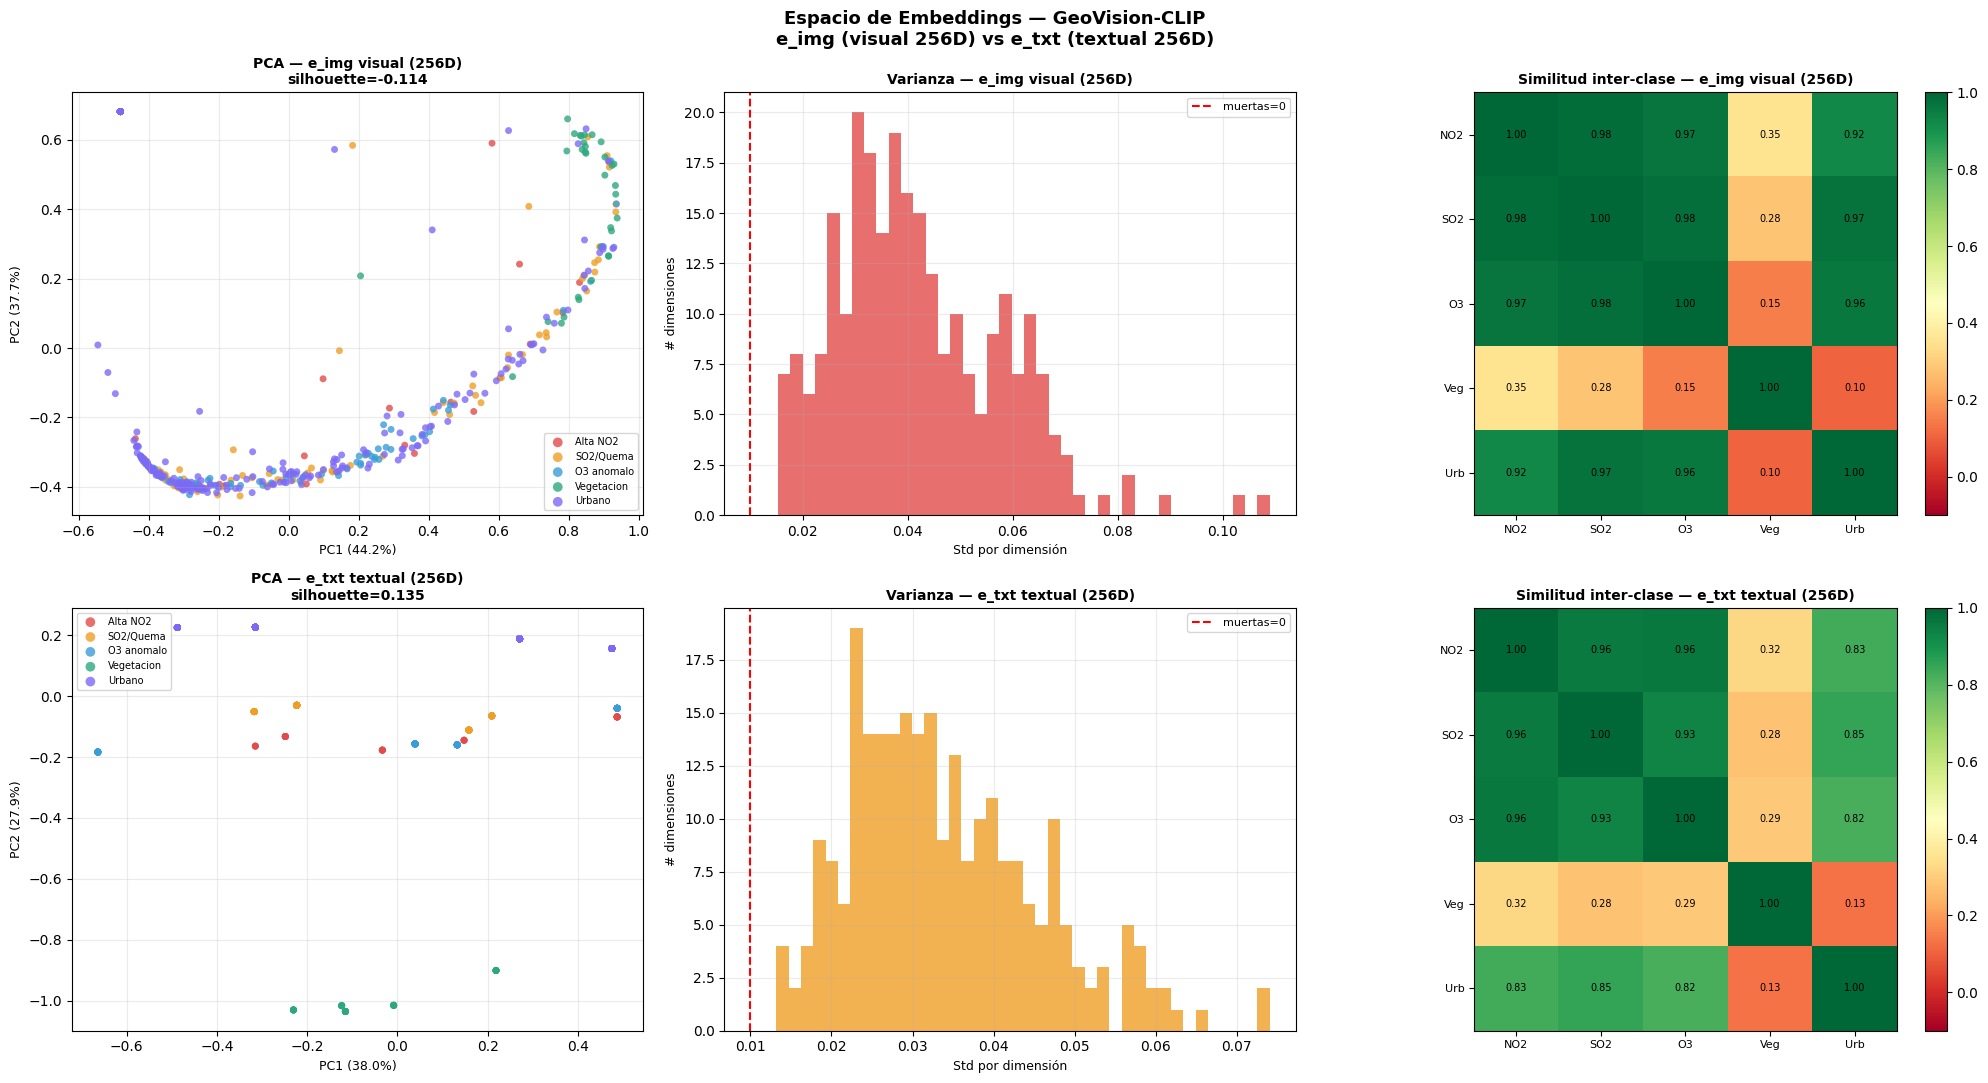

[e_img] silhouette=-0.114
[e_txt] silhouette=0.135


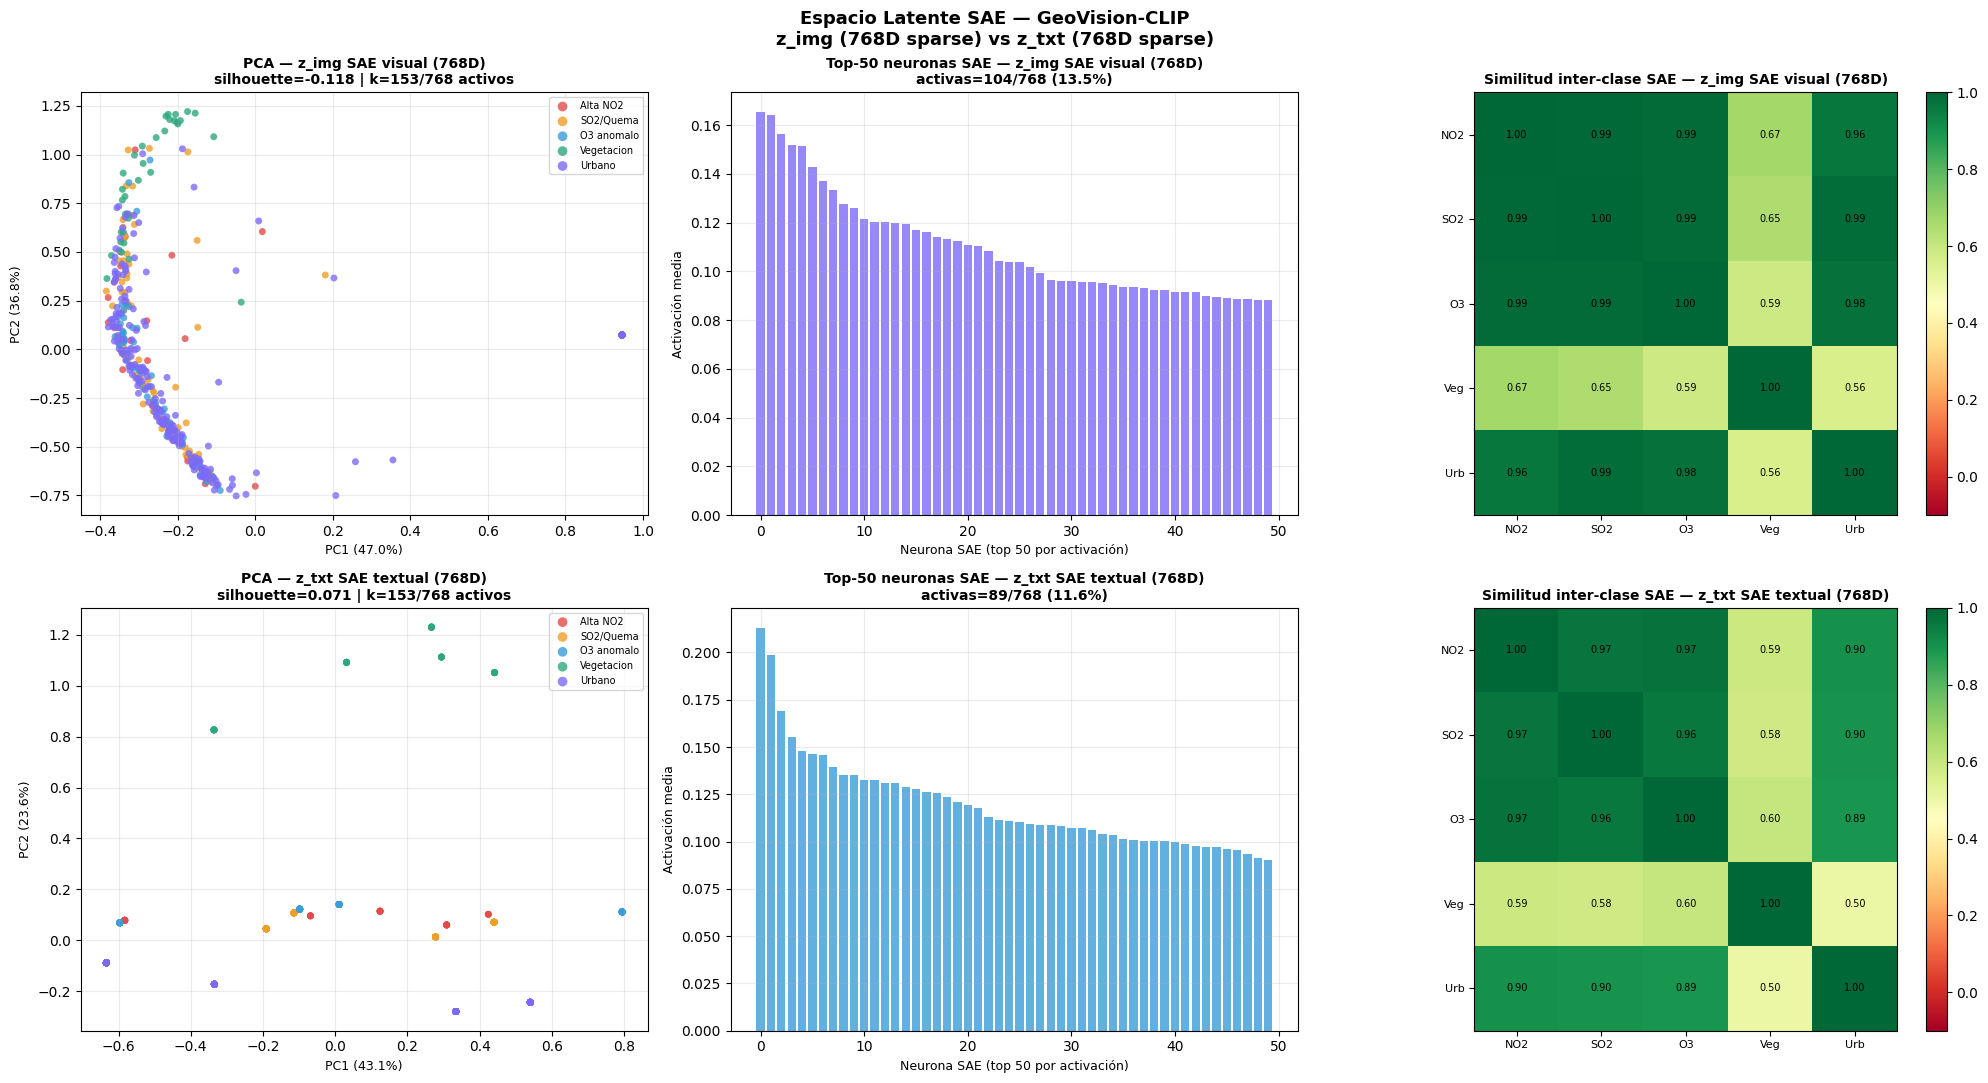

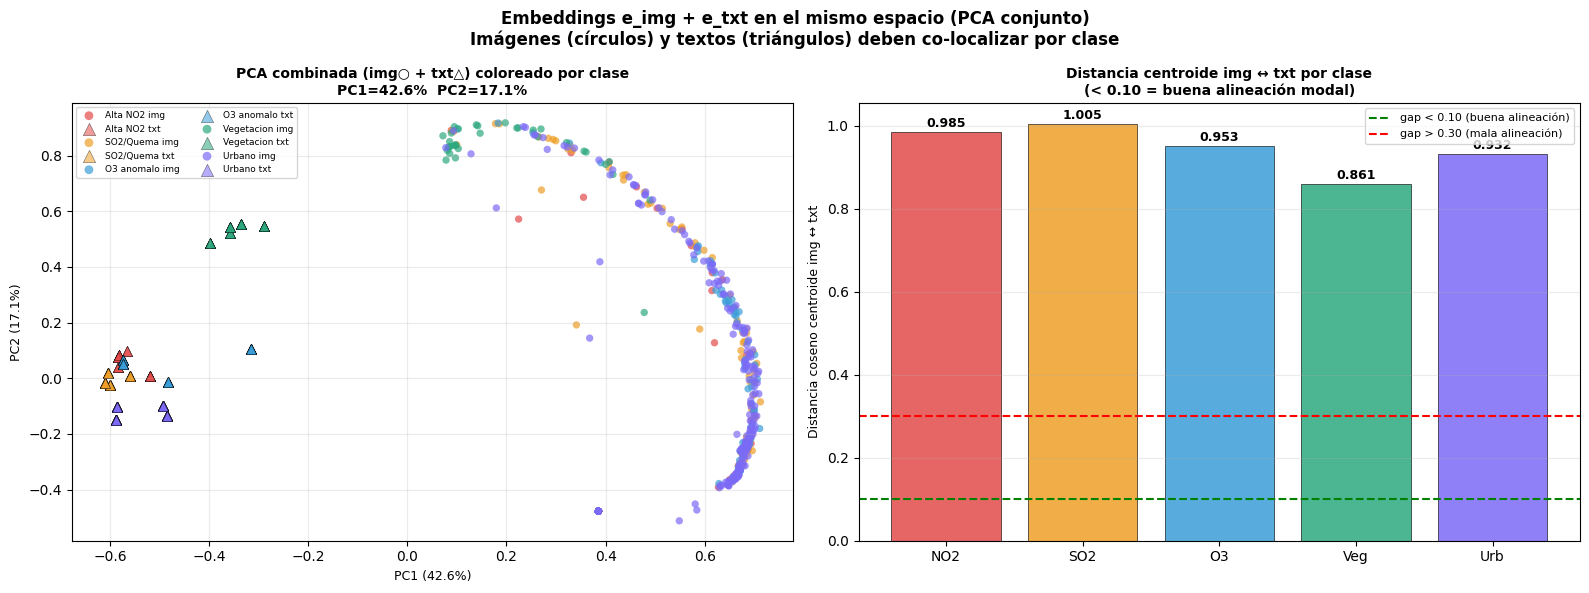


=== DIAGNÓSTICO DE SEPARABILIDAD ===
[e_img] silhouette=-0.114
[e_txt] silhouette=0.135
[z_img SAE] silhouette=-0.118
[z_txt SAE] silhouette=0.071

Distancia coseno centroide img↔txt por clase:
  Alta NO2          : 0.9846  [MALA]
  SO2/Quema         : 1.0053  [MALA]
  O3 anomalo        : 0.9527  [MALA]
  Vegetacion        : 0.8607  [MALA]
  Urbano            : 0.9321  [MALA]

VEREDICTO SEPARABILIDAD:
  e_img: CLASES SOLAPADAS (silhouette < 0.10)


In [32]:
# Análisis completo del espacio de embeddings: e_txt, z_img SAE, z_txt SAE, img+txt combinado
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

model.eval()
NOMBRES_CLASE = ['Alta NO2', 'SO2/Quema', 'O3 anomalo', 'Vegetacion', 'Urbano']
COLORES = ['#E24B4A', '#EF9F27', '#3b9dd8', '#2da87e', '#7c6af7']
FIG_DIR  = '/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2'
import os; os.makedirs(FIG_DIR, exist_ok=True)

# ── Extracción de todos los espacios de representación ──────────────────
all_e_img, all_e_txt, all_z_img, all_z_txt, all_lbl = [], [], [], [], []
with torch.no_grad():
    for tiles, vecs, texts, lbls in val_dl:
        tiles = tiles.to(DEVICE)
        vecs  = torch.nan_to_num(vecs.to(DEVICE), nan=0.0)
        out   = model(tiles, vecs, texts)

        # e_img / e_txt: espacios contrastivos (256D)
        all_e_img.append(out['e_img'].cpu().float())
        all_e_txt.append(out['e_txt'].cpu().float())

        # z_img: activaciones SAE visual (1024D sparse) — SAE opera sobre 256D post-proj
        cls_s2   = model.s2_encoder(tiles)
        cls_s5p  = model.s5p_encoder(vecs)
        fused    = model.fusion(cls_s2, cls_s5p)
        fused    = torch.nan_to_num(fused, nan=0.0)
        e_pre_img = F.normalize(model.proj_vis(fused.float()), dim=-1)  # 768→256
        _, z_img_batch, _ = model.sae(e_pre_img)
        all_z_img.append(torch.nan_to_num(z_img_batch.cpu().float(), nan=0.0))

        # z_txt: activaciones SAE textual (1024D sparse) — SAE opera sobre 256D post-proj
        raw_txt   = model.text_encoder._encode_raw(list(texts)).to(DEVICE).float()  # 768D
        e_pre_txt = F.normalize(model.text_encoder.proj_txt(raw_txt), dim=-1)       # 256D
        _, z_txt_batch, _ = model.text_encoder.sae(e_pre_txt)
        all_z_txt.append(torch.nan_to_num(z_txt_batch.cpu().float(), nan=0.0))

        all_lbl.append(lbls)

E_img  = torch.cat(all_e_img);   E_txt  = torch.cat(all_e_txt)
Z_img  = torch.cat(all_z_img);   Z_txt  = torch.cat(all_z_txt)
labels_np = torch.cat(all_lbl).numpy()

def _pca2d(X):
    pca = PCA(n_components=2)
    return pca.fit_transform(X.numpy()), pca

def _silhouette(X_2d, lbl):
    try:
        ul = np.unique(lbl)
        if len(ul) < 2 or (lbl == ul[0]).all(): return float('nan')
        return silhouette_score(X_2d, lbl)
    except: return float('nan')

# ─── FIGURA 1: Espacio textual e_txt vs espacio visual e_img ───────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Espacio de Embeddings — GeoVision-CLIP\ne_img (visual 256D) vs e_txt (textual 256D)',
             fontsize=13, fontweight='bold')

for row_i, (E, lbl_E, name) in enumerate([
        (E_img, labels_np, 'e_img visual (256D)'),
        (E_txt, labels_np, 'e_txt textual (256D)')]):

    E_2d, pca_obj = _pca2d(E)
    sil = _silhouette(E_2d, lbl_E)

    # PCA scatter
    ax = axes[row_i, 0]
    for cls in range(5):
        m = lbl_E == cls
        if m.sum() > 0:
            ax.scatter(E_2d[m,0], E_2d[m,1], c=COLORES[cls],
                       label=NOMBRES_CLASE[cls], s=25, alpha=0.80, edgecolors='none')
    ev = pca_obj.explained_variance_ratio_
    ax.set_title(f'PCA — {name}\nsilhouette={sil:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=9)
    ax.legend(fontsize=7, markerscale=1.4)
    ax.grid(True, alpha=0.25)

    # Std por dimensión
    ax2 = axes[row_i, 1]
    std_e = E.std(dim=0).numpy()
    dead  = int((std_e < 0.01).sum())
    ax2.hist(std_e, bins=40, color=COLORES[row_i], alpha=0.8)
    ax2.axvline(0.01, color='red', ls='--', lw=1.5, label=f'muertas={dead}')
    ax2.set_xlabel('Std por dimensión', fontsize=9)
    ax2.set_ylabel('# dimensiones', fontsize=9)
    ax2.set_title(f'Varianza — {name}', fontsize=10, fontweight='bold')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

    # Matriz de similitud inter-clase (centroide por clase)
    ax3 = axes[row_i, 2]
    centroids = np.array([E[labels_np==c].mean(0) for c in range(5)])
    cn = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-8)
    sim_mat = cn @ cn.T
    im = ax3.imshow(sim_mat, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
    plt.colorbar(im, ax=ax3, fraction=0.04)
    ax3.set_xticks(range(5)); ax3.set_yticks(range(5))
    names_short = ['NO2','SO2','O3','Veg','Urb']
    ax3.set_xticklabels(names_short, fontsize=8)
    ax3.set_yticklabels(names_short, fontsize=8)
    ax3.set_title(f'Similitud inter-clase — {name}', fontsize=10, fontweight='bold')
    for ii in range(5):
        for jj in range(5):
            ax3.text(jj, ii, f'{sim_mat[ii,jj]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/embeddings_contrastivos_img_txt.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'[e_img] silhouette={_silhouette(_pca2d(E_img)[0], labels_np):.3f}')
print(f'[e_txt] silhouette={_silhouette(_pca2d(E_txt)[0], labels_np):.3f}')

# ─── FIGURA 2: Espacio latente SAE z_img vs z_txt ───────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 11))
fig2.suptitle('Espacio Latente SAE — GeoVision-CLIP\nz_img (768D sparse) vs z_txt (768D sparse)',
              fontsize=13, fontweight='bold')

for row_i, (Z, name_z, col) in enumerate([
        (Z_img, 'z_img SAE visual (768D)', '#7c6af7'),
        (Z_txt, 'z_txt SAE textual (768D)', '#3b9dd8')]):

    Z_2d, pca_z = _pca2d(Z)
    sil_z = _silhouette(Z_2d, labels_np)

    # PCA scatter
    ax = axes2[row_i, 0]
    for cls in range(5):
        m = labels_np == cls
        if m.sum() > 0:
            ax.scatter(Z_2d[m,0], Z_2d[m,1], c=COLORES[cls],
                       label=NOMBRES_CLASE[cls], s=25, alpha=0.80, edgecolors='none')
    ev_z = pca_z.explained_variance_ratio_
    k_val = model.sae.k if row_i == 0 else model.text_encoder.sae.k
    ax.set_title(f'PCA — {name_z}\nsilhouette={sil_z:.3f} | k={k_val}/768 activos',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({ev_z[0]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({ev_z[1]*100:.1f}%)', fontsize=9)
    ax.legend(fontsize=7, markerscale=1.4); ax.grid(True, alpha=0.25)

    # Activación media por neurona (top-50 más activas)
    ax2 = axes2[row_i, 1]
    mean_act = Z.mean(0).numpy()
    top50 = np.argsort(mean_act)[::-1][:50]
    ax2.bar(range(50), mean_act[top50], color=col, alpha=0.8)
    dead = int((mean_act < 0.001).sum())
    active = 768 - dead
    ax2.set_xlabel('Neurona SAE (top 50 por activación)', fontsize=9)
    ax2.set_ylabel('Activación media', fontsize=9)
    ax2.set_title(f'Top-50 neuronas SAE — {name_z}\nactivas={active}/768 ({active/768*100:.1f}%)',
                  fontsize=10, fontweight='bold')
    ax2.grid(alpha=0.25)

    # Similitud inter-clase en espacio SAE
    ax3 = axes2[row_i, 2]
    cent_z = np.array([Z[labels_np==c].mean(0) for c in range(5)])
    cn_z = cent_z / (np.linalg.norm(cent_z, axis=1, keepdims=True) + 1e-8)
    sim_z = cn_z @ cn_z.T
    im2 = ax3.imshow(sim_z, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
    plt.colorbar(im2, ax=ax3, fraction=0.04)
    ax3.set_xticks(range(5)); ax3.set_yticks(range(5))
    ax3.set_xticklabels(names_short, fontsize=8)
    ax3.set_yticklabels(names_short, fontsize=8)
    ax3.set_title(f'Similitud inter-clase SAE — {name_z}', fontsize=10, fontweight='bold')
    for ii in range(5):
        for jj in range(5):
            ax3.text(jj, ii, f'{sim_z[ii,jj]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/espacio_latente_sae_z_img_txt.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── FIGURA 3: img + txt COMBINADOS en mismo espacio contrastivo ────────
# Muestra si los embeddings de imagen y texto co-localizan por clase
E_comb  = torch.cat([E_img, E_txt], dim=0).numpy()
lbl_comb = np.concatenate([labels_np, labels_np])
mod_comb = np.array(['img']*len(labels_np) + ['txt']*len(labels_np))

pca_c = PCA(n_components=2)
E_c2d = pca_c.fit_transform(E_comb)
ev_c  = pca_c.explained_variance_ratio_

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Embeddings e_img + e_txt en el mismo espacio (PCA conjunto)\n'
              'Imágenes (círculos) y textos (triángulos) deben co-localizar por clase',
              fontsize=12, fontweight='bold')

# Panel izq: coloreado por clase, marcador por modalidad
ax_c1 = axes3[0]
for cls in range(5):
    m_img = (lbl_comb == cls) & (mod_comb == 'img')
    m_txt = (lbl_comb == cls) & (mod_comb == 'txt')
    if m_img.sum() > 0:
        ax_c1.scatter(E_c2d[m_img,0], E_c2d[m_img,1], c=COLORES[cls],
                      s=28, alpha=0.70, marker='o', edgecolors='none',
                      label=f'{NOMBRES_CLASE[cls]} img')
    if m_txt.sum() > 0:
        ax_c1.scatter(E_c2d[m_txt,0], E_c2d[m_txt,1], c=COLORES[cls],
                      s=55, alpha=0.55, marker='^', edgecolors='k', linewidths=0.4,
                      label=f'{NOMBRES_CLASE[cls]} txt')
ax_c1.set_title(f'PCA combinada (img○ + txt△) coloreado por clase\n'
                f'PC1={ev_c[0]*100:.1f}%  PC2={ev_c[1]*100:.1f}%',
                fontsize=10, fontweight='bold')
ax_c1.set_xlabel(f'PC1 ({ev_c[0]*100:.1f}%)', fontsize=9)
ax_c1.set_ylabel(f'PC2 ({ev_c[1]*100:.1f}%)', fontsize=9)
ax_c1.legend(fontsize=6.5, markerscale=1.2, ncol=2); ax_c1.grid(True, alpha=0.25)

# Panel der: distancia centroide img ↔ centroide txt por clase
ax_c2 = axes3[1]
gaps = []
for cls in range(5):
    ci = E_img[labels_np == cls].mean(0) if (labels_np == cls).any() else None
    ct = E_txt[labels_np == cls].mean(0) if (labels_np == cls).any() else None
    if ci is not None and ct is not None:
        ci_n = ci / (ci.norm() + 1e-8)
        ct_n = ct / (ct.norm() + 1e-8)
        cos_sim = (ci_n * ct_n).sum().item()
        cos_dist = 1 - cos_sim
        gaps.append(cos_dist)
    else:
        gaps.append(float('nan'))

bars = ax_c2.bar(range(5), gaps, color=COLORES, alpha=0.85, edgecolor='k', linewidth=0.5)
ax_c2.axhline(0.1, color='green', ls='--', lw=1.5, label='gap < 0.10 (buena alineación)')
ax_c2.axhline(0.3, color='red',   ls='--', lw=1.5, label='gap > 0.30 (mala alineación)')
ax_c2.set_xticks(range(5))
ax_c2.set_xticklabels(names_short, fontsize=10)
ax_c2.set_ylabel('Distancia coseno centroide img ↔ txt', fontsize=9)
ax_c2.set_title('Distancia centroide img ↔ txt por clase\n(< 0.10 = buena alineación modal)',
                fontsize=10, fontweight='bold')
ax_c2.legend(fontsize=8); ax_c2.grid(axis='y', alpha=0.25)
for i, (g, b) in enumerate(zip(gaps, bars)):
    if not np.isnan(g):
        ax_c2.text(b.get_x() + b.get_width()/2, g + 0.005, f'{g:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/embeddings_combinados_img_txt.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Diagnóstico final ───────────────────────────────────────────────────
print('\n=== DIAGNÓSTICO DE SEPARABILIDAD ===')
print(f'[e_img] silhouette={_silhouette(_pca2d(E_img)[0], labels_np):.3f}')
print(f'[e_txt] silhouette={_silhouette(_pca2d(E_txt)[0], labels_np):.3f}')
print(f'[z_img SAE] silhouette={_silhouette(_pca2d(Z_img)[0], labels_np):.3f}')
print(f'[z_txt SAE] silhouette={_silhouette(_pca2d(Z_txt)[0], labels_np):.3f}')
print()
print('Distancia coseno centroide img↔txt por clase:')
for cls, g in enumerate(gaps):
    est = 'BUENA' if g < 0.10 else ('MEDIA' if g < 0.30 else 'MALA')
    print(f'  {NOMBRES_CLASE[cls]:<18}: {g:.4f}  [{est}]')
print()
sil_img = _silhouette(_pca2d(E_img)[0], labels_np)
print('VEREDICTO SEPARABILIDAD:')
if sil_img > 0.30:   print('  e_img: BIEN SEPARADO por clase (silhouette > 0.30)')
elif sil_img > 0.10: print('  e_img: SEPARACION PARCIAL (silhouette 0.10-0.30)')
else:                print('  e_img: CLASES SOLAPADAS (silhouette < 0.10)')


In [34]:
## KPIs Oficiales — Evaluación Post-Entrenamiento

# ── Mapeo clase_idx → nombre corto (uso programático) ────────────────────
CLASE_NOMBRES = [
    'NO2_industrial',   # 0
    'SO2_quema_cana',   # 1
    'O3_anomalo',       # 2
    'vegetacion_densa', # 3
    'urbano_moderado',  # 4
]


def calcular_recall_semantico(
    e_img: torch.Tensor, e_txt: torch.Tensor, clases: list, k: int = 1
) -> float:
    """
    Recall Semántico @K: un acierto ocurre cuando el texto recuperado
    en las primeras K posiciones pertenece a la MISMA CLASE que la consulta.
    Diferente del Recall exacto (que exige el par índice-a-índice).

    Args:
        e_img  : (N, D) embeddings visuales L2-normalizados
        e_txt  : (N, D) embeddings textuales L2-normalizados
        clases : lista de N strings con el nombre de clase de cada muestra
        k      : número de candidatos recuperados a considerar
    """
    sim    = e_img @ e_txt.T              # (N, N)
    top_k  = sim.topk(k, dim=1).indices  # (N, k)
    hits   = 0
    for i in range(len(e_img)):
        clases_top = [clases[j] for j in top_k[i].tolist()]
        if clases[i] in clases_top:
            hits += 1
    return hits / len(e_img)

def evaluar_modelo_test(model, test_loader, device=None):
    """
    KPIs oficiales Situación 2 sobre el conjunto TEST.
    Recall@1 y @5 semánticos, Sparsity SAE visual y MSE reconstrucción.
    Adaptado para GeoVision-CLIP v17: batch = (tiles, vecs, texts, labels).
    """
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    all_e_img, all_e_txt, all_clases = [], [], []
    sp_img_sum = sp_txt_sum = 0.0
    mse_vis_list = []
    n_batches = 0

    with torch.no_grad():
        for tiles, vecs, texts, labels in test_loader:
            tiles  = tiles.to(device)
            vecs   = torch.nan_to_num(vecs.to(device), nan=0.0)

            out = model(tiles, vecs, list(texts))
            all_e_img.append(out['e_img'].cpu())
            all_e_txt.append(out['e_txt'].cpu())
            all_clases.extend([CLASE_NOMBRES[l.item()] for l in labels])

            sp_img_sum += float(out['sparsity_img'])
            sp_txt_sum += float(out['sparsity_txt'])
            n_batches  += 1

            # MSE SAE visual (Camino B — solo fase 2)
            if model._phase == 2:
                cls_s2  = model.s2_encoder(tiles)
                cls_s5p = model.s5p_encoder(vecs)
                fused   = torch.nan_to_num(model.fusion(cls_s2, cls_s5p), nan=0.0)
                e_pre   = F.normalize(model.proj_vis(fused).float(), dim=-1)
                x_hat, _, _ = model.sae(e_pre)
                x_hat = torch.nan_to_num(x_hat.float(), nan=0.0)
                mse_v = F.mse_loss(x_hat, e_pre).item()
                if np.isfinite(mse_v):
                    mse_vis_list.append(mse_v)

    e_img_all = torch.cat(all_e_img)
    e_txt_all = torch.cat(all_e_txt)

    r1 = calcular_recall_semantico(e_img_all, e_txt_all, all_clases, k=1)
    r5 = calcular_recall_semantico(e_img_all, e_txt_all, all_clases, k=5)

    avg_sp_img  = sp_img_sum / n_batches if n_batches > 0 else 0.0
    avg_sp_txt  = sp_txt_sum / n_batches if n_batches > 0 else 0.0
    avg_mse_vis = float(np.mean(mse_vis_list)) if mse_vis_list else float('nan')

    def estado(val, thr, mayor=True):
        ok = (val >= thr) if mayor else (val <= thr)
        return '✅ CUMPLIDO' if ok else '❌ REPROBADO'

    print('\n' + '='*65)
    print('  REPORTE KPIs OFICIALES — CONJUNTO TEST  (Situación 2)')
    print('='*65)
    print(f"{'KPI':<30} {'Valor':>8}  {'Meta':>8}  Estado")
    print('-'*65)
    print(f"{'Recall@1  img→txt':<30} {r1:>8.4f}  {'≥0.45':>8}  {estado(r1, 0.45)}")
    print(f"{'Recall@5  img→txt':<30} {r5:>8.4f}  {'≥0.70':>8}  {estado(r5, 0.70)}")
    print(f"{'Sparsity SAE visual':<30} {avg_sp_img*100:>7.1f}%  {'≥70%':>8}  {estado(avg_sp_img, 0.70)}")
    print(f"{'Sparsity SAE texto':<30} {avg_sp_txt*100:>7.1f}%  {'  —':>8}  (informativo)")
    if not np.isnan(avg_mse_vis):
        print(f"{'MSE reconstrucción visual':<30} {avg_mse_vis:>8.5f}  {'≤0.05':>8}  {estado(avg_mse_vis, 0.05, mayor=False)}")
    print('='*65)

    return {
        'r1': r1, 'r5': r5,
        'sp_vis': avg_sp_img, 'sp_txt': avg_sp_txt,
        'mse_vis': avg_mse_vis,
    }


# ── Ejecución ─────────────────────────────────────────────────────────────
# Asegurarse de estar en fase 2 (SAE activo) antes de evaluar:
model._phase = 2
reporte_kpi = evaluar_modelo_test(model, test_dl, device=DEVICE)

import pandas as pd
from collections import defaultdict


def evaluar_por_clase(model, test_loader, device=None):
    """
    Reporte de Recall@1 y @5 por clase (retrieval semántico img→txt).
    Muestra mejor y peor clase e identifica la clase más confundida.
    Adaptado para GeoVision-CLIP v17: batch = (tiles, vecs, texts, labels).
    """
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    all_img_emb, all_txt_emb, clases_test = [], [], []

    print('Extrayendo embeddings TEST...')
    with torch.no_grad():
        for tiles, vecs, texts, labels in test_loader:
            tiles = tiles.to(device)
            vecs  = torch.nan_to_num(vecs.to(device), nan=0.0)
            out   = model(tiles, vecs, list(texts))
            all_img_emb.append(F.normalize(out['e_img'], dim=-1).cpu())
            all_txt_emb.append(F.normalize(out['e_txt'], dim=-1).cpu())
            clases_test.extend([CLASE_NOMBRES[l.item()] for l in labels])

    all_img_emb = torch.cat(all_img_emb)   # (N, 256)
    all_txt_emb = torch.cat(all_txt_emb)   # (N, 256)
    clases_arr  = np.array(clases_test)
    sim_matrix  = all_img_emb @ all_txt_emb.T  # (N, N)

    res = defaultdict(lambda: {'total': 0, 'r1': 0, 'r5': 0, 'errores': []})

    for i in range(len(clases_arr)):
        clase_real  = clases_arr[i]
        ranking     = torch.argsort(sim_matrix[i], descending=True)
        top1_clase  = clases_arr[ranking[0].item()]
        top5_clases = clases_arr[ranking[:5].tolist()]

        res[clase_real]['total'] += 1
        if clase_real == top1_clase:
            res[clase_real]['r1'] += 1
        else:
            res[clase_real]['errores'].append(top1_clase)
        if clase_real in top5_clases:
            res[clase_real]['r5'] += 1

    filas = []
    for clase, d in res.items():
        conf = pd.Series(d['errores']).value_counts().idxmax() if d['errores'] else '—'
        filas.append({
            'Clase':                clase,
            'Samples':              d['total'],
            'Recall@1':             round(d['r1'] / d['total'], 4),
            'Recall@5':             round(d['r5'] / d['total'], 4),
            'Correctos@1':          d['r1'],
            'Correctos@5':          d['r5'],
            'Clase_mas_confundida': conf,
        })

    df_res = (pd.DataFrame(filas)
                .sort_values('Recall@1')
                .reset_index(drop=True))

    print('\n' + '='*70)
    print('REPORTE POR CLASE — Recall semántico img→txt')
    print('='*70)
    print(df_res.to_string(index=False))
    print('\n' + '-'*70)
    mejor = df_res.iloc[-1]
    peor  = df_res.iloc[0]
    print(f"✅ Mejor clase : {mejor['Clase']}  R@1={mejor['Recall@1']}")
    print(f"⚠️  Peor clase  : {peor['Clase']}  R@1={peor['Recall@1']}  "
          f"(se confunde con: {peor['Clase_mas_confundida']})")
    return df_res


# ── Ejecución ─────────────────────────────────────────────────────────────
df_por_clase = evaluar_por_clase(model, test_dl, device=DEVICE)

def extraer_representaciones_geovision(
    model,
    dataloader,
    device=None,
    out_path='representaciones_geovision.npz',
):
    """
    Extrae y guarda embeddings completos para AFE/AFC (Situación 2).

    Salidas en el .npz:
      e_img  (n, 256)  — embeddings visuales contrastivos (L2-norm)
      e_txt  (n, 256)  — embeddings textuales contrastivos (L2-norm)
      z_img  (n, 1024) — activaciones SAE visuales (fase 2; ceros en fase 1)
      z_txt  (n, 1024) — activaciones SAE textuales (fase 2; ceros en fase 1)
      labels (n,)      — índices de clase 0–4
      clases (n,)      — nombres de clase (strings)
      gases  (n, 8)    — vectores S5P normalizados
      fechas (n,)      — fechas_s2 (desde dataloader.dataset.df)

    Nota: ejecutar con shuffle=False (val_dl y test_dl cumplen esto).
    Para train_dl usar un DataLoader temporal con shuffle=False.
    """
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    e_img_l, e_txt_l, z_img_l, z_txt_l = [], [], [], []
    labels_l, gases_l = [], []

    sae_dim = model.sae.latent_dim if hasattr(model, 'sae') else 1024
    dev_txt = next(model.text_encoder.proj_txt.parameters()).device

    print(f'Extrayendo representaciones ({len(dataloader)} batches, fase={model._phase}) ...')

    with torch.no_grad():
        for tiles, vecs, texts, labels in dataloader:
            tiles   = tiles.to(device)
            vecs_c  = torch.nan_to_num(vecs.to(device), nan=0.0)
            B       = tiles.shape[0]

            out = model(tiles, vecs_c, list(texts))
            e_img_l.append(out['e_img'].cpu().float().numpy())
            e_txt_l.append(out['e_txt'].cpu().float().numpy())
            labels_l.append(labels.numpy())
            gases_l.append(vecs.numpy())

            if model._phase == 2:
                # z_img — activaciones SAE visual (Camino B)
                cls_s2  = model.s2_encoder(tiles)
                cls_s5p = model.s5p_encoder(vecs_c)
                fused   = torch.nan_to_num(model.fusion(cls_s2, cls_s5p), nan=0.0)
                e_pre   = F.normalize(model.proj_vis(fused).float(), dim=-1)
                _, z_v, _ = model.sae(e_pre)
                z_img_l.append(torch.nan_to_num(z_v, nan=0.0).cpu().float().numpy())

                # z_txt — activaciones SAE textual (Camino B)
                raw_txt = model.text_encoder._encode_raw(list(texts)).to(dev_txt).float()  # 768D
                e_pre_t = F.normalize(
                    model.text_encoder.proj_txt(raw_txt).float(), dim=-1
                )
                _, z_t, _ = model.text_encoder.sae(e_pre_t)
                z_txt_l.append(torch.nan_to_num(z_t, nan=0.0).cpu().float().numpy())
            else:
                z_img_l.append(np.zeros((B, sae_dim), dtype=np.float32))
                z_txt_l.append(np.zeros((B, sae_dim), dtype=np.float32))

    e_img_arr  = np.concatenate(e_img_l,  axis=0)
    e_txt_arr  = np.concatenate(e_txt_l,  axis=0)
    z_img_arr  = np.concatenate(z_img_l,  axis=0)
    z_txt_arr  = np.concatenate(z_txt_l,  axis=0)
    labels_arr = np.concatenate(labels_l, axis=0)
    gases_arr  = np.concatenate(gases_l,  axis=0)
    clases_arr = np.array([CLASE_NOMBRES[l] for l in labels_arr])

    # Fechas desde el df interno del Dataset (sincronizadas con el DataLoader)
    try:
        df_ds   = dataloader.dataset.df
        fechas  = df_ds['fecha_s2'].astype(str).values
        n_used  = len(labels_arr)
        if len(fechas) >= n_used:
            fechas_arr = fechas[:n_used]
        else:
            fechas_arr = np.array([''] * n_used)
    except AttributeError:
        fechas_arr = np.array([''] * len(labels_arr))

    np.savez_compressed(
        out_path,
        e_img=e_img_arr, e_txt=e_txt_arr,
        z_img=z_img_arr, z_txt=z_txt_arr,
        labels=labels_arr, clases=clases_arr,
        gases=gases_arr,   fechas=fechas_arr,
    )

    print(f'\nRepresentaciones guardadas en: {out_path}')
    print(f'  e_img {e_img_arr.shape}  e_txt {e_txt_arr.shape}')
    print(f'  z_img {z_img_arr.shape}  z_txt {z_txt_arr.shape}')
    print(f'  labels {labels_arr.shape}  gases {gases_arr.shape}')

    return {
        'e_img':   e_img_arr,  'e_txt':   e_txt_arr,
        'z_img':   z_img_arr,  'z_txt':   z_txt_arr,
        'labels':  labels_arr, 'clases':  clases_arr,
        'gases':   gases_arr,  'fechas':  fechas_arr,
    }


# ── Ejecución ─────────────────────────────────────────────────────────────
model._phase = 2   # asegurarse de que el SAE está activo

# train_dl usa shuffle=True — crear versión sin shuffle para extracción
train_dl_noshuffle = DataLoader(
    train_dl.dataset,
    batch_size=train_dl.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=train_dl.num_workers,
    pin_memory=train_dl.pin_memory,
)

reps_test = extraer_representaciones_geovision(
    model=model, dataloader=test_dl, device=DEVICE,
    out_path='/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/representaciones_geovision_test.npz',
)
reps_train = extraer_representaciones_geovision(
    model=model, dataloader=train_dl_noshuffle, device=DEVICE,
    out_path='/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/representaciones_geovision_train.npz',
)



  REPORTE KPIs OFICIALES — CONJUNTO TEST  (Situación 2)
KPI                               Valor      Meta  Estado
-----------------------------------------------------------------
Recall@1  img→txt                0.4622     ≥0.45  ✅ CUMPLIDO
Recall@5  img→txt                0.4622     ≥0.70  ❌ REPROBADO
Sparsity SAE visual               85.1%      ≥70%  ✅ CUMPLIDO
Sparsity SAE texto                85.1%         —  (informativo)
MSE reconstrucción visual       0.00540     ≤0.05  ✅ CUMPLIDO
Extrayendo embeddings TEST...

REPORTE POR CLASE — Recall semántico img→txt
           Clase  Samples  Recall@1  Recall@5  Correctos@1  Correctos@5 Clase_mas_confundida
  NO2_industrial       27    0.0000    0.0000            0            0      urbano_moderado
  SO2_quema_cana       96    0.0000    0.0000            0            0      urbano_moderado
      O3_anomalo       80    0.4875    0.5000           39           40      urbano_moderado
 urbano_moderado      272    0.6324    0.6324          17